# 🩺📊 Aplicações da aula de 1 a 8 (versão 2): saúde no Brasil, com dados reais do IBGE

Mesma ideia do outro notebook de aplicações — percorrer, num só banco de dados, **todos os conteúdos das Aulas 1 a 8** — mas com um banco de dados bem diferente, para não repetir o mesmo tipo de análise duas vezes.

Aqui os dados são da **PNS 2019** (Pesquisa Nacional de Saúde), uma pesquisa domiciliar real feita pelo IBGE em parceria com o Ministério da Saúde, com entrevistas em mais de 90 mil pessoas no Brasil inteiro. Baixamos os microdados oficiais direto do site do IBGE (ftp.ibge.gov.br) e selecionamos uma amostra de **2.000 pessoas reais** que responderam ao questionário individual completo (incluindo peso e altura medidos de verdade, com balança e fita métrica — não é autodeclarado).

Isso muda o "tipo" de dado bagunçado que vamos encontrar: no notebook anterior (filmes) o problema era formatação (texto em vez de número, valor faltante). Aqui, o problema é outro: **dado de pesquisa oficial vem codificado** — cada resposta é um número/código que só faz sentido junto com o dicionário de variáveis do IBGE. Isso é exatamente como cientistas de dados trabalham com dados públicos de verdade.

Só executar e ler, na ordem, sem entrega.

## 0. Carregando os dados reais (ainda codificados, do jeito que o IBGE distribui)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io

DADOS_CSV = '''uf_cod,sexo_cod,idade,cor_raca_cod,estado_civil_cod,autoavaliacao_saude_cod,atividade_fisica_cod,fumante_cod,hipertensao_cod,diabetes_cod,instrucao_cod,faixa_renda_cod,renda_percapita,peso_kg,altura_cm
11,1,21,2,4,2,1,3,2,2,2,6,3149.0,66.7,168.3
11,1,45,4,1,2,1,3,2,2,5,3,750.0,83.2,167.5
11,1,17,4,4,3,1,3,2,2,4,2,450.0,58.0,181.0
11,1,25,1,4,1,2,1,2,2,4,4,1600.0,68.5,181.5
11,1,37,4,1,2,1,3,2,2,5,2,380.0,73.4,178.0
11,2,20,4,4,2,1,3,2,2,6,1,150.0,59.1,156.2
11,1,44,4,1,2,1,3,2,2,2,4,1250.0,66.0,163.1
11,1,50,3,1,3,2,3,2,2,1,3,649.0,69.0,173.4
11,1,29,4,4,2,1,3,2,2,3,4,1250.0,100.8,186.0
11,1,63,3,1,2,2,3,2,2,5,6,3299.0,63.8,167.5
11,2,31,4,4,1,2,3,2,2,1,1,50.0,72.9,145.8
11,1,53,4,4,4,1,3,2,2,2,3,998.0,64.3,163.0
11,2,17,4,4,2,2,3,2,2,4,2,499.0,90.2,162.5
11,2,41,1,4,1,2,1,2,2,5,4,1000.0,47.3,159.8
11,1,54,1,1,5,2,3,2,2,2,4,1850.0,73.2,164.6
11,1,34,1,1,2,1,3,2,2,5,4,1100.0,83.0,177.0
11,1,40,2,4,2,2,3,2,2,2,4,1500.0,82.6,172.3
11,2,63,2,1,2,1,3,1,2,7,4,1833.0,47.4,150.0
11,1,54,4,1,3,2,3,2,2,2,4,1125.0,103.0,173.5
11,1,62,1,4,2,2,3,2,2,4,3,750.0,64.0,167.5
11,1,25,4,4,2,2,3,2,,5,5,2500.0,84.0,172.5
11,2,22,1,4,2,1,3,2,2,6,3,666.0,54.0,164.1
11,1,44,1,4,1,2,3,2,,2,4,1000.0,56.0,158.5
11,1,26,4,1,3,2,3,,,2,2,250.0,79.7,178.7
11,2,31,4,4,3,2,3,2,2,4,2,256.0,56.9,151.2
11,2,23,4,1,2,1,3,2,2,5,3,600.0,111.0,175.0
11,2,51,4,1,4,2,3,1,1,7,4,1167.0,71.7,161.9
11,2,31,4,4,2,2,3,2,2,4,3,900.0,58.2,152.2
11,2,51,4,3,2,1,3,2,2,2,3,998.0,70.4,160.8
11,2,39,4,4,3,1,1,1,2,2,3,998.0,71.0,153.0
11,1,72,1,2,2,2,2,2,2,2,4,1248.0,88.1,166.0
11,2,30,4,1,2,1,3,2,2,7,3,933.0,58.5,157.7
11,2,76,4,2,3,2,1,2,2,3,4,1248.0,75.8,154.2
11,2,58,4,4,4,2,3,2,1,2,1,35.0,71.1,157.0
11,2,55,4,1,3,2,3,2,2,1,3,665.0,78.0,159.0
11,1,73,4,1,3,1,1,1,1,2,3,998.0,75.0,173.0
11,1,35,4,1,2,2,3,2,2,5,3,540.0,72.0,173.0
11,2,49,4,1,2,2,3,1,2,2,6,3000.0,93.4,164.0
11,2,32,4,1,3,1,3,2,2,4,3,800.0,69.8,161.3
11,2,40,4,1,3,1,3,2,2,3,4,1167.0,66.8,159.5
11,1,67,4,1,3,2,3,1,2,1,6,2998.0,91.7,161.3
11,1,55,2,1,5,2,3,1,2,2,3,665.0,96.6,188.0
12,2,24,1,4,2,1,3,2,2,7,4,1125.0,55.0,165.0
12,2,38,4,1,2,1,3,2,2,5,5,2750.0,82.0,158.0
12,1,66,4,3,4,2,3,1,2,2,3,988.0,58.0,153.0
12,2,58,4,4,3,1,3,1,1,1,5,2248.0,60.0,158.5
12,1,68,4,1,3,2,3,1,1,2,4,1048.0,67.0,149.0
12,1,55,4,1,3,2,3,1,2,4,6,4850.0,72.0,165.0
12,1,23,4,4,2,2,1,2,,1,2,314.0,74.0,182.0
12,1,34,4,4,3,2,3,1,1,2,2,388.0,57.8,165.0
12,2,36,1,4,3,1,3,1,2,7,2,400.0,69.5,146.0
12,2,30,4,1,2,2,3,2,2,5,3,625.0,55.0,160.0
12,1,57,2,1,3,2,3,1,2,1,3,500.0,59.6,165.0
12,1,55,4,4,2,2,1,2,,2,5,2000.0,70.0,165.0
12,1,26,4,4,2,1,2,2,2,2,1,147.0,64.0,173.0
13,1,62,4,4,2,2,3,2,2,5,4,999.0,68.0,166.0
13,2,51,4,4,2,2,3,2,2,4,3,700.0,79.0,156.5
13,1,34,4,1,3,1,3,2,2,7,3,667.0,101.9,165.0
13,2,27,1,4,2,2,3,1,2,4,3,792.0,69.0,167.0
13,1,53,4,3,3,2,3,2,2,2,3,563.0,77.8,164.5
13,2,23,4,4,2,1,3,2,2,7,2,499.0,72.0,180.0
13,1,87,4,1,2,2,3,1,2,2,2,483.0,64.0,154.0
13,1,37,1,4,2,2,3,2,2,6,4,1020.0,81.0,165.0
13,2,51,4,4,3,1,3,1,2,7,4,1000.0,59.0,152.5
13,2,34,1,1,2,2,3,2,2,2,1,211.0,89.0,158.0
13,1,39,1,4,3,2,3,2,2,2,3,900.0,76.0,166.0
13,2,58,4,4,3,2,3,2,2,2,2,300.0,60.1,150.0
13,2,30,1,4,1,2,3,2,2,5,3,998.0,65.0,160.0
13,2,36,1,4,2,2,3,2,2,6,4,1166.0,56.0,156.0
13,2,59,4,1,2,2,3,2,,1,4,1000.0,63.0,160.0
13,1,53,4,4,2,2,3,2,2,7,2,490.0,94.0,167.5
13,1,27,1,1,1,2,3,2,2,5,4,1133.0,84.0,170.0
13,2,22,1,4,3,2,3,2,2,5,7,5100.0,51.0,165.0
13,2,74,1,3,3,2,3,2,1,2,3,998.0,60.0,158.0
13,1,16,4,4,2,1,3,2,2,4,5,2000.0,64.8,173.0
13,2,36,4,4,2,2,3,2,2,3,3,998.0,63.1,168.0
13,2,26,4,4,2,2,3,2,2,6,2,435.0,63.0,156.0
13,2,83,1,3,3,2,3,1,2,2,4,1148.0,64.4,146.5
13,1,41,4,4,1,1,2,2,2,5,7,9000.0,103.2,178.0
13,1,42,4,1,2,1,3,2,2,2,1,107.0,71.9,161.0
13,2,47,4,4,4,2,1,2,2,2,1,145.0,75.3,169.0
13,1,44,1,4,2,2,3,2,2,2,1,150.0,62.0,162.0
13,2,26,4,4,2,1,3,2,2,7,3,750.0,65.0,155.0
13,1,54,4,1,3,2,3,2,2,2,3,665.0,78.0,164.0
13,1,59,1,1,2,1,3,2,2,2,2,368.0,83.0,160.0
13,2,74,4,3,2,2,3,1,2,5,3,933.0,67.0,146.0
13,1,74,1,3,2,2,3,1,2,2,5,1998.0,69.0,160.0
13,1,20,4,4,2,1,3,2,2,4,1,136.0,52.0,168.0
13,1,23,4,4,2,2,1,2,,3,3,500.0,72.0,162.0
13,1,20,1,4,3,2,3,2,,4,2,499.0,68.0,165.0
13,2,64,4,4,4,2,3,1,2,1,3,665.0,50.0,155.5
13,2,47,4,4,3,2,1,1,2,3,2,323.0,81.0,162.0
13,1,78,4,4,3,2,1,2,2,1,3,998.0,53.4,171.2
13,1,64,1,1,3,2,3,1,2,1,3,998.0,89.1,162.7
13,1,65,1,4,4,2,3,1,2,1,3,765.0,49.0,169.0
13,1,27,4,4,2,1,1,1,,4,3,630.0,60.0,164.0
13,1,104,4,4,4,2,3,1,,1,2,499.0,55.4,160.0
13,1,51,4,4,4,2,3,2,,1,1,75.0,70.0,162.0
13,1,65,4,3,2,1,3,2,2,3,3,998.0,66.0,166.0
13,2,44,4,4,2,2,3,2,2,4,1,225.0,54.0,165.0
13,1,37,4,1,2,2,3,2,,5,1,128.0,54.0,161.5
13,2,49,1,1,4,2,3,1,2,7,2,466.0,122.7,163.0
13,1,32,4,4,2,2,3,2,2,2,2,436.0,79.0,177.0
13,2,25,4,4,2,2,3,2,2,4,1,104.0,66.5,159.0
14,2,55,4,3,3,1,3,2,2,2,6,3000.0,49.6,143.0
14,2,39,4,4,2,1,3,2,2,7,4,1267.0,52.4,154.0
14,1,34,2,4,3,2,3,2,2,5,1,200.0,89.9,164.0
14,1,39,4,4,2,2,3,,2,2,3,513.0,71.4,160.0
14,1,28,2,4,1,1,3,2,2,7,5,2300.0,62.5,177.0
14,1,18,1,4,1,1,3,2,2,5,6,3500.0,82.3,185.0
14,2,65,5,4,3,1,3,1,2,5,4,999.0,65.3,152.0
14,1,76,2,1,4,2,1,2,2,1,3,749.0,59.0,160.0
14,1,60,4,4,2,2,3,2,,2,4,1000.0,72.5,159.0
14,2,68,4,4,2,1,2,1,2,7,4,1740.0,88.1,163.0
14,1,15,5,4,2,1,3,2,2,2,3,532.0,75.6,182.0
14,1,56,4,4,2,2,3,1,1,1,1,250.0,79.2,169.0
14,1,67,4,1,3,2,3,1,2,2,7,9798.0,68.0,171.5
14,2,46,4,1,2,2,3,2,2,5,4,1065.0,52.0,153.0
15,2,53,4,1,1,1,3,1,2,7,6,2996.0,69.0,165.5
15,2,35,4,4,2,2,3,2,2,5,1,177.0,81.9,168.0
15,2,66,1,4,2,2,3,2,2,6,5,2980.0,57.6,154.0
15,1,72,1,1,3,2,3,2,2,4,6,3150.0,60.0,164.0
15,2,42,4,4,1,2,3,2,2,4,2,350.0,68.0,151.0
15,2,30,4,4,2,1,3,2,2,5,3,665.0,55.0,156.0
15,1,33,4,4,2,1,3,2,2,4,3,500.0,74.2,174.5
15,1,32,4,1,2,2,3,2,2,5,3,625.0,96.5,168.0
15,2,75,1,4,2,2,3,1,2,2,3,599.0,70.0,143.0
15,2,19,1,4,3,1,3,2,2,5,2,440.0,70.0,165.0
15,1,68,1,2,4,2,3,1,2,5,3,998.0,83.0,173.0
15,2,36,4,4,2,1,3,2,2,4,3,522.0,64.0,160.0
15,1,19,2,4,2,1,3,2,2,3,3,634.0,60.5,169.0
15,1,59,4,4,2,1,1,2,2,2,3,500.0,72.7,164.0
15,2,35,4,4,3,2,3,2,2,4,3,700.0,65.0,163.0
15,1,16,1,4,2,1,3,,,3,3,700.0,61.0,178.7
15,2,35,4,4,4,2,3,2,2,3,3,600.0,68.2,157.5
15,1,50,2,4,3,2,3,2,2,2,1,130.0,75.5,170.2
15,1,57,4,1,2,2,3,2,2,2,3,500.0,74.1,168.0
15,2,38,4,4,3,2,3,2,2,5,3,682.0,57.1,164.2
15,1,39,4,1,3,2,3,2,2,2,2,325.0,83.0,166.0
15,1,49,4,1,3,2,3,1,2,2,3,566.0,72.4,161.0
15,2,29,4,4,3,1,1,2,2,2,1,166.0,104.5,155.0
15,1,20,1,4,2,1,3,2,2,5,3,517.0,61.2,172.0
15,2,32,2,4,2,2,3,2,2,6,3,772.0,94.4,166.0
15,2,32,2,4,2,1,3,2,2,7,3,500.0,85.0,167.0
15,2,39,4,4,2,2,3,2,2,7,3,667.0,78.0,164.0
15,2,60,4,4,5,2,1,1,2,2,2,346.0,61.0,162.5
15,2,66,4,3,2,2,3,,2,5,4,1402.0,54.4,162.3
15,2,28,4,4,2,1,3,,,6,3,600.0,71.0,163.5
15,2,61,4,4,3,2,3,2,2,1,3,749.0,62.0,157.0
15,1,16,2,4,2,2,3,2,2,2,1,111.0,51.0,164.0
15,2,30,4,4,3,2,3,2,2,5,3,515.0,70.0,153.0
15,2,23,4,4,2,2,3,2,,2,1,152.0,52.1,158.7
15,1,55,2,4,3,2,3,,,1,2,322.0,44.8,146.5
15,1,27,4,4,2,2,1,2,,2,1,202.0,67.3,170.5
15,2,19,4,4,2,2,3,2,,3,1,95.0,65.0,149.0
15,1,34,4,2,2,2,3,2,2,5,2,250.0,84.3,168.0
15,1,48,4,3,2,2,3,2,2,2,4,1500.0,72.8,175.0
15,2,35,1,4,1,2,3,2,2,3,3,650.0,61.0,163.0
15,1,39,2,2,1,1,3,2,2,2,4,1036.0,62.0,170.0
15,2,28,4,4,1,2,3,2,2,2,2,333.0,73.0,170.0
15,1,19,4,4,2,1,3,2,2,6,3,998.0,73.0,184.0
15,2,46,1,4,1,2,3,2,2,3,3,899.0,58.0,161.0
15,1,55,4,2,2,2,3,2,2,2,4,1200.0,65.3,167.0
15,2,49,4,4,3,2,3,1,1,2,3,767.0,66.4,164.0
15,2,26,4,4,2,2,3,1,,2,2,373.0,81.2,162.0
15,2,39,1,1,3,2,3,2,2,7,6,3639.0,83.7,156.0
15,1,23,1,1,1,1,3,2,,6,1,170.0,101.0,170.0
15,1,47,4,4,3,2,3,2,,2,4,1200.0,62.7,179.0
15,1,19,4,4,1,1,3,2,,5,4,1200.0,55.8,171.0
15,1,27,4,4,3,1,3,,2,2,3,749.0,78.6,174.0
15,1,80,2,3,4,2,3,2,2,2,3,749.0,69.8,174.4
15,2,82,1,3,5,2,3,1,2,1,3,998.0,55.5,140.9
15,1,73,4,1,3,2,3,1,1,2,3,998.0,69.0,177.1
15,2,62,5,1,3,2,3,2,1,5,3,750.0,65.7,159.5
15,1,16,4,4,2,1,3,2,,3,4,1500.0,63.5,177.9
15,1,53,4,1,3,2,1,2,2,2,4,1039.0,79.0,161.5
15,2,23,4,1,1,2,3,2,2,2,3,680.0,74.0,162.0
15,2,58,4,1,2,1,3,1,2,2,3,560.0,74.0,153.0
15,2,32,1,4,2,2,3,2,2,2,2,404.0,62.0,163.0
15,2,56,2,1,3,2,3,1,2,2,3,800.0,73.7,152.5
15,2,58,1,1,3,2,3,1,2,2,3,574.0,92.0,154.5
16,1,18,4,4,2,2,3,2,2,2,2,253.0,60.0,165.0
16,1,86,4,4,4,2,3,1,2,1,3,665.0,59.0,162.0
16,1,55,1,4,2,1,3,1,2,5,4,1350.0,79.0,173.0
16,2,35,4,4,2,2,3,2,2,7,3,860.0,53.0,147.0
16,2,55,4,4,2,1,3,1,2,5,5,2233.0,75.0,175.0
16,2,27,1,4,2,1,3,2,2,5,2,499.0,78.7,165.3
16,2,21,1,4,2,2,3,2,2,5,3,567.0,59.4,154.5
16,2,41,4,4,3,2,3,2,2,7,2,400.0,57.4,149.5
16,2,39,4,4,3,2,3,2,2,5,4,1466.0,43.0,147.0
16,2,23,4,4,3,1,3,,2,4,3,510.0,70.4,155.0
16,1,16,1,4,2,1,3,,,3,4,1499.0,65.3,168.0
16,2,20,1,4,2,2,3,2,2,2,4,1541.0,53.5,165.0
16,2,36,4,4,3,2,3,1,2,2,1,198.0,43.0,144.5
16,2,40,4,4,2,2,3,,,4,1,33.0,79.0,154.5
16,2,15,1,4,3,1,3,2,,3,3,667.0,54.0,160.0
16,2,15,4,4,3,2,3,2,2,2,1,180.0,47.6,167.0
16,2,28,4,1,2,1,3,2,2,7,3,828.0,68.0,165.0
16,2,36,4,1,2,2,3,2,2,5,3,502.0,62.0,145.0
16,2,21,2,4,1,2,1,2,2,2,1,167.0,57.4,152.6
16,2,18,4,4,2,1,3,,,4,5,2000.0,60.2,165.0
16,1,49,2,4,2,1,1,2,2,6,7,8000.0,74.8,172.0
16,1,37,4,1,2,1,3,2,2,2,3,589.0,83.3,169.0
16,2,37,1,4,2,1,3,2,2,4,3,833.0,51.0,149.0
16,2,62,4,4,3,2,3,2,2,2,4,1100.0,53.0,147.0
16,2,23,4,4,2,2,3,2,2,4,2,406.0,66.0,165.0
16,1,36,2,4,3,2,3,2,2,4,3,750.0,73.2,167.7
16,2,21,4,4,2,2,3,2,2,6,3,665.0,49.3,150.0
16,1,33,4,4,2,1,3,2,,4,4,1500.0,53.9,163.0
16,1,35,4,4,2,1,3,2,2,2,1,238.0,77.6,172.0
17,2,61,4,3,3,1,3,2,2,4,2,400.0,66.0,158.5
17,1,65,2,2,2,2,3,1,2,2,5,2150.0,78.3,167.0
17,2,71,4,3,3,1,3,2,2,2,4,1497.0,62.4,141.2
17,2,55,4,2,2,1,3,2,2,5,5,2000.0,77.8,163.0
17,1,43,4,2,1,2,3,2,2,2,5,2500.0,82.5,165.5
17,2,58,4,1,3,2,3,2,2,2,4,1178.0,55.5,160.0
17,2,66,2,1,3,2,3,1,1,2,3,998.0,75.3,153.0
17,2,33,4,1,2,2,3,2,2,5,1,250.0,70.0,165.0
17,1,65,2,1,2,2,3,2,2,3,2,453.0,51.9,167.0
17,2,21,4,1,1,1,3,2,,5,2,499.0,93.9,165.3
17,2,44,4,2,3,2,3,2,2,7,5,2400.0,63.1,159.5
17,1,55,1,4,3,1,3,2,2,2,3,800.0,65.2,164.4
17,2,40,4,1,3,2,3,2,2,5,3,575.0,59.0,149.0
17,2,48,4,1,2,1,3,2,2,7,5,2488.0,76.0,156.0
17,2,35,1,1,3,1,3,2,2,5,3,525.0,71.0,165.0
17,2,62,2,1,3,2,3,2,2,2,4,1199.0,89.0,160.0
17,2,39,1,2,2,1,3,2,2,5,4,1250.0,60.0,153.0
17,1,44,2,1,2,2,3,2,2,2,3,564.0,57.8,157.0
17,2,55,1,1,2,2,3,1,2,2,3,620.0,76.0,154.0
17,1,61,1,4,3,1,3,1,2,3,5,2500.0,83.0,180.0
17,1,30,2,4,3,1,3,2,2,5,2,446.0,87.1,160.7
17,1,46,4,4,2,2,3,1,2,2,2,442.0,84.2,172.5
17,2,55,4,1,2,2,3,2,2,5,3,932.0,61.0,163.0
17,2,61,4,2,4,2,3,2,2,2,1,120.0,51.0,160.0
17,2,21,4,4,2,2,3,2,2,4,2,368.0,63.0,158.0
17,1,26,2,4,2,1,3,2,2,4,2,288.0,86.0,182.0
17,2,28,1,4,3,2,3,2,2,3,3,700.0,78.5,159.3
17,2,39,4,4,3,2,3,2,2,5,1,191.0,74.9,150.0
17,1,44,4,4,1,2,3,1,2,2,5,2625.0,74.1,169.7
17,2,47,1,1,2,2,3,1,2,2,2,290.0,63.3,147.5
17,1,79,4,4,2,2,1,2,2,1,4,999.0,59.8,152.0
21,1,27,1,4,2,1,1,2,,2,4,1800.0,81.7,167.6
21,1,28,4,4,2,1,3,2,2,5,3,650.0,90.4,179.0
21,1,46,1,1,4,2,1,2,,1,2,467.0,52.7,167.5
21,1,20,4,4,3,1,3,2,2,5,3,841.0,49.0,153.0
21,2,83,4,3,3,2,3,1,2,3,4,1281.0,53.2,145.0
21,1,16,1,4,1,1,2,2,2,4,4,1250.0,54.2,172.1
21,2,76,1,1,2,2,3,2,2,1,5,2399.0,68.3,151.1
21,2,49,4,1,2,1,3,2,2,7,3,500.0,64.4,165.2
21,2,69,4,3,4,2,3,1,1,2,4,1200.0,59.6,155.0
21,2,59,4,1,2,2,3,2,1,5,3,824.0,50.2,146.0
21,2,53,4,4,3,1,3,2,2,3,4,1000.0,53.5,155.0
21,2,42,4,1,2,1,3,2,2,6,2,400.0,62.6,165.0
21,2,37,4,1,1,2,3,2,2,5,2,320.0,68.5,158.3
21,1,23,4,1,2,2,3,2,2,4,3,658.0,56.3,173.7
21,1,17,4,4,2,1,3,2,2,3,3,722.0,46.6,161.2
21,1,46,4,4,3,2,3,2,2,2,2,378.0,78.6,161.1
21,1,55,4,4,2,2,3,2,2,5,3,860.0,81.0,173.0
21,2,90,4,4,3,2,3,1,2,2,3,998.0,70.0,155.0
21,1,30,4,4,2,2,3,2,2,6,3,700.0,74.8,164.4
21,1,17,4,4,3,1,3,2,2,2,2,350.0,60.0,170.8
21,2,31,4,4,3,2,3,2,2,5,1,57.0,48.9,152.1
21,2,60,4,3,5,2,3,1,2,2,3,766.0,62.1,152.0
21,1,31,4,4,1,1,3,2,2,7,7,5000.0,81.0,161.1
21,1,47,1,1,4,2,3,2,2,2,1,125.0,83.9,170.4
21,1,55,4,4,3,2,3,2,2,2,2,250.0,65.4,164.2
21,2,97,4,3,2,2,3,2,2,1,4,1198.0,42.7,137.9
21,1,58,4,1,3,2,3,2,2,1,3,544.0,65.7,161.1
21,2,36,4,4,2,2,3,2,2,3,3,501.0,66.6,167.5
21,2,50,4,1,4,2,3,2,2,3,2,400.0,73.2,158.0
21,1,50,4,1,1,1,3,2,2,7,5,2000.0,77.6,168.0
21,2,53,2,1,2,2,3,1,2,2,3,940.0,109.0,156.0
21,2,63,1,1,2,1,3,1,2,7,5,1999.0,58.8,153.0
21,1,19,4,4,2,2,3,,,2,2,387.0,61.6,167.0
21,2,32,4,4,2,1,3,2,2,7,3,676.0,84.3,160.0
21,1,34,4,4,3,2,3,,,2,1,0.0,96.5,156.6
21,1,19,4,4,3,1,3,,2,5,3,733.0,57.0,170.0
21,2,37,4,4,2,2,1,2,,5,3,744.0,69.3,165.0
21,2,32,4,1,2,1,3,2,,5,3,517.0,54.4,157.7
21,2,22,4,1,2,2,3,2,2,5,3,617.0,45.1,157.4
21,2,40,4,1,5,2,3,1,1,2,2,492.0,99.0,156.7
21,2,44,2,4,4,2,3,1,,1,1,67.0,85.7,148.4
21,2,78,4,3,4,2,3,2,2,1,3,998.0,34.0,134.9
21,1,48,4,1,4,2,3,2,2,1,1,75.0,52.7,141.0
21,1,64,4,4,1,1,3,2,2,1,2,309.0,74.5,167.0
21,1,46,4,1,2,2,3,2,2,2,2,280.0,67.0,160.4
21,1,46,4,2,2,1,3,2,2,1,2,400.0,103.2,175.9
21,2,36,4,4,2,2,3,2,2,2,2,499.0,71.2,154.0
21,2,49,4,3,3,1,1,2,2,2,3,665.0,56.8,147.7
21,1,29,2,4,2,1,3,2,2,5,4,1194.0,83.4,182.0
21,1,87,2,3,4,2,3,1,1,1,3,998.0,72.5,171.7
21,1,32,4,1,2,1,3,2,2,4,1,104.0,67.8,163.5
21,2,39,4,4,3,2,3,2,,2,1,68.0,48.5,153.1
21,1,43,4,4,3,2,1,2,,1,3,689.0,46.5,154.1
21,2,61,1,4,3,2,3,1,1,1,4,1088.0,70.0,149.5
21,2,34,2,4,2,2,1,1,2,2,1,160.0,67.3,153.2
21,2,44,4,4,3,2,3,2,2,4,1,240.0,48.4,147.6
21,1,58,1,3,2,2,1,2,,1,2,399.0,60.0,155.1
21,2,42,2,1,2,2,3,2,2,7,4,1675.0,60.0,156.0
21,2,82,4,3,3,2,3,2,1,1,3,998.0,58.7,139.0
21,2,49,4,1,2,2,1,2,2,2,5,2200.0,84.3,171.0
21,2,46,4,1,2,1,3,2,2,2,3,500.0,72.4,162.0
21,2,18,1,4,2,1,3,2,2,4,3,766.0,69.1,156.0
21,1,77,1,1,3,2,3,2,2,2,4,1000.0,57.4,163.0
21,2,27,1,4,2,2,3,2,2,4,3,500.0,69.6,162.0
21,1,49,4,1,3,2,3,2,2,2,1,95.0,80.8,174.5
21,2,86,4,3,3,1,3,1,2,2,2,333.0,78.0,150.5
21,1,68,4,4,4,2,3,1,2,1,3,998.0,48.1,144.1
21,1,52,4,4,2,2,3,2,,2,3,566.0,60.6,159.8
21,2,40,2,4,2,1,3,2,2,7,3,598.0,60.4,155.4
21,1,29,4,4,2,1,3,2,2,5,3,800.0,55.6,168.5
21,2,29,4,4,3,2,3,2,,4,3,866.0,57.7,158.0
21,2,52,4,1,3,2,3,2,2,2,2,499.0,80.2,155.7
21,2,32,4,4,2,2,3,2,2,5,1,138.0,59.6,154.6
21,1,43,1,4,2,1,3,2,2,5,2,387.0,99.6,176.0
21,2,24,4,4,2,2,3,2,2,4,2,325.0,80.4,168.0
21,1,46,4,4,4,2,1,2,2,2,1,89.0,59.4,158.5
21,2,35,2,4,2,1,3,2,2,7,2,449.0,71.4,163.5
21,2,44,4,4,2,2,3,2,2,1,4,1300.0,53.4,145.5
21,1,46,4,4,3,2,1,2,2,2,1,0.0,72.2,173.0
21,1,35,1,4,3,2,3,2,2,1,1,233.0,77.0,169.7
21,1,51,2,4,3,2,1,2,2,2,1,200.0,81.7,170.0
21,1,53,1,4,4,2,3,2,2,1,3,998.0,72.0,163.5
21,2,31,4,4,2,2,3,2,2,4,1,63.0,75.3,160.6
21,1,77,4,3,3,2,3,2,2,1,3,998.0,56.8,159.2
22,2,39,1,4,3,1,3,2,2,2,2,412.0,61.8,162.0
22,2,32,1,4,3,2,3,2,2,3,3,632.0,78.7,156.0
22,2,23,4,1,2,1,3,2,2,5,2,370.0,69.4,164.0
22,2,22,4,1,2,2,3,2,2,5,2,464.0,44.3,155.0
22,2,69,4,3,2,2,3,2,2,5,7,5000.0,68.0,168.0
22,1,24,4,4,2,1,1,2,2,5,4,1700.0,81.3,172.5
22,1,26,4,4,3,1,3,2,2,6,4,1960.0,82.7,172.5
22,2,44,2,4,3,2,3,2,2,5,3,853.0,66.4,150.2
22,1,39,4,4,2,2,1,2,,2,2,400.0,61.4,167.3
22,2,16,1,4,3,2,3,,,4,2,263.0,42.1,156.0
22,1,28,4,4,2,2,3,2,2,2,3,566.0,75.3,172.5
22,2,43,1,4,3,2,3,1,2,1,2,375.0,116.2,173.0
22,2,55,4,1,3,1,3,1,2,2,2,285.0,70.0,153.0
22,1,46,4,4,3,2,3,1,2,2,2,413.0,71.9,156.0
22,1,30,4,4,3,1,3,2,2,5,1,240.0,78.7,175.0
22,2,63,4,1,3,1,3,2,2,5,5,2250.0,65.0,153.0
22,2,15,4,4,1,2,3,2,2,3,2,450.0,49.0,157.5
22,1,24,1,4,2,2,2,2,,2,2,400.0,61.9,170.0
22,2,87,4,3,2,2,3,2,2,1,3,998.0,53.5,146.5
22,2,37,4,4,3,1,3,2,2,7,3,998.0,49.0,146.0
22,1,60,4,4,2,2,3,2,2,1,1,80.0,76.0,173.0
22,1,36,4,1,2,2,3,2,2,7,5,2375.0,65.0,161.0
22,2,21,2,4,2,2,3,2,2,6,2,294.0,73.7,160.4
22,2,64,2,3,4,2,3,1,2,1,4,1996.0,74.5,140.2
22,2,46,4,3,3,1,3,2,2,2,3,533.0,61.9,153.8
22,2,28,4,4,2,2,3,2,2,3,1,237.0,56.6,161.7
22,1,27,4,4,2,2,3,2,2,5,3,665.0,81.5,167.5
22,1,67,1,1,3,2,3,2,2,2,3,998.0,56.0,153.0
22,1,31,4,4,2,2,3,2,2,2,3,599.0,47.0,160.0
22,1,29,4,4,2,2,3,2,2,2,2,393.0,64.1,155.0
22,1,75,1,1,2,2,3,1,2,1,3,998.0,69.4,169.0
22,1,54,4,1,2,2,1,1,2,1,1,122.0,88.6,169.6
22,2,24,2,4,2,1,3,2,2,5,1,228.0,83.9,166.3
22,2,36,4,4,1,1,3,2,2,6,6,3850.0,72.8,168.4
22,1,54,4,2,2,2,1,2,2,2,4,1399.0,67.4,158.2
22,1,61,4,1,3,1,3,1,2,4,3,665.0,72.8,156.9
22,1,66,4,4,2,1,3,2,2,1,3,998.0,76.5,170.5
22,2,50,4,4,4,2,1,2,2,2,2,283.0,62.2,160.0
22,1,38,4,2,2,2,3,,,2,2,400.0,68.1,172.2
22,2,46,1,1,2,2,3,2,2,2,1,168.0,71.0,155.9
22,1,56,4,1,2,2,3,2,2,2,2,499.0,74.2,163.5
22,2,32,4,4,3,2,3,2,2,4,1,70.0,69.7,160.0
22,1,17,4,4,3,1,3,,2,4,1,104.0,47.3,168.0
22,2,53,4,1,3,2,3,2,2,2,2,256.0,42.4,150.2
22,1,34,4,4,3,2,3,1,2,2,1,224.0,116.6,175.3
22,1,43,4,4,2,2,3,2,2,7,3,517.0,74.7,162.3
22,2,46,2,2,1,1,3,2,2,7,5,2095.0,56.0,153.0
22,1,67,1,4,4,2,3,1,2,2,3,674.0,66.0,161.0
22,1,35,4,4,2,2,1,,,2,1,62.0,56.2,168.5
22,1,39,4,1,2,2,3,2,,2,1,158.0,56.1,166.5
22,1,46,4,4,1,2,1,2,2,2,3,830.0,68.6,171.5
22,1,73,4,1,3,2,1,2,2,2,3,998.0,64.2,157.5
22,1,56,4,1,3,2,3,2,2,3,2,443.0,63.7,177.1
22,1,42,4,1,2,2,3,2,2,5,1,156.0,77.2,165.0
22,2,52,4,2,3,2,3,2,2,2,2,386.0,59.6,151.0
22,1,71,4,1,4,2,3,1,2,1,3,651.0,55.0,157.0
23,2,24,4,4,3,1,3,2,2,5,3,949.0,87.5,155.5
23,1,23,1,4,1,1,3,2,2,6,5,2477.0,88.1,179.5
23,1,35,1,1,1,1,3,2,2,2,2,266.0,75.9,176.5
23,2,19,1,4,2,2,3,2,2,6,7,8425.0,40.2,167.0
23,1,35,4,2,2,1,3,2,2,7,3,500.0,65.9,165.0
23,1,79,4,3,1,1,3,2,2,1,3,524.0,50.7,155.0
23,2,25,4,4,2,2,3,2,2,5,4,1249.0,61.5,155.9
23,1,30,2,4,3,1,2,2,2,5,4,999.0,69.5,168.5
23,2,80,4,3,4,1,3,1,2,2,4,1996.0,70.0,159.0
23,2,33,4,4,1,2,3,2,2,3,2,288.0,82.3,167.5
23,1,19,1,4,2,1,3,2,2,4,2,375.0,90.6,172.6
23,2,55,4,4,3,2,3,1,2,4,4,1499.0,87.3,145.0
23,1,63,4,1,2,1,3,2,2,7,3,900.0,69.0,160.0
23,1,41,4,4,3,2,3,2,,2,4,1497.0,74.0,165.0
23,1,43,4,1,3,2,3,2,2,2,2,433.0,114.0,179.5
23,1,40,2,1,3,1,3,1,2,1,1,213.0,92.9,172.4
23,1,42,4,4,2,1,3,2,2,2,4,1000.0,52.0,157.0
23,1,68,4,3,1,1,3,2,2,2,4,1698.0,85.4,167.0
23,2,51,4,2,3,2,3,1,2,5,4,1833.0,80.6,156.4
23,1,41,4,1,3,1,3,1,2,4,1,149.0,65.4,171.8
23,1,16,4,4,1,1,3,2,,3,3,665.0,55.8,167.5
23,2,42,1,1,2,1,3,2,2,5,3,499.0,53.9,161.0
23,1,22,1,4,2,2,3,2,2,4,3,800.0,67.9,183.9
23,1,72,1,2,4,2,3,2,1,2,3,998.0,75.0,165.0
23,2,33,4,1,1,2,3,2,2,5,3,750.0,57.9,151.5
23,2,53,4,1,2,1,3,2,2,3,3,998.0,68.3,148.0
23,1,26,1,1,2,2,3,2,2,5,2,425.0,82.6,174.1
23,2,72,4,3,3,2,1,1,2,1,2,499.0,54.3,155.0
23,2,55,1,2,3,2,3,2,2,5,3,528.0,60.4,158.5
23,2,18,4,4,2,1,3,2,2,4,4,1113.0,50.0,155.5
23,2,18,1,4,2,1,3,2,2,5,3,665.0,43.0,155.0
23,1,57,4,4,3,2,1,2,2,2,1,80.0,88.0,166.0
23,2,56,4,1,2,2,1,2,2,1,3,499.0,50.0,160.0
23,1,41,4,4,3,2,3,2,,2,1,102.0,72.6,166.1
23,2,38,4,4,3,2,3,2,1,6,1,158.0,67.6,155.8
23,1,16,4,4,3,1,3,2,2,4,2,333.0,50.0,170.0
23,1,52,4,1,2,2,3,2,2,1,1,123.0,86.0,180.0
23,2,62,1,4,2,1,3,2,2,1,1,50.0,72.0,160.0
23,2,76,4,3,4,2,1,1,1,1,3,998.0,75.8,150.4
23,1,62,4,4,3,2,3,2,2,1,3,998.0,83.9,169.7
23,2,61,4,3,4,2,1,1,2,2,2,499.0,56.0,153.5
23,1,51,4,1,2,2,3,2,2,2,1,43.0,75.7,168.7
23,2,57,4,2,3,1,3,1,2,2,3,998.0,78.4,158.0
23,1,30,4,1,3,2,3,1,2,3,1,43.0,52.6,172.1
23,1,37,2,4,2,1,3,2,,2,2,426.0,88.5,172.0
23,1,55,1,1,3,2,1,1,2,2,2,499.0,72.1,161.1
23,2,40,4,4,2,1,3,2,,2,3,588.0,56.9,146.1
23,1,21,4,4,1,1,3,2,2,5,3,670.0,75.8,172.5
23,2,56,4,4,3,2,1,2,2,2,4,1043.0,61.1,138.7
23,2,54,1,1,2,2,1,2,,3,3,998.0,62.8,155.0
23,1,83,4,3,2,2,3,1,2,1,4,1001.0,61.0,159.4
23,1,67,2,1,3,1,3,1,2,2,3,932.0,67.0,161.5
23,1,33,1,1,2,1,3,2,2,7,4,1000.0,81.0,169.0
23,1,31,4,4,1,2,3,2,2,2,1,129.0,70.1,160.5
23,2,22,4,4,2,1,3,2,2,2,3,539.0,67.5,149.5
23,2,16,4,4,2,1,3,2,,3,1,183.0,60.1,153.1
23,2,57,1,3,2,1,3,1,2,5,3,998.0,87.9,157.3
23,1,59,4,1,2,2,1,2,2,1,1,151.0,98.9,163.0
23,2,46,1,4,2,2,3,1,2,2,2,383.0,71.7,154.4
23,2,75,4,1,5,2,3,2,2,2,3,998.0,37.1,146.5
23,2,69,1,1,2,2,3,2,,2,3,998.0,53.7,144.4
23,2,19,4,4,2,2,3,2,2,6,1,134.0,41.6,151.4
23,1,33,4,2,2,2,3,2,,3,2,403.0,69.4,171.8
23,1,33,4,4,1,1,3,2,2,7,5,2750.0,79.0,186.0
23,2,35,1,1,2,1,3,2,2,6,4,1033.0,74.1,163.5
23,2,23,2,4,2,2,3,2,2,6,3,566.0,65.4,164.0
23,2,39,4,4,1,1,3,2,2,5,2,350.0,64.0,159.0
23,1,44,2,4,2,2,3,1,2,3,4,1200.0,61.0,158.5
23,2,32,4,4,1,2,3,2,2,5,2,470.0,77.8,165.0
23,1,41,4,4,2,2,3,2,2,3,3,650.0,74.8,170.0
23,1,37,4,1,1,1,3,2,2,4,2,310.0,93.4,178.1
23,1,70,4,1,4,1,3,1,2,1,3,998.0,68.2,158.0
23,1,60,4,1,3,2,3,1,2,1,2,355.0,68.8,159.0
23,2,30,4,1,3,2,3,2,,2,2,426.0,61.7,153.4
23,2,54,4,3,3,1,3,2,2,2,4,1038.0,51.4,155.0
23,1,34,4,1,2,1,3,2,,2,1,171.0,78.0,168.7
23,2,27,2,4,3,2,3,2,,3,3,545.0,54.3,155.7
23,1,49,4,1,3,2,3,1,2,2,2,499.0,54.6,163.5
23,1,26,4,4,3,1,3,2,,2,1,230.0,55.4,164.3
23,2,21,4,4,2,2,3,2,2,6,2,405.0,47.2,154.0
23,2,50,4,1,2,2,3,2,2,2,1,178.0,50.6,161.3
23,1,57,1,1,2,1,3,2,2,2,3,666.0,79.7,166.1
23,2,65,2,1,4,2,3,1,2,3,3,665.0,60.4,152.0
23,1,28,4,4,2,1,3,2,,4,1,107.0,61.2,170.1
23,2,50,4,3,2,1,3,1,2,2,2,499.0,78.2,151.5
23,2,23,4,4,3,1,3,2,2,4,1,205.0,94.0,162.5
23,1,21,1,4,1,2,3,2,2,5,3,837.0,90.0,168.0
23,1,31,4,4,3,1,3,1,2,5,2,400.0,113.7,175.0
23,1,27,1,4,2,1,3,2,2,7,4,1324.0,81.8,171.2
23,2,18,4,4,1,2,3,2,,5,3,516.0,66.2,152.0
23,2,81,2,3,3,2,1,2,2,1,1,200.0,62.4,157.2
23,2,18,1,4,2,2,3,2,2,2,1,106.0,47.6,151.5
23,2,42,4,4,2,2,3,2,2,7,2,499.0,78.5,146.5
23,2,24,4,4,2,2,3,2,2,2,1,180.0,61.2,160.0
23,2,41,4,1,3,2,3,1,1,2,2,456.0,70.0,155.5
23,2,59,4,1,2,1,3,2,2,2,4,1331.0,73.8,156.3
23,2,49,4,4,2,2,3,1,2,1,1,84.0,52.3,146.3
23,1,33,1,1,2,2,1,2,2,4,2,387.0,67.0,166.5
24,2,55,1,4,3,2,3,2,2,2,5,2000.0,47.0,148.0
24,2,46,1,2,3,2,3,2,2,4,3,975.0,78.0,155.0
24,1,40,4,1,2,1,3,2,2,5,3,923.0,71.0,169.0
24,1,39,2,4,2,1,3,1,2,4,4,1700.0,112.0,176.0
24,1,73,1,1,3,1,3,2,2,1,3,998.0,77.0,164.0
24,1,41,1,4,2,2,3,2,,1,3,804.0,93.0,172.0
24,1,50,1,1,3,2,3,2,2,5,3,665.0,69.7,177.0
24,2,30,1,2,2,1,3,2,2,7,4,1119.0,57.0,171.0
24,1,29,4,4,2,2,3,2,2,3,4,1500.0,54.8,170.5
24,2,17,1,4,1,2,3,2,,4,3,500.0,60.0,162.0
24,1,55,1,1,2,1,3,2,2,5,7,6249.0,83.0,184.0
24,1,48,1,4,3,2,2,2,2,1,1,94.0,60.0,163.5
24,2,33,4,4,3,2,3,2,2,3,1,240.0,74.8,154.8
24,1,74,4,1,2,1,3,1,2,2,4,1272.0,96.8,174.0
24,1,65,4,4,2,2,3,2,2,3,1,90.0,67.0,160.0
24,2,29,4,1,2,2,3,2,2,5,2,497.0,65.1,152.0
24,1,28,4,4,3,1,3,2,2,4,2,333.0,95.6,175.0
24,2,40,1,4,2,1,3,2,2,5,1,200.0,57.4,154.0
24,1,49,1,1,2,2,3,2,2,4,3,613.0,72.1,164.4
24,2,68,1,1,1,1,3,2,2,7,5,2900.0,54.0,150.0
24,2,64,1,3,3,1,3,2,2,2,3,998.0,93.0,168.0
24,2,39,4,4,3,2,1,2,,2,1,112.0,53.0,151.0
24,1,23,4,1,2,1,1,2,2,2,4,1100.0,59.9,167.5
24,1,44,2,1,2,2,3,2,2,7,3,725.0,73.3,163.0
24,2,44,4,1,3,1,3,1,2,1,1,27.0,64.0,165.0
24,2,22,2,1,2,2,3,2,2,5,2,333.0,65.0,163.0
24,2,48,4,1,2,1,3,2,2,2,4,1649.0,65.0,158.0
24,1,50,1,1,3,1,3,2,2,2,3,678.0,78.0,167.0
24,1,35,4,4,3,2,3,2,2,2,2,499.0,89.5,153.0
24,2,50,1,4,2,2,3,1,1,5,1,69.0,100.3,160.4
24,2,47,1,1,2,1,3,1,2,2,6,4000.0,69.8,157.7
24,1,62,4,2,3,2,1,2,2,2,1,0.0,59.7,169.5
24,2,31,2,4,2,2,3,1,2,2,2,465.0,89.6,165.7
24,1,45,1,1,2,2,3,2,2,2,2,433.0,67.8,157.8
24,1,83,4,1,2,2,3,1,2,1,3,998.0,58.4,160.0
24,1,30,2,1,2,2,3,2,2,5,3,666.0,83.6,165.7
24,2,71,2,3,2,2,3,1,2,5,7,10000.0,66.5,153.8
24,2,80,4,4,3,2,3,1,2,1,2,499.0,74.2,143.5
24,1,86,4,3,2,2,3,2,2,1,3,998.0,60.1,148.5
24,2,56,4,1,3,2,1,2,2,2,4,999.0,80.0,155.5
25,2,43,1,4,3,1,3,2,2,3,2,439.0,49.4,149.1
25,2,56,1,4,2,2,3,2,2,7,6,4000.0,70.7,163.0
25,1,65,4,4,3,1,3,1,2,6,5,2500.0,74.5,170.0
25,1,46,2,4,3,2,3,1,2,3,4,1150.0,96.9,172.5
25,2,36,1,4,5,1,3,2,2,5,3,732.0,66.2,164.8
25,2,58,1,2,3,1,3,1,1,5,3,525.0,55.0,149.6
25,1,15,1,4,2,1,3,2,,2,3,820.0,40.9,155.3
25,2,38,4,4,2,1,3,2,2,3,2,354.0,79.0,156.0
25,2,61,4,3,4,1,3,2,2,2,3,998.0,81.0,149.5
25,2,64,4,4,2,2,3,1,2,2,4,1191.0,51.8,152.1
25,2,17,4,4,2,2,3,2,2,3,1,208.0,110.4,168.0
25,2,50,4,2,1,1,3,2,2,5,4,1111.0,75.0,157.0
25,2,39,1,1,2,1,3,2,2,1,4,1031.0,45.9,148.0
25,2,19,1,4,2,2,3,1,2,4,2,377.0,72.8,159.0
25,2,43,1,4,2,2,3,2,2,2,2,470.0,65.1,156.0
25,2,68,2,4,3,2,3,2,2,2,3,998.0,77.0,150.0
25,2,49,2,2,2,2,3,2,2,2,2,358.0,62.0,153.0
25,2,24,2,4,2,1,3,2,2,5,3,500.0,66.0,156.0
25,2,44,2,4,3,2,3,1,2,7,2,499.0,73.0,168.0
25,1,56,4,4,3,2,3,2,,7,7,6830.0,96.1,173.0
25,2,17,1,4,2,2,3,2,2,5,4,1750.0,57.0,154.0
25,1,49,1,1,3,2,3,1,1,3,3,975.0,115.0,176.0
25,1,33,1,4,3,2,3,2,2,5,4,1099.0,76.4,175.0
25,2,43,4,4,3,2,3,1,1,3,2,466.0,93.0,158.0
25,2,48,4,1,3,2,3,2,2,2,2,253.0,93.0,153.0
25,2,50,4,1,2,2,3,2,2,2,3,998.0,59.0,148.0
25,2,54,4,1,3,2,3,1,2,5,3,600.0,74.2,158.0
25,2,75,4,1,3,1,1,2,2,2,3,749.0,55.0,158.0
25,1,55,1,1,3,2,3,1,2,2,3,700.0,75.0,160.0
25,1,57,4,1,2,1,3,,,4,4,1000.0,70.0,167.0
25,2,64,2,1,2,2,3,1,2,2,2,499.0,49.3,143.0
25,1,39,4,1,3,2,3,1,2,2,2,425.0,88.0,168.0
25,1,83,4,1,3,2,3,1,2,2,3,998.0,60.4,153.0
25,2,30,4,4,3,1,3,2,2,2,1,43.0,65.3,160.0
25,1,39,4,1,3,2,3,2,2,3,3,550.0,60.0,177.5
25,2,53,1,1,3,2,3,2,2,5,4,1069.0,56.0,163.0
25,2,28,4,1,2,2,3,2,2,5,3,739.0,45.9,148.5
25,1,43,4,4,3,2,3,2,2,4,5,2272.0,77.6,172.0
25,2,39,1,3,2,1,3,2,2,5,4,1000.0,73.0,157.0
25,1,36,4,4,3,2,3,2,2,3,2,348.0,76.7,166.5
25,1,30,1,4,2,2,3,2,2,2,1,101.0,97.6,171.5
25,1,45,4,1,3,2,1,1,1,1,4,1891.0,51.0,160.0
25,1,59,4,1,2,2,3,1,2,2,2,499.0,67.0,160.0
25,2,32,2,4,3,2,3,2,2,2,1,147.0,74.3,160.0
25,2,39,4,1,3,1,1,2,2,2,1,120.0,46.9,154.5
25,1,71,4,1,2,2,3,2,,1,4,1598.0,72.9,168.3
26,2,78,1,3,2,1,3,2,2,2,5,2900.0,76.7,153.7
26,1,62,1,2,2,2,3,2,2,7,5,2000.0,64.9,174.7
26,1,28,1,1,2,1,3,2,2,6,6,3800.0,63.0,173.7
26,2,60,1,3,2,1,1,2,2,7,6,3375.0,94.1,168.5
26,1,27,4,4,1,2,3,2,2,7,5,2500.0,120.1,190.5
26,2,66,1,1,2,2,3,1,2,7,4,1250.0,65.8,152.8
26,1,51,1,4,1,2,1,2,2,5,6,4250.0,80.9,165.6
26,1,72,1,1,2,1,3,1,2,7,7,55000.0,84.8,174.2
26,1,31,4,4,2,1,3,2,2,1,6,4750.0,71.6,169.3
26,2,32,1,4,3,1,3,2,2,5,6,4380.0,58.4,170.5
26,1,42,4,2,2,2,3,2,2,5,5,2003.0,100.5,175.2
26,1,53,4,4,1,2,1,2,2,1,1,0.0,67.3,163.9
26,2,34,2,2,1,1,3,2,2,4,3,515.0,65.2,161.0
26,1,17,4,4,1,1,3,2,2,4,2,300.0,59.6,165.0
26,1,45,4,4,2,2,1,,,2,3,998.0,78.9,177.1
26,1,63,4,1,2,2,3,2,2,5,4,1399.0,82.0,160.5
26,2,64,1,1,3,2,3,2,2,5,3,665.0,58.0,148.0
26,1,24,4,4,1,1,3,2,2,4,2,400.0,93.6,188.5
26,2,55,2,4,2,2,3,2,2,2,3,574.0,76.9,151.0
26,2,54,2,4,3,2,1,1,1,2,1,239.0,62.3,154.0
26,1,29,1,4,2,1,3,2,2,2,3,593.0,80.0,180.5
26,2,73,4,3,2,2,3,2,2,2,2,499.0,36.9,147.1
26,2,39,2,4,1,2,3,2,2,5,2,467.0,79.2,167.7
26,2,56,4,1,2,1,3,2,2,2,2,475.0,81.1,160.2
26,2,36,4,4,2,2,2,2,2,5,3,594.0,68.3,158.1
26,2,36,1,4,3,2,3,2,2,5,3,649.0,58.1,155.7
26,1,52,4,1,2,2,1,1,,2,3,574.0,62.0,160.0
26,2,35,4,4,2,2,3,2,2,5,4,1012.0,52.0,162.0
26,1,24,4,4,1,1,3,2,2,5,4,1100.0,71.0,162.0
26,1,42,4,4,2,2,3,2,2,2,3,600.0,82.8,170.0
26,2,39,2,4,3,1,3,2,2,5,4,1200.0,77.0,163.0
26,2,73,1,4,2,1,3,1,1,7,5,1999.0,58.0,160.7
26,1,22,4,4,2,1,2,2,,5,2,489.0,50.0,161.0
26,2,24,4,4,1,2,3,2,2,1,1,0.0,77.0,155.0
26,2,24,4,4,2,2,3,2,2,6,5,2333.0,80.0,162.0
26,1,30,4,4,2,2,3,2,,2,1,243.0,57.0,163.0
26,1,20,4,4,1,2,3,2,2,5,1,241.0,60.0,165.0
26,1,62,4,1,2,2,3,2,2,1,2,499.0,58.0,166.0
26,2,60,4,4,3,1,3,1,2,2,3,998.0,72.0,151.0
26,1,56,1,2,2,2,3,2,2,2,3,665.0,81.5,175.1
26,1,82,4,1,3,2,3,2,2,1,3,998.0,57.6,169.4
26,1,37,4,2,1,2,3,2,2,2,3,666.0,57.7,167.8
26,2,22,4,2,2,2,3,2,2,5,1,165.0,45.6,154.0
26,1,58,4,1,3,2,3,2,2,2,3,699.0,82.0,170.0
26,1,42,4,1,4,2,3,2,2,2,1,47.0,75.0,173.0
26,2,26,1,4,2,2,3,2,2,5,2,380.0,54.6,160.0
26,1,76,1,3,2,2,1,2,2,1,4,1996.0,44.1,159.7
26,1,54,1,1,5,1,3,2,1,2,3,998.0,83.0,161.0
26,2,62,4,1,3,2,1,2,2,1,1,133.0,46.0,156.0
26,2,38,1,2,2,2,3,2,2,7,4,1300.0,53.0,170.0
26,2,36,4,4,4,2,3,2,2,3,1,124.0,56.0,153.0
26,1,39,4,1,1,1,3,2,2,5,4,1025.0,78.0,179.0
26,1,38,1,1,2,2,3,2,2,2,3,550.0,82.0,171.4
26,1,19,1,4,2,2,3,2,2,4,3,500.0,57.0,172.0
26,2,77,4,3,2,1,3,2,1,2,3,998.0,68.4,149.5
26,2,35,2,4,2,2,3,2,2,5,1,130.0,82.2,158.9
26,2,24,4,1,1,2,3,2,2,5,4,1470.0,48.0,160.0
26,2,68,4,4,3,1,3,1,2,3,3,998.0,87.3,145.0
26,2,18,4,4,1,2,3,2,2,5,1,200.0,66.0,145.0
26,1,52,4,2,5,2,1,2,2,5,1,0.0,72.7,156.3
26,1,18,2,4,2,1,3,2,2,4,2,283.0,66.3,164.8
26,1,24,1,4,3,2,3,2,2,4,4,1100.0,85.0,170.0
26,2,50,4,4,2,1,3,2,2,1,1,90.0,58.0,141.0
26,1,37,4,4,2,2,1,2,2,2,2,316.0,75.8,174.4
26,2,34,4,1,2,2,3,2,2,5,3,853.0,53.0,162.5
26,1,42,1,2,2,1,3,2,2,3,5,2000.0,80.0,180.1
26,1,79,1,1,2,2,3,1,1,2,3,998.0,72.7,169.1
26,1,25,1,1,2,2,3,2,2,3,2,300.0,84.0,171.5
26,2,40,4,1,2,1,3,1,2,1,1,90.0,57.0,170.0
26,2,30,1,4,3,1,3,2,,5,3,533.0,58.0,156.1
26,1,27,4,4,2,2,1,,,2,2,263.0,56.4,168.1
26,1,21,1,4,2,1,3,2,2,6,2,402.0,58.5,167.3
26,1,28,4,4,3,1,3,2,2,5,3,766.0,55.7,166.5
26,2,59,4,1,4,2,3,1,2,1,1,45.0,52.1,155.5
26,2,21,4,1,2,2,3,2,2,2,1,86.0,59.0,162.0
26,1,57,4,4,2,2,3,2,2,2,1,120.0,82.2,164.0
26,1,38,1,1,2,2,3,2,2,2,2,300.0,80.0,171.5
26,1,73,4,4,4,2,3,2,2,1,2,499.0,64.3,157.6
26,2,49,4,4,2,2,3,2,2,2,3,600.0,59.0,154.0
26,2,63,4,4,3,2,3,2,2,2,1,200.0,59.0,155.0
26,1,22,4,1,2,2,3,2,,2,1,243.0,75.0,165.0
26,2,65,4,3,3,2,3,1,2,1,3,974.0,52.0,135.0
26,1,52,1,4,4,1,3,1,2,1,3,998.0,68.1,161.2
26,1,68,4,1,3,2,3,1,1,2,3,998.0,88.0,172.0
26,2,68,1,3,4,2,1,1,2,2,5,2000.0,48.0,149.0
26,2,43,4,4,3,2,3,2,2,2,2,350.0,70.0,175.0
26,2,35,1,1,2,2,3,2,2,5,2,485.0,78.3,168.3
26,1,45,1,1,3,2,3,1,2,2,1,0.0,74.0,173.8
27,2,26,4,1,3,2,3,2,2,5,2,318.0,65.1,161.5
27,2,59,1,1,1,1,3,2,2,7,6,4000.0,62.5,152.8
27,1,56,1,1,2,1,3,2,2,7,3,600.0,85.3,177.0
27,1,38,4,1,1,1,3,2,2,7,7,9900.0,73.1,175.5
27,1,59,4,4,3,1,3,2,2,5,4,1375.0,61.4,168.0
27,1,30,1,1,2,1,3,2,2,5,4,1100.0,75.2,174.5
27,2,33,4,1,2,1,3,2,2,5,4,1875.0,56.7,152.5
27,2,67,2,2,3,2,3,1,1,1,3,998.0,80.2,155.4
27,1,58,1,4,2,1,3,1,2,5,2,300.0,80.0,160.0
27,1,31,2,1,2,2,3,2,2,5,2,324.0,79.7,172.0
27,1,66,4,4,4,2,3,1,2,1,4,1045.0,76.7,166.0
27,1,27,4,4,2,2,3,2,2,4,1,0.0,77.6,176.5
27,1,75,1,1,2,2,3,1,2,5,2,333.0,92.6,179.0
27,2,48,4,4,4,1,3,2,2,2,2,279.0,78.0,164.0
27,1,37,4,1,2,2,3,1,,2,2,431.0,104.0,175.0
27,1,51,4,1,4,2,1,2,2,2,3,544.0,48.0,156.0
27,2,67,4,1,2,1,3,1,1,1,3,649.0,65.0,163.0
27,1,17,4,4,3,2,3,2,2,4,3,665.0,64.5,185.0
27,2,32,1,4,3,1,3,2,2,7,3,895.0,54.7,164.3
27,2,69,4,1,2,1,3,2,1,2,3,998.0,55.6,155.0
27,1,60,4,2,3,2,3,2,2,5,4,1188.0,72.5,182.0
27,1,30,4,1,1,1,3,2,2,5,3,967.0,70.0,179.0
27,1,20,4,4,3,1,3,2,,4,2,386.0,52.1,168.0
27,2,40,4,4,3,2,3,2,2,2,2,300.0,73.2,148.0
27,2,39,4,3,2,2,3,2,2,6,3,998.0,61.7,165.0
27,2,37,3,2,2,1,3,2,2,6,2,490.0,66.0,169.0
27,2,50,4,1,3,1,3,2,2,5,4,1149.0,64.9,168.0
27,2,65,1,1,5,2,3,1,2,1,3,998.0,82.0,155.0
27,1,70,1,3,4,2,3,2,1,1,3,998.0,67.0,166.5
27,2,36,4,1,3,2,3,2,2,2,1,245.0,62.0,163.0
27,2,62,4,4,3,2,3,1,2,1,3,998.0,64.9,152.0
27,1,49,4,1,3,2,1,2,2,2,1,150.0,60.0,163.0
27,2,43,4,4,3,1,3,2,2,3,2,360.0,76.9,154.5
27,1,23,4,4,2,1,3,2,2,2,1,177.0,75.0,170.0
27,2,66,4,4,2,2,1,1,2,1,3,998.0,52.0,148.0
27,2,57,4,4,1,2,3,1,2,2,3,749.0,80.3,155.0
27,1,30,4,4,1,2,3,2,2,6,3,998.0,78.4,179.0
28,2,69,4,4,5,2,3,2,2,1,2,499.0,83.5,152.4
28,1,41,4,4,2,1,3,2,2,3,2,250.0,73.0,164.0
28,1,45,1,4,3,1,3,1,2,2,3,550.0,88.1,176.5
28,2,31,1,3,2,2,3,1,2,5,3,759.0,77.2,161.0
28,1,36,2,1,3,1,3,2,2,7,7,7900.0,111.0,176.0
28,1,33,1,1,2,2,3,2,2,7,4,1767.0,92.0,173.0
28,1,18,1,4,3,1,3,2,2,5,4,1213.0,74.7,174.0
28,1,57,4,1,3,2,3,1,2,5,1,67.0,66.1,158.1
28,2,17,2,4,3,2,3,2,2,4,2,471.0,77.0,158.2
28,2,39,4,1,4,2,3,2,2,5,3,699.0,79.5,154.1
28,1,16,4,4,2,1,3,2,2,2,1,187.0,62.6,178.0
28,2,26,4,1,1,1,3,2,2,7,3,550.0,83.4,180.0
28,2,17,1,4,2,1,3,2,2,3,2,260.0,42.5,162.6
28,1,28,1,4,3,2,3,2,2,3,3,600.0,80.0,171.0
28,1,59,4,3,2,2,3,2,2,1,4,1000.0,79.8,175.6
28,1,38,4,4,2,2,3,2,2,2,4,1133.0,84.0,173.0
28,1,40,4,4,2,1,3,2,2,5,4,1400.0,65.2,182.0
28,2,33,2,4,2,2,3,2,2,5,1,250.0,66.4,160.0
28,1,32,4,1,3,1,3,2,2,5,3,665.0,76.0,174.0
28,1,27,4,4,2,1,3,2,2,5,4,1249.0,61.9,167.0
28,2,34,4,4,2,2,3,2,2,2,2,367.0,64.0,159.0
28,1,78,4,4,3,2,1,1,2,1,3,998.0,81.0,173.6
28,2,21,4,4,2,2,3,2,2,1,3,500.0,77.1,160.0
28,1,15,1,4,2,1,3,2,2,2,3,699.0,40.5,160.4
28,2,42,2,4,3,2,1,2,2,2,1,240.0,64.0,155.4
28,2,57,4,2,3,1,3,1,1,2,3,574.0,89.3,149.0
28,2,68,4,2,3,2,3,2,2,2,3,519.0,109.2,155.0
28,2,40,4,1,5,2,3,1,2,2,3,567.0,52.7,146.5
28,2,63,1,3,3,1,3,1,1,2,3,906.0,79.0,150.7
28,1,61,4,1,4,2,1,1,2,2,2,353.0,91.1,172.2
28,2,41,4,2,2,1,3,2,2,3,2,463.0,69.6,154.9
28,1,64,4,1,4,2,3,2,2,1,2,466.0,75.5,172.9
28,2,28,4,4,2,1,3,2,2,4,2,443.0,61.9,156.7
28,2,79,4,3,3,2,3,1,1,2,3,665.0,76.6,153.0
28,1,95,4,3,3,2,3,2,2,1,3,998.0,47.6,160.0
28,1,71,4,1,2,1,3,2,2,2,3,882.0,80.1,160.3
28,2,71,2,4,4,2,3,1,1,2,3,539.0,80.6,156.0
28,2,50,4,2,3,2,3,1,1,2,3,518.0,69.4,147.0
28,2,58,4,1,2,1,3,2,2,2,3,865.0,51.2,147.0
28,1,45,4,1,2,1,1,2,2,2,3,634.0,92.0,173.0
28,2,43,4,4,3,2,3,2,2,2,2,499.0,72.7,160.0
28,2,33,4,1,3,1,3,2,2,4,3,559.0,69.5,160.0
29,2,56,4,2,1,1,3,2,2,7,7,5000.0,85.4,155.9
29,2,95,4,3,1,2,3,2,2,2,7,5100.0,54.9,163.5
29,1,66,4,1,3,2,3,1,1,5,5,2974.0,88.0,167.0
29,2,56,2,3,3,1,3,1,2,5,3,799.0,69.0,150.0
29,2,61,2,4,5,2,3,1,1,5,3,998.0,66.0,150.0
29,2,50,2,4,3,2,3,1,2,5,4,1325.0,92.3,159.9
29,2,73,4,4,3,2,3,1,2,1,3,564.0,75.3,149.6
29,1,44,2,2,3,2,3,1,2,5,3,975.0,98.9,177.6
29,1,48,4,2,1,1,3,2,2,6,6,3000.0,98.5,183.5
29,1,69,2,4,5,2,1,2,2,2,1,0.0,63.0,165.0
29,2,55,4,4,2,1,3,1,2,2,4,1117.0,62.6,154.5
29,1,66,4,2,2,2,3,1,1,5,5,2250.0,77.0,172.0
29,2,52,2,2,3,2,3,2,2,5,4,1400.0,63.0,157.0
29,2,41,1,1,3,2,3,1,1,7,5,2333.0,75.1,150.7
29,2,56,2,1,3,2,3,1,2,7,3,967.0,69.7,151.0
29,1,90,4,4,2,2,3,1,2,1,4,1499.0,56.5,160.0
29,2,67,2,4,3,1,3,1,2,5,4,1198.0,68.0,155.0
29,2,89,4,3,2,2,3,1,2,2,4,1250.0,46.9,153.9
29,2,44,4,2,3,1,3,2,2,5,3,967.0,81.7,160.0
29,1,49,4,1,1,1,3,2,2,5,4,1167.0,64.5,170.0
29,2,68,2,4,2,1,3,2,2,7,3,500.0,51.0,158.0
29,1,22,4,4,1,1,3,2,2,6,4,1100.0,99.5,185.9
29,2,42,4,1,2,2,3,2,2,5,4,1167.0,63.2,156.3
29,2,61,4,2,2,2,3,1,1,2,1,175.0,65.7,141.4
29,1,33,4,4,3,1,3,2,2,5,7,6200.0,100.0,179.0
29,1,49,2,4,3,2,3,2,,3,3,998.0,56.7,169.1
29,2,62,4,2,3,1,3,2,2,5,3,500.0,66.0,159.8
29,2,84,4,1,5,2,3,1,2,1,3,998.0,65.3,152.0
29,1,49,2,1,3,1,3,1,1,2,4,999.0,84.3,178.5
29,1,41,2,4,2,1,3,2,2,5,4,1300.0,94.6,189.4
29,2,48,2,4,4,2,3,2,2,2,2,280.0,83.6,152.0
29,1,77,2,4,3,2,3,1,1,1,2,499.0,106.1,168.4
29,2,35,2,4,3,1,3,2,2,6,3,876.0,106.0,154.3
29,2,36,4,1,3,2,3,2,,5,1,121.0,69.8,165.0
29,1,46,2,4,3,2,2,2,2,5,4,1220.0,69.8,174.6
29,1,60,4,4,3,1,3,2,2,2,4,1057.0,57.6,168.4
29,1,37,4,1,2,1,3,2,2,5,3,700.0,83.6,170.6
29,1,16,2,4,2,1,3,2,2,4,4,1125.0,78.5,174.8
29,2,56,4,4,2,2,3,2,1,6,4,1850.0,76.1,172.0
29,1,37,4,1,2,1,3,2,2,7,2,428.0,78.3,173.8
29,1,47,4,1,2,1,3,2,2,7,6,3200.0,75.9,171.6
29,1,34,4,4,2,1,3,2,2,5,2,475.0,87.2,166.6
29,1,21,1,4,1,2,3,2,2,3,4,1500.0,56.1,172.4
29,2,16,4,4,3,1,3,2,2,4,3,525.0,78.6,156.5
29,2,45,2,1,2,1,3,2,2,2,3,500.0,68.5,155.0
29,1,21,4,4,3,1,3,2,,3,3,549.0,70.1,176.9
29,2,45,4,1,3,2,3,2,2,2,2,449.0,76.4,159.0
29,2,76,4,3,2,1,3,1,2,2,3,665.0,74.2,148.3
29,1,19,2,4,3,1,3,,,4,2,496.0,81.4,167.0
29,2,16,4,4,2,2,3,2,,4,1,120.0,41.0,152.7
29,1,47,4,4,4,2,3,1,2,2,3,998.0,57.9,168.0
29,1,41,2,4,3,2,3,2,2,3,4,1433.0,83.8,173.0
29,1,61,4,4,2,2,3,2,,1,3,900.0,52.6,160.0
29,2,25,4,4,3,2,1,,,5,2,452.0,57.6,155.2
29,2,37,4,1,2,2,3,2,2,7,4,1099.0,71.8,169.9
29,2,49,1,2,3,2,3,2,,2,3,670.0,69.3,167.8
29,1,64,4,3,3,1,3,2,1,3,5,2500.0,119.4,177.0
29,1,96,4,3,3,1,3,1,2,1,4,1996.0,53.8,155.6
29,1,23,4,4,2,1,3,2,,2,2,338.0,77.6,180.5
29,1,53,2,1,3,2,3,1,2,2,3,533.0,65.1,154.8
29,1,46,4,1,3,2,3,2,2,1,3,605.0,74.8,170.0
29,2,63,4,2,3,1,3,2,2,7,5,2648.0,52.9,152.2
29,1,34,4,4,1,1,1,2,2,6,4,1625.0,87.3,172.1
29,1,42,4,1,2,1,3,2,2,1,2,483.0,88.0,177.7
29,2,57,4,4,2,2,3,2,2,2,3,600.0,73.5,151.4
29,2,71,2,4,3,2,3,1,1,2,4,1120.0,67.4,157.0
29,2,51,4,1,3,1,3,2,2,4,2,420.0,77.0,169.4
29,2,49,4,4,2,2,3,2,2,2,1,195.0,71.7,153.0
29,2,52,4,1,2,2,3,1,2,7,4,1672.0,86.8,158.5
29,2,16,4,4,3,1,3,2,2,4,5,2080.0,85.7,158.9
29,1,66,2,4,2,2,3,1,2,5,4,1375.0,82.5,159.7
29,1,55,4,2,1,1,3,2,2,5,4,1794.0,102.9,180.6
29,1,44,2,1,2,1,3,2,2,5,4,1160.0,70.5,162.4
29,2,33,4,4,3,1,3,2,2,2,2,325.0,69.1,151.5
29,1,18,4,4,2,1,3,,2,2,2,384.0,55.6,164.9
29,2,16,4,4,2,1,3,2,,4,3,580.0,37.3,160.7
29,1,27,4,4,1,2,3,2,2,2,2,325.0,77.3,171.3
29,1,34,2,4,3,2,3,2,2,2,1,210.0,64.6,172.5
29,1,40,4,1,2,1,3,2,2,2,2,275.0,92.5,179.4
29,2,48,1,1,3,2,3,2,2,3,1,118.0,81.7,163.4
29,2,41,4,4,2,1,3,2,2,7,2,400.0,91.2,163.6
29,1,58,2,4,3,2,1,2,2,1,2,466.0,66.0,170.0
29,1,76,2,4,3,2,3,1,2,2,4,1098.0,68.0,168.0
29,2,30,1,1,3,2,3,2,2,7,3,665.0,66.0,163.0
29,2,57,4,1,3,1,3,1,2,2,3,699.0,48.1,145.6
29,1,28,1,4,2,1,3,,2,3,2,497.0,65.5,182.9
29,2,42,4,4,3,2,3,1,,1,1,80.0,114.0,151.0
29,1,31,4,4,3,2,3,2,2,5,2,489.0,118.0,184.0
29,2,57,4,4,3,1,3,2,2,1,2,475.0,61.9,161.6
29,2,57,4,1,3,1,3,1,2,7,6,4377.0,59.1,156.6
29,2,34,1,4,2,2,3,2,2,2,1,170.0,76.4,163.5
29,2,61,4,3,3,1,3,1,2,1,4,1298.0,68.0,147.0
29,1,54,4,1,3,1,3,2,2,2,4,1036.0,84.1,161.6
29,2,38,2,1,2,2,3,2,2,4,2,495.0,58.6,157.1
29,2,33,4,4,3,1,2,2,2,2,2,430.0,63.5,152.3
29,2,78,1,4,4,2,3,1,1,2,4,1994.0,38.7,146.1
29,2,63,4,4,2,1,3,2,,2,3,538.0,92.0,161.1
29,1,22,4,4,1,1,3,2,2,5,3,574.0,60.9,167.7
29,1,54,4,1,3,2,3,1,2,2,1,248.0,105.7,173.3
29,2,21,1,1,2,2,3,2,2,4,2,288.0,69.8,161.5
29,2,37,4,4,3,2,3,2,2,7,3,566.0,95.1,162.3
29,1,62,4,2,5,2,3,2,2,4,3,900.0,62.0,162.0
29,1,60,4,2,4,1,3,1,1,4,6,4200.0,72.7,165.3
29,1,57,4,4,3,2,3,2,2,2,1,113.0,80.0,171.0
29,2,33,4,1,2,1,3,2,2,5,2,308.0,63.0,168.5
29,1,52,4,1,5,2,3,2,2,1,2,363.0,60.4,156.7
29,2,67,1,4,2,2,3,2,2,1,4,1996.0,53.4,153.3
29,1,26,4,1,2,2,3,2,2,5,1,199.0,77.4,173.5
29,1,74,4,1,5,2,3,2,2,1,3,998.0,58.4,159.2
29,1,74,1,1,1,1,3,2,2,3,4,1499.0,82.1,170.9
29,2,49,1,1,3,1,3,2,2,5,1,180.0,52.3,153.0
29,2,47,1,1,3,2,3,1,2,2,2,285.0,63.9,159.2
29,2,45,1,4,3,2,3,1,2,2,1,135.0,59.0,154.2
29,2,35,4,1,2,2,3,2,1,5,2,300.0,57.9,157.0
29,1,57,4,4,2,2,1,2,2,1,3,771.0,71.3,169.3
29,1,36,4,4,2,1,3,2,2,5,5,2500.0,74.8,170.0
29,2,57,2,4,4,2,3,1,1,2,4,1299.0,95.3,149.0
29,2,25,2,4,2,2,3,2,2,5,4,1243.0,65.7,162.0
29,1,35,4,4,3,1,3,2,2,5,3,749.0,63.0,173.0
29,1,40,4,4,3,1,1,2,2,2,3,734.0,76.7,173.0
29,2,50,4,4,2,2,1,2,2,2,3,744.0,47.7,156.0
29,2,39,4,4,2,1,3,2,2,7,3,600.0,65.0,156.0
29,2,55,1,2,3,1,3,2,2,2,7,10000.0,64.0,159.0
29,1,54,4,2,2,2,1,2,2,2,2,389.0,67.9,169.9
29,1,31,4,4,3,1,3,2,2,5,2,409.0,84.4,173.0
29,1,73,4,3,4,2,3,1,2,1,4,1996.0,71.7,176.4
29,2,51,4,2,2,2,3,2,2,2,1,52.0,64.7,151.4
29,1,51,1,1,3,2,3,2,,3,1,0.0,69.2,168.0
29,1,55,4,1,3,2,3,2,2,2,1,89.0,68.2,158.6
29,1,56,1,1,3,1,3,1,2,2,1,182.0,68.2,163.5
29,1,58,2,3,3,2,3,2,2,1,3,699.0,64.0,169.0
29,2,50,1,1,2,1,3,2,2,2,1,190.0,60.0,163.0
29,1,17,4,4,3,1,3,,,3,2,292.0,62.0,167.0
29,1,71,1,4,3,2,3,2,2,1,3,998.0,64.0,159.0
29,2,82,4,3,3,2,3,1,2,1,3,998.0,62.0,154.0
29,1,32,1,1,3,2,3,1,2,5,3,500.0,133.3,185.2
29,1,38,4,3,2,2,3,2,2,4,2,358.0,100.0,175.9
29,2,48,4,4,2,2,3,1,2,2,2,280.0,70.6,155.6
29,1,31,4,1,2,2,3,1,2,2,1,150.0,68.1,166.0
29,1,46,4,2,2,1,3,2,2,2,3,500.0,75.8,175.1
29,2,33,4,4,2,1,3,1,2,2,3,687.0,65.4,163.6
29,2,69,4,1,3,2,3,1,1,2,3,998.0,48.2,145.5
29,1,39,1,4,2,1,3,2,2,2,1,177.0,87.0,184.0
29,1,22,1,4,2,1,3,,,5,1,100.0,72.0,175.0
29,1,55,1,1,3,2,3,,,2,1,106.0,70.0,170.0
29,2,74,1,3,3,2,3,1,2,1,4,1497.0,65.4,157.4
29,2,21,1,4,2,2,3,2,2,5,3,987.0,52.2,159.6
29,1,44,4,4,5,2,3,2,2,2,4,1028.0,67.0,170.5
29,2,47,1,1,2,2,3,1,2,2,3,733.0,67.0,156.0
29,1,68,1,1,2,1,1,1,2,2,3,998.0,64.0,162.1
29,1,80,1,1,2,2,3,2,2,2,3,998.0,47.1,161.1
29,2,88,1,3,2,2,3,1,2,1,3,749.0,48.1,145.1
29,1,54,1,1,2,2,3,1,2,2,2,295.0,58.3,170.1
29,1,55,2,4,3,2,3,2,2,1,1,250.0,56.8,161.9
31,2,37,4,1,2,1,3,2,2,7,4,1300.0,65.3,172.0
31,1,49,2,4,3,1,1,1,2,2,3,590.0,129.0,184.0
31,2,45,4,3,3,2,3,2,2,5,4,1180.0,62.2,155.0
31,1,71,1,3,1,1,3,2,2,5,7,9250.0,65.3,169.0
31,2,25,4,4,1,2,3,2,2,4,3,990.0,55.5,166.0
31,2,60,1,4,2,2,3,2,2,2,3,866.0,71.0,160.0
31,2,70,2,4,2,2,3,2,1,2,4,1075.0,88.1,170.0
31,2,46,1,1,2,2,3,2,2,5,3,799.0,88.4,162.5
31,2,53,4,3,2,1,3,1,2,2,3,500.0,89.0,166.0
31,1,39,2,4,2,1,1,2,,5,1,200.0,74.3,176.5
31,1,35,2,4,3,1,3,2,2,3,4,1000.0,101.8,177.5
31,2,30,4,1,2,2,3,2,2,5,4,1250.0,63.6,155.0
31,1,20,1,4,2,2,3,2,2,6,2,320.0,91.8,177.0
31,2,35,4,1,2,1,3,2,2,5,3,833.0,58.4,161.0
31,2,23,1,2,3,1,3,,2,6,4,1038.0,56.3,154.0
31,1,61,2,2,1,1,3,2,1,3,7,5000.0,76.4,173.0
31,2,34,1,4,2,1,3,2,2,7,7,7500.0,44.0,159.0
31,2,62,2,3,3,2,3,2,1,3,4,1308.0,78.0,151.0
31,2,50,1,4,4,2,3,1,2,1,3,880.0,68.0,151.0
31,1,52,1,1,1,2,3,2,2,7,3,750.0,68.3,173.2
31,1,42,4,4,1,1,3,2,2,2,3,937.0,81.9,165.5
31,2,58,4,3,2,1,3,2,2,6,7,13000.0,88.2,169.5
31,2,31,1,4,2,2,3,2,2,4,4,1900.0,87.0,171.0
31,1,38,4,1,3,2,1,2,1,3,4,1324.0,84.5,175.4
31,2,37,4,4,3,2,3,1,2,2,2,310.0,66.7,155.0
31,1,46,1,2,2,1,3,2,,2,4,1500.0,77.2,174.0
31,2,82,4,4,3,2,3,2,1,2,3,998.0,90.3,155.6
31,1,18,4,4,1,2,3,2,,3,2,404.0,63.6,183.0
31,2,35,2,1,2,2,3,2,2,6,2,338.0,78.7,154.3
31,2,25,4,4,2,2,3,2,2,5,3,771.0,58.2,157.8
31,1,22,4,1,3,1,3,2,1,2,2,493.0,61.1,169.4
31,1,43,1,1,2,2,3,2,2,3,4,1825.0,88.5,169.0
31,1,19,4,4,2,2,3,2,2,6,3,793.0,60.1,176.5
31,1,66,1,1,2,2,3,2,2,5,6,3600.0,82.8,184.5
31,2,52,2,1,2,2,3,2,2,7,4,1688.0,74.3,174.5
31,1,43,1,4,2,2,3,2,2,2,3,500.0,66.3,162.0
31,1,80,1,1,3,2,3,2,2,2,4,1000.0,43.2,173.0
31,2,45,2,2,3,2,3,1,2,2,4,999.0,66.0,153.0
31,2,31,4,1,2,2,3,2,2,5,2,333.0,74.0,153.0
31,1,20,1,1,2,2,3,2,2,5,3,998.0,64.0,175.5
31,1,29,4,1,1,1,3,2,2,5,2,499.0,123.7,184.0
31,1,73,1,1,3,1,3,2,1,2,4,1450.0,93.9,160.5
31,2,39,1,2,3,2,3,1,2,5,3,540.0,125.3,167.0
31,2,42,1,2,2,1,3,2,2,7,3,800.0,70.5,157.5
31,1,69,2,3,1,1,3,1,2,2,4,1650.0,87.8,171.2
31,1,60,2,2,3,1,3,1,2,2,4,1148.0,102.5,171.0
31,1,36,1,4,2,2,1,2,2,3,4,1266.0,87.9,165.9
31,2,72,4,3,2,2,3,1,1,2,4,1850.0,67.9,163.1
31,2,64,2,1,3,2,3,1,2,1,3,520.0,68.1,154.5
31,2,42,1,4,3,2,1,2,2,5,1,90.0,69.0,171.7
31,1,52,4,1,2,2,1,1,,2,3,550.0,70.7,175.3
31,2,65,4,4,2,1,3,2,2,7,6,2999.0,70.5,165.3
31,1,65,4,1,1,2,3,1,1,2,4,1500.0,84.2,177.5
31,2,56,1,1,1,1,3,2,2,7,4,1873.0,65.2,165.1
31,1,71,1,1,3,2,3,1,1,2,4,1099.0,82.2,173.8
31,1,71,4,2,2,1,3,2,2,2,5,1998.0,62.5,169.3
31,1,39,4,1,2,2,3,2,2,5,2,400.0,93.0,175.2
31,1,64,4,2,2,2,3,2,2,2,7,4998.0,74.3,173.4
31,1,56,2,1,2,2,3,1,2,5,6,3500.0,101.0,187.0
31,2,49,4,3,2,2,3,1,2,2,3,501.0,55.5,155.5
31,1,32,4,4,1,1,1,2,,2,2,400.0,75.0,180.5
31,2,29,4,1,3,1,3,2,2,6,4,1815.0,90.1,168.0
31,2,37,1,1,2,2,3,2,2,5,3,774.0,60.8,154.0
31,2,71,1,2,1,2,3,1,2,2,3,998.0,68.4,154.7
31,1,69,4,1,3,2,3,2,,1,3,832.0,63.4,167.3
31,1,36,1,1,2,2,3,2,2,2,3,667.0,73.0,178.0
31,1,42,1,1,1,2,3,2,2,2,3,700.0,80.0,172.0
31,2,86,1,1,3,1,3,1,1,2,3,998.0,61.0,158.0
31,1,57,1,4,2,2,1,1,2,2,4,1200.0,64.8,170.0
31,2,53,1,1,3,2,3,2,2,5,3,667.0,62.0,158.5
31,1,42,1,1,2,2,3,2,2,2,4,1650.0,93.3,175.0
31,1,57,1,1,2,2,3,2,2,2,3,599.0,62.5,166.5
31,1,37,1,1,1,2,3,2,2,2,4,1477.0,75.4,171.0
31,2,26,4,1,3,2,3,1,2,3,2,417.0,106.0,156.0
31,1,53,4,1,3,2,1,1,2,2,3,600.0,77.0,165.0
31,1,43,1,1,2,2,3,2,2,3,3,667.0,78.6,169.8
31,1,71,4,1,2,1,1,1,1,2,3,699.0,74.6,170.8
31,1,39,1,1,2,2,1,2,,2,2,333.0,55.4,157.5
31,2,55,4,4,2,2,3,2,2,2,2,322.0,50.0,151.5
31,1,37,1,1,2,1,3,1,1,5,7,8250.0,91.5,181.9
31,2,31,4,1,1,1,3,2,2,7,4,1733.0,78.4,172.4
31,1,34,1,1,2,1,3,2,2,2,4,1500.0,64.3,168.0
31,1,32,2,4,2,1,3,2,2,7,3,650.0,99.7,180.5
31,2,44,2,1,1,2,3,2,2,5,5,2499.0,72.7,159.2
31,1,18,1,4,2,1,3,2,2,4,3,775.0,69.5,178.0
31,2,41,4,1,2,2,3,2,2,5,4,1367.0,55.0,168.5
31,1,65,1,1,2,2,3,1,2,7,7,8450.0,86.3,175.0
31,1,68,1,1,2,1,3,1,2,7,7,11999.0,68.0,161.5
31,2,68,1,4,4,2,3,1,1,5,3,800.0,87.8,156.7
31,1,89,1,1,2,2,3,1,2,2,4,1223.0,48.2,156.3
31,1,53,1,1,3,2,1,2,2,2,4,1250.0,59.4,172.9
31,1,40,1,1,1,2,3,2,2,2,4,1250.0,63.8,171.7
31,1,87,1,3,2,1,3,2,2,2,3,998.0,64.0,162.2
31,1,29,4,4,1,1,2,2,2,5,4,1950.0,94.6,180.1
31,2,46,1,1,4,2,3,2,1,5,4,1250.0,65.5,156.3
31,2,67,2,4,2,1,3,2,2,7,7,5028.0,73.4,173.0
31,1,60,4,4,3,1,3,1,2,5,4,1500.0,75.8,172.3
31,1,56,2,1,4,1,3,2,2,2,3,665.0,64.7,165.9
31,1,43,2,3,2,1,3,2,2,2,3,937.0,65.8,159.0
31,1,43,2,1,2,2,3,2,2,2,3,520.0,69.2,161.7
31,2,45,2,1,2,2,3,1,2,2,4,1359.0,89.8,162.8
31,1,34,4,1,2,2,1,2,,3,3,697.0,72.3,179.2
31,2,61,4,3,3,1,3,1,1,2,4,1148.0,71.5,161.0
31,2,53,2,4,1,1,1,2,2,5,1,100.0,57.7,160.0
31,1,53,1,2,2,1,3,1,2,5,3,704.0,86.7,176.0
31,2,76,4,3,3,2,3,1,2,1,4,1498.0,43.4,142.0
31,1,38,4,1,2,2,3,2,2,1,1,0.0,87.2,164.2
31,1,55,1,4,2,2,1,2,2,2,1,0.0,55.1,165.9
31,2,54,2,4,2,2,1,1,,2,4,1589.0,72.0,152.1
31,1,43,4,4,3,1,3,2,2,2,1,217.0,70.9,166.2
31,2,41,4,4,2,1,3,1,1,2,3,667.0,70.3,163.5
31,1,49,4,4,2,2,3,2,2,3,4,1500.0,80.8,181.2
31,1,72,1,1,3,1,3,1,1,2,4,1099.0,73.1,164.9
31,1,68,4,1,3,2,1,2,2,2,3,998.0,72.0,171.5
31,1,56,4,1,3,2,1,2,2,2,2,365.0,77.4,178.0
31,1,82,1,4,2,2,3,1,,1,3,998.0,81.5,162.0
31,1,22,4,4,2,1,3,2,2,5,4,1996.0,66.7,177.5
31,2,51,4,2,2,1,1,2,2,2,1,207.0,59.2,158.0
31,1,30,4,1,1,1,3,2,2,5,4,1499.0,80.5,165.0
31,1,30,1,1,2,1,3,2,2,7,5,2067.0,123.4,195.1
31,2,63,4,1,3,1,1,1,2,6,4,1693.0,52.5,158.5
31,2,24,4,4,3,1,3,2,2,5,1,200.0,55.8,156.5
31,2,57,4,1,2,2,3,1,2,2,4,1698.0,100.3,160.3
31,2,81,4,3,3,2,3,1,1,1,4,1996.0,62.8,159.7
31,2,48,4,1,3,2,3,2,2,2,3,694.0,57.2,155.5
31,2,19,4,4,3,2,3,2,2,5,3,537.0,71.3,161.0
31,2,60,1,1,2,2,3,1,2,2,4,1118.0,69.4,154.2
31,1,62,4,1,3,2,3,2,2,2,3,530.0,63.2,173.5
31,1,29,2,4,2,1,3,2,2,5,6,3470.0,59.0,176.5
31,1,50,1,1,2,1,3,2,2,2,2,333.0,60.6,167.7
31,2,62,4,4,2,2,3,2,2,1,4,1399.0,48.9,141.5
31,2,35,4,3,1,2,3,2,2,2,1,196.0,55.0,157.5
31,2,82,1,3,3,2,3,2,2,1,3,998.0,52.5,155.0
31,1,31,4,2,3,2,3,2,2,5,3,998.0,75.5,167.0
31,2,29,4,4,2,2,3,2,2,2,1,70.0,73.6,154.8
31,2,35,4,1,2,2,3,1,2,2,2,296.0,54.9,153.5
31,2,43,4,1,2,2,3,2,2,5,3,665.0,54.0,157.5
31,1,66,4,1,3,2,3,1,2,2,3,915.0,56.5,167.2
31,1,70,4,1,2,2,3,2,1,2,4,1248.0,57.6,169.0
31,1,54,4,2,3,1,3,1,2,2,3,730.0,64.6,164.6
31,1,77,4,3,3,2,1,2,2,1,3,998.0,66.8,152.8
31,2,66,4,1,3,1,3,2,2,2,4,1173.0,54.1,155.0
31,2,37,4,1,1,2,3,2,2,5,3,793.0,87.7,155.0
31,2,59,2,1,5,2,1,1,2,2,3,998.0,78.6,146.9
31,1,67,4,2,5,2,1,2,2,2,3,549.0,79.2,169.8
31,1,69,1,1,3,2,3,2,2,2,4,1123.0,50.7,167.0
31,2,85,4,3,2,2,3,2,,1,3,665.0,59.2,147.6
31,1,28,1,4,2,1,3,2,2,3,3,559.0,55.7,161.8
31,1,47,4,1,2,1,3,2,2,2,1,221.0,95.8,179.0
31,1,71,1,4,4,2,3,1,2,2,3,998.0,56.2,163.4
31,1,44,1,1,2,2,3,2,2,7,4,1800.0,66.1,170.0
31,1,65,4,1,3,2,3,1,2,2,3,998.0,65.4,152.0
31,2,59,1,1,2,2,3,1,2,5,4,1374.0,65.7,145.0
31,2,81,1,3,2,2,3,2,2,2,4,1996.0,43.0,144.0
31,1,47,4,1,3,2,3,2,2,2,3,500.0,55.0,160.0
31,2,37,4,2,2,2,3,2,2,2,1,149.0,54.7,166.0
31,1,46,2,1,3,2,3,2,1,2,2,483.0,70.9,171.2
31,2,46,4,1,3,2,3,2,1,2,3,560.0,68.3,150.2
31,1,15,2,4,2,2,1,2,,2,3,860.0,55.7,178.4
31,2,65,2,1,5,2,3,2,2,2,4,1398.0,48.6,155.5
31,1,75,1,1,4,2,3,1,2,2,4,1749.0,68.4,154.6
31,2,44,4,1,2,2,3,1,2,2,3,580.0,54.0,160.5
31,1,91,4,3,3,2,3,1,2,2,4,1325.0,60.2,171.9
31,1,36,4,1,2,1,3,2,2,5,4,1437.0,75.8,176.4
31,1,33,4,1,2,1,3,1,2,4,4,1175.0,131.8,176.6
31,2,90,1,3,3,2,3,2,2,3,7,5000.0,40.6,158.8
31,1,27,2,1,2,1,3,2,2,7,5,2202.0,80.9,176.8
31,1,79,1,1,3,2,3,1,2,3,5,1999.0,62.4,171.3
31,2,51,4,4,3,1,3,1,2,7,5,2286.0,63.6,153.7
31,2,19,1,4,2,1,3,2,2,6,4,1725.0,74.3,170.5
31,1,28,4,4,1,1,3,2,2,6,4,1933.0,75.2,179.6
31,2,25,4,4,2,1,3,2,2,3,2,302.0,56.0,156.7
31,2,79,1,3,4,2,3,1,1,2,5,2100.0,58.6,154.2
31,1,44,1,1,2,2,1,2,2,2,2,450.0,79.0,173.4
31,1,35,4,4,2,2,1,2,2,2,4,1200.0,63.2,171.7
31,1,34,1,1,1,2,3,2,2,5,3,799.0,76.2,188.4
31,2,88,1,4,3,2,3,1,1,2,4,1049.0,53.8,157.3
31,1,50,1,2,2,1,3,2,2,2,4,1333.0,72.4,174.3
31,1,65,4,1,2,2,3,1,1,2,3,998.0,67.7,162.5
31,2,87,1,3,2,2,3,1,2,2,4,1880.0,39.8,145.0
31,1,36,1,1,2,2,1,2,2,2,3,670.0,64.6,171.0
32,2,51,4,2,4,2,3,2,2,2,3,540.0,108.0,159.0
32,2,75,1,3,5,2,3,1,2,1,5,1998.0,59.6,147.1
32,2,63,4,1,3,2,3,1,2,2,4,1175.0,63.0,156.0
32,1,48,1,1,2,2,1,2,2,7,6,3000.0,108.4,183.5
32,1,39,4,4,2,1,3,2,2,7,5,2363.0,70.2,174.8
32,1,34,4,4,2,2,2,2,2,3,3,750.0,71.3,178.5
32,2,24,4,4,2,2,3,2,2,7,4,1820.0,54.8,165.1
32,1,34,4,1,2,2,1,2,2,5,2,377.0,84.2,181.5
32,2,45,4,1,3,2,3,2,2,5,3,667.0,87.1,162.0
32,2,41,4,4,4,2,3,1,2,4,1,125.0,75.9,155.4
32,2,57,4,1,3,1,3,1,2,3,4,1280.0,61.3,147.0
32,2,92,1,3,2,2,3,2,2,5,6,3000.0,80.7,159.6
32,1,60,1,1,2,1,3,1,2,3,4,1749.0,79.2,175.8
32,1,42,1,2,2,1,3,1,2,5,4,1833.0,75.4,174.8
32,1,51,2,1,1,1,3,2,2,7,3,998.0,62.7,156.0
32,1,45,2,1,3,2,1,1,2,3,4,1149.0,97.2,170.5
32,2,61,1,1,1,1,3,2,2,2,3,998.0,57.9,157.5
32,1,70,1,2,3,2,1,1,2,1,3,998.0,53.9,164.5
32,1,59,1,1,4,2,3,1,2,1,2,499.0,76.7,171.5
32,1,62,4,3,2,2,1,1,,1,1,0.0,58.7,169.5
32,2,34,4,2,3,2,3,2,2,7,3,760.0,55.8,156.2
32,1,58,1,2,4,2,3,1,2,2,3,998.0,62.4,162.6
32,2,59,1,1,2,1,3,2,2,2,4,1499.0,70.1,159.0
32,2,42,4,4,1,2,3,2,,7,3,783.0,79.6,149.9
32,1,45,1,1,2,1,3,1,2,5,3,500.0,79.3,166.1
32,1,27,1,4,2,2,3,1,2,5,4,1374.0,80.2,173.0
32,2,64,4,3,2,1,3,2,1,2,3,866.0,92.4,157.0
32,2,70,4,1,3,1,3,1,2,7,3,998.0,78.6,157.8
32,2,57,4,1,2,2,3,1,2,4,5,2365.0,87.8,166.5
32,2,72,4,1,4,2,3,2,1,2,3,665.0,74.4,158.0
32,1,77,1,1,2,2,3,2,2,1,4,1950.0,88.6,172.8
32,1,15,1,4,2,2,3,2,2,3,1,200.0,67.3,190.2
32,1,51,4,1,1,1,3,2,2,6,3,775.0,77.0,165.0
32,1,24,1,4,1,2,1,2,2,2,2,346.0,66.8,165.0
32,1,55,2,4,3,1,3,2,2,2,3,500.0,72.3,164.5
32,1,27,2,1,2,2,3,2,2,2,1,117.0,51.0,169.0
32,1,72,1,1,2,1,3,2,2,2,5,2664.0,98.1,176.0
32,1,36,4,1,3,2,3,1,2,5,3,820.0,86.1,178.6
32,2,69,4,3,3,2,3,1,2,2,3,650.0,75.4,150.5
32,1,40,4,4,2,2,3,2,2,3,2,334.0,69.8,172.2
32,1,58,1,4,3,2,3,1,1,2,4,1498.0,92.3,163.1
32,2,28,3,1,2,1,3,1,2,5,5,2097.0,58.0,155.0
32,1,22,4,4,2,1,3,2,2,4,3,815.0,78.0,174.0
32,1,41,4,1,2,1,3,2,2,5,3,825.0,71.1,169.1
32,1,26,1,4,3,2,3,1,2,7,4,1349.0,124.0,186.0
32,2,63,1,1,4,2,3,2,2,2,4,1965.0,67.0,164.0
32,2,22,1,1,1,1,3,2,2,7,7,5400.0,73.9,179.5
32,1,28,4,1,2,1,1,1,,3,3,700.0,66.2,166.8
32,1,20,1,4,1,1,3,2,2,5,4,1628.0,77.7,181.0
32,1,71,1,1,1,1,3,1,2,3,3,998.0,80.6,160.5
32,1,53,4,4,2,1,3,2,2,3,4,1620.0,68.8,164.0
32,2,60,1,1,2,1,3,1,2,7,6,3930.0,62.2,155.5
32,1,71,1,1,3,2,3,1,2,5,5,2715.0,71.0,165.5
32,1,38,1,1,1,1,3,2,2,7,4,1333.0,84.3,177.0
32,1,29,4,4,2,2,2,1,2,5,3,917.0,121.0,184.6
32,1,42,1,1,2,1,3,2,2,5,4,1667.0,86.0,177.0
32,1,70,4,2,3,2,3,1,2,1,6,3498.0,73.9,170.5
32,2,36,1,1,2,2,3,1,2,2,4,1000.0,95.7,178.1
32,2,21,3,4,1,2,3,2,2,3,2,258.0,48.9,157.5
32,2,25,1,1,1,2,3,1,2,5,4,1000.0,70.9,171.5
32,2,43,4,4,2,2,3,1,2,4,2,294.0,79.1,151.7
33,2,95,1,3,1,2,3,2,2,7,7,7333.0,47.9,146.2
33,2,52,1,1,2,1,3,2,2,7,7,12500.0,89.6,158.9
33,2,60,1,1,2,1,3,1,2,5,5,2733.0,69.4,166.5
33,2,67,1,2,2,1,3,2,2,7,7,9500.0,65.0,159.0
33,2,43,1,1,2,1,3,2,2,7,7,5500.0,90.0,172.0
33,2,63,1,3,2,1,3,1,2,7,7,17000.0,64.2,153.0
33,2,53,1,4,2,1,3,2,1,7,7,5000.0,61.1,171.9
33,2,18,4,4,2,2,3,2,2,5,3,945.0,60.0,153.0
33,2,53,1,4,3,2,3,2,2,5,4,1667.0,62.0,156.0
33,1,29,4,1,1,1,3,2,2,5,4,1350.0,73.4,165.5
33,1,57,4,1,2,1,3,2,2,7,7,13667.0,93.0,173.0
33,2,48,1,2,2,2,3,2,2,3,3,800.0,62.1,151.2
33,2,63,2,4,3,2,3,1,1,5,5,2000.0,106.0,167.0
33,2,67,4,3,2,1,3,1,2,2,5,2000.0,66.4,150.5
33,1,39,4,2,2,1,3,2,2,7,5,2500.0,68.5,174.5
33,1,17,4,4,2,1,3,2,2,3,2,400.0,85.0,180.0
33,2,36,4,2,3,2,3,2,2,7,4,1600.0,70.6,163.5
33,2,50,1,1,1,1,3,2,2,4,4,1125.0,67.0,163.0
33,1,30,3,4,2,1,3,2,2,7,5,2040.0,79.8,179.0
33,2,69,1,4,2,1,3,2,2,5,5,2700.0,55.5,157.0
33,1,70,1,1,2,2,3,1,2,7,7,9250.0,97.7,171.0
33,1,23,4,4,2,1,3,2,2,5,3,675.0,76.7,181.0
33,2,74,1,3,3,2,3,2,2,2,3,998.0,79.6,160.0
33,1,21,1,4,2,2,3,2,2,4,5,2333.0,70.3,175.0
33,2,45,2,1,2,2,3,2,2,3,3,725.0,84.5,171.2
33,1,42,4,4,2,2,3,2,2,4,5,2100.0,51.9,165.5
33,1,15,1,4,2,1,3,2,2,3,3,660.0,71.7,178.0
33,2,48,2,4,3,2,3,2,2,1,1,0.0,62.9,152.5
33,2,57,1,4,3,2,1,2,2,5,3,500.0,64.4,158.0
33,2,89,4,3,3,2,3,1,2,1,4,1000.0,41.8,158.0
33,2,55,1,4,4,2,3,2,2,5,3,500.0,73.5,155.0
33,2,28,1,4,3,2,3,2,2,4,2,314.0,75.0,155.0
33,1,36,4,1,3,2,3,2,2,5,4,1200.0,96.0,185.0
33,2,46,1,1,3,2,3,1,2,5,4,1067.0,93.2,170.5
33,2,24,2,4,2,2,3,2,,5,3,659.0,74.4,165.0
33,2,61,4,1,2,1,3,1,2,5,3,600.0,58.0,148.0
33,1,28,1,1,2,1,3,2,2,5,4,1000.0,82.0,168.5
33,2,71,4,3,3,2,3,1,2,2,5,2700.0,58.1,165.5
33,2,28,2,4,2,1,1,2,,2,1,42.0,84.1,165.0
33,2,31,1,1,3,1,3,2,2,2,2,483.0,85.3,155.0
33,2,54,1,1,2,2,1,1,2,5,4,1046.0,53.0,147.0
33,2,66,2,1,4,1,3,1,1,2,3,625.0,58.0,154.0
33,1,49,1,2,1,1,3,2,2,5,4,1000.0,72.0,170.5
33,2,39,2,4,4,2,3,2,2,5,3,500.0,73.8,166.0
33,1,32,4,4,2,2,3,2,2,5,3,833.0,92.4,172.0
33,2,52,1,1,2,2,3,2,2,5,3,833.0,57.3,156.8
33,2,49,1,4,2,1,3,2,2,3,4,1000.0,72.2,162.4
33,2,64,1,1,3,1,1,2,2,5,3,600.0,49.0,150.0
33,2,73,2,3,2,1,3,2,1,5,3,625.0,54.0,160.0
33,1,42,4,1,1,1,3,2,2,5,5,2000.0,73.0,178.0
33,1,52,4,4,2,2,3,1,2,5,4,1233.0,93.0,168.0
33,1,74,1,1,1,2,3,2,2,2,4,1000.0,57.4,171.0
33,2,37,1,4,3,1,3,1,2,5,2,317.0,94.0,169.8
33,2,48,1,4,1,2,3,2,2,7,4,1000.0,62.0,154.0
33,2,43,4,4,2,1,3,,,3,5,2000.0,96.0,155.0
33,1,45,4,4,2,2,3,2,,2,3,998.0,62.8,170.0
33,2,70,1,1,3,2,3,1,2,5,4,1000.0,59.0,151.1
33,2,54,4,1,3,2,3,1,2,2,3,833.0,60.2,157.5
33,1,62,2,1,3,2,3,2,2,2,4,1100.0,85.0,169.0
33,2,22,1,4,2,2,3,2,2,5,4,1075.0,81.3,169.0
33,2,40,4,4,2,1,3,2,1,3,2,305.0,81.5,168.9
33,1,51,2,1,2,1,3,2,2,3,2,333.0,85.4,189.8
33,1,25,4,4,2,2,3,2,2,5,2,300.0,101.1,182.9
33,2,37,1,1,3,2,3,2,2,3,3,667.0,69.4,165.1
33,2,68,4,2,2,2,3,1,2,5,3,600.0,87.0,167.0
33,1,58,1,4,3,2,1,2,2,5,4,1400.0,105.0,176.0
33,2,22,1,1,2,2,3,2,2,5,2,375.0,69.0,160.2
33,1,57,4,1,2,2,3,2,2,2,3,750.0,104.0,180.5
33,1,60,2,1,2,2,3,2,2,2,5,2575.0,70.2,174.0
33,2,59,4,1,2,2,3,1,2,2,3,733.0,91.2,169.0
33,2,37,1,4,3,2,3,2,2,5,3,680.0,72.0,176.6
33,1,32,4,1,4,1,3,1,2,5,4,1000.0,138.4,178.3
33,2,55,4,4,3,1,3,1,2,2,2,499.0,64.2,139.3
33,2,38,4,4,2,1,3,2,2,5,1,250.0,83.6,150.0
33,2,15,4,4,2,2,3,,,2,2,412.0,66.4,167.0
33,1,72,4,4,3,1,3,1,2,5,6,3133.0,78.7,156.0
33,1,69,1,4,3,2,3,2,2,1,2,450.0,73.0,170.5
33,2,30,4,1,2,2,3,2,2,5,4,1200.0,92.0,171.0
33,1,87,1,1,2,2,3,2,2,2,4,1300.0,52.0,163.3
33,2,56,2,1,2,1,3,1,2,7,6,4890.0,77.0,159.0
33,1,61,1,1,2,1,3,2,2,5,6,3900.0,75.5,174.0
33,1,53,2,4,2,1,3,2,2,5,2,499.0,70.2,177.0
33,2,34,2,4,2,2,3,2,2,4,3,660.0,88.9,163.0
33,1,62,4,1,2,2,1,2,2,2,2,400.0,51.1,157.4
33,2,27,4,1,3,2,3,2,2,5,1,193.0,51.3,160.0
33,1,84,1,1,2,1,3,2,2,2,4,1800.0,64.3,160.5
33,2,51,1,2,2,1,3,2,2,7,7,6300.0,79.0,167.3
33,2,38,2,1,3,2,1,2,2,4,3,998.0,66.9,152.6
33,2,62,4,1,3,2,1,2,2,2,2,499.0,60.2,155.0
33,1,81,1,1,3,2,3,2,2,5,2,499.0,64.0,168.8
33,1,55,1,2,2,1,1,2,,2,2,400.0,59.9,169.2
33,2,68,1,1,3,2,3,1,2,2,3,874.0,66.9,149.9
33,2,44,4,1,2,1,3,2,2,7,6,3750.0,59.8,157.0
33,1,65,1,1,1,2,3,2,2,3,7,5900.0,91.4,185.0
33,2,69,1,1,2,2,3,1,2,2,3,998.0,50.4,152.5
33,2,20,1,4,2,2,3,2,2,5,3,537.0,46.5,158.5
33,2,67,2,1,3,2,3,1,1,1,4,1149.0,64.3,150.0
33,1,60,1,1,3,2,3,1,2,5,5,2292.0,110.0,180.0
33,2,66,1,3,3,1,3,2,2,7,7,7000.0,45.9,159.5
33,2,73,4,3,3,1,3,1,2,5,4,1996.0,52.3,157.5
33,1,36,1,1,1,1,3,2,2,7,5,2300.0,93.7,179.0
33,1,41,4,1,1,2,3,2,2,5,4,1167.0,85.0,176.0
33,1,47,4,1,2,2,3,2,2,2,3,949.0,101.0,171.0
33,1,30,1,4,1,1,1,2,2,5,5,2033.0,84.0,178.5
33,2,54,2,1,4,1,3,2,2,2,3,799.0,54.0,155.0
33,2,37,4,1,3,2,3,2,2,2,3,642.0,89.7,159.6
33,2,73,1,1,3,2,3,1,2,2,3,998.0,49.8,148.7
33,2,23,1,1,2,1,3,2,2,5,2,250.0,80.6,166.0
33,1,27,2,4,2,2,1,2,2,3,3,600.0,67.7,174.5
33,2,48,1,3,4,2,3,1,2,1,3,612.0,61.9,140.3
33,1,24,4,4,1,2,1,2,,3,2,400.0,68.4,170.0
33,1,35,1,4,2,2,3,2,2,3,4,1900.0,94.5,174.7
33,1,71,1,2,2,2,3,2,1,2,7,5000.0,66.5,173.1
33,1,34,1,4,1,1,3,2,2,7,5,2300.0,73.0,173.0
33,2,59,1,1,2,2,3,1,2,7,5,2400.0,60.0,159.0
33,1,26,2,1,2,1,1,2,2,3,4,1090.0,62.2,176.0
33,2,54,1,1,2,2,3,2,2,3,3,633.0,54.1,152.0
33,1,17,1,4,2,1,3,,2,4,1,250.0,63.6,168.0
33,1,48,2,1,2,1,3,2,2,2,4,1000.0,78.0,176.0
33,2,18,4,4,1,2,3,2,2,4,3,666.0,42.9,150.0
33,1,16,4,4,2,1,3,2,2,3,2,480.0,55.7,172.0
33,1,17,4,4,2,1,3,2,2,2,1,150.0,52.0,165.0
35,2,29,4,4,1,1,3,2,2,7,5,2200.0,83.0,166.0
35,1,58,1,1,2,1,3,1,2,5,7,8683.0,74.0,167.0
35,2,76,2,4,1,1,3,2,2,5,6,3500.0,83.0,160.0
35,1,17,4,4,2,1,3,2,2,4,5,2880.0,64.0,183.5
35,2,36,4,1,2,1,1,2,2,4,3,577.0,60.0,165.0
35,2,35,4,4,1,1,3,2,2,6,4,1600.0,63.0,162.0
35,2,55,1,1,2,2,1,2,2,5,6,3200.0,66.0,151.5
35,2,65,1,3,2,1,3,2,2,2,7,5700.0,47.2,148.0
35,2,69,1,1,2,2,3,1,2,5,6,4200.0,61.2,165.0
35,1,70,3,1,3,2,3,1,2,7,6,3250.0,68.4,164.0
35,2,16,1,4,2,1,3,2,2,4,3,500.0,56.0,163.0
35,2,23,4,4,1,2,3,2,2,5,3,557.0,71.0,165.0
35,2,67,4,1,2,2,3,2,2,2,2,499.0,64.0,165.0
35,1,27,4,4,3,1,3,2,2,2,3,683.0,78.0,175.0
35,1,29,4,1,2,1,3,2,2,5,4,1550.0,84.1,177.2
35,2,60,1,1,2,1,3,2,2,7,6,3567.0,70.0,156.2
35,1,29,4,4,3,1,1,2,2,5,3,860.0,55.9,163.0
35,2,16,1,4,3,1,3,2,2,4,5,2410.0,36.5,152.8
35,2,70,4,3,3,2,3,2,2,2,4,1996.0,51.8,157.5
35,1,61,1,1,3,2,1,2,2,5,5,2067.0,68.8,179.0
35,2,32,1,4,1,1,3,2,2,7,7,6950.0,53.6,160.0
35,1,35,4,1,2,2,3,2,2,2,3,638.0,73.1,173.0
35,1,52,4,2,2,2,1,2,2,3,5,2000.0,62.0,167.0
35,2,31,4,1,3,2,3,2,2,6,2,475.0,111.1,168.8
35,1,16,1,4,1,2,3,,,5,4,1000.0,60.4,179.5
35,1,25,4,1,1,1,3,2,2,6,4,1667.0,70.0,170.0
35,1,20,4,1,1,2,2,2,2,2,3,833.0,70.3,168.5
35,2,29,1,1,1,1,3,2,2,7,4,1375.0,59.2,161.5
35,2,61,4,4,1,2,3,1,1,2,3,649.0,63.7,160.5
35,2,16,1,4,2,1,3,2,2,4,3,658.0,64.2,158.0
35,1,55,4,1,2,2,3,2,2,5,4,1200.0,51.7,156.0
35,2,61,2,4,2,2,3,1,2,2,1,0.0,82.0,156.0
35,2,24,4,4,1,2,3,2,2,6,2,350.0,64.2,165.0
35,1,50,2,2,2,1,3,2,2,7,3,725.0,73.5,169.5
35,1,54,4,1,4,1,1,2,2,2,3,867.0,65.0,162.1
35,2,37,4,1,4,2,1,2,2,2,2,433.0,63.2,160.4
35,1,65,1,1,2,2,3,2,2,4,5,2400.0,85.7,163.0
35,2,65,4,3,2,2,3,1,2,2,4,1233.0,66.4,151.6
35,2,50,2,1,2,2,3,2,2,5,4,1588.0,67.0,155.0
35,2,31,4,1,3,1,3,1,1,3,3,600.0,73.8,170.0
35,1,63,4,1,3,1,3,1,2,2,4,1550.0,92.6,173.5
35,1,68,1,1,3,2,3,2,2,7,5,2500.0,89.0,180.0
35,2,58,1,2,1,1,1,1,2,7,4,1860.0,75.5,164.2
35,1,31,1,4,2,2,3,2,2,6,4,999.0,66.4,169.5
35,2,57,4,1,2,2,3,2,2,2,3,525.0,67.0,150.0
35,2,25,4,4,1,1,3,1,2,5,4,1167.0,65.1,163.3
35,1,90,4,3,4,2,3,2,2,1,4,1867.0,51.7,155.2
35,2,32,4,1,2,2,1,2,2,5,3,850.0,86.0,165.0
35,1,16,4,4,2,1,3,2,2,2,3,525.0,58.0,167.0
35,1,28,1,4,1,1,3,2,2,7,7,9950.0,76.0,177.0
35,1,36,1,4,2,2,3,2,2,7,3,550.0,74.0,185.0
35,2,34,1,1,2,1,3,2,2,7,4,1900.0,56.0,162.0
35,1,42,4,1,2,1,3,2,2,7,5,2033.0,68.0,170.0
35,1,42,1,1,2,2,3,2,2,6,6,3300.0,86.0,172.0
35,1,66,1,1,2,2,3,1,2,7,5,2000.0,84.0,170.0
35,1,81,1,1,3,1,3,2,2,5,3,700.0,82.0,176.0
35,1,37,1,1,1,1,3,2,2,5,6,3333.0,68.1,169.0
35,2,36,2,1,3,2,3,1,2,5,3,625.0,76.1,167.0
35,2,34,4,2,3,2,3,2,2,5,3,860.0,65.0,158.0
35,2,57,4,1,3,2,3,1,1,2,4,1325.0,62.0,150.0
35,1,71,1,4,2,2,3,1,2,2,5,2180.0,66.5,159.5
35,1,51,1,1,1,2,1,,,2,3,900.0,67.8,166.5
35,2,72,1,3,1,2,3,2,2,3,3,998.0,49.1,147.4
35,1,39,1,4,2,2,1,1,1,5,4,1499.0,131.6,181.5
35,1,41,4,4,2,1,3,2,2,3,4,1200.0,81.9,165.5
35,2,66,2,1,3,2,3,1,2,2,4,999.0,68.5,147.4
35,2,59,1,4,3,2,1,2,2,1,3,749.0,58.0,158.0
35,1,50,4,4,3,1,1,2,2,2,5,2000.0,72.5,168.0
35,2,60,1,1,4,2,1,1,2,2,4,1750.0,62.8,153.5
35,2,92,1,3,2,2,3,1,2,2,4,1073.0,37.1,134.9
35,2,53,3,1,2,2,3,2,,5,3,900.0,71.4,148.5
35,2,72,1,1,3,2,3,1,2,2,5,2398.0,58.2,149.4
35,1,48,1,4,2,2,3,2,2,5,7,5500.0,86.4,165.4
35,2,37,4,1,2,1,3,2,2,5,4,1075.0,82.1,159.0
35,1,58,4,1,3,2,1,2,2,2,5,2333.0,68.0,164.0
35,1,54,1,1,2,1,3,2,2,2,2,499.0,70.6,164.0
35,2,37,1,1,2,1,3,2,2,7,4,1500.0,57.7,160.0
35,1,43,4,2,2,1,3,2,2,5,5,2700.0,76.0,176.5
35,1,34,1,1,1,1,3,2,2,7,4,1033.0,91.4,180.5
35,1,18,1,4,3,1,3,2,1,4,3,699.0,60.8,175.5
35,1,46,1,1,4,1,3,2,1,2,4,1333.0,72.0,167.5
35,2,38,4,1,2,1,3,2,2,6,3,600.0,92.6,152.0
35,2,21,1,4,2,1,3,2,2,5,4,1220.0,64.0,160.0
35,1,43,4,1,2,2,3,2,2,5,4,1100.0,79.0,176.0
35,2,53,2,1,4,2,3,1,2,3,3,625.0,101.5,155.5
35,2,49,1,4,3,2,1,2,2,2,3,500.0,41.0,151.0
35,1,34,4,4,3,2,3,2,2,2,1,183.0,74.8,175.2
35,1,24,4,4,2,1,3,1,,4,3,600.0,80.9,173.0
35,2,27,4,4,2,2,3,2,2,5,3,500.0,99.6,166.0
35,2,41,1,4,3,1,3,1,2,2,3,998.0,89.0,162.0
35,2,47,4,1,4,1,3,1,1,2,5,2000.0,123.0,161.0
35,2,70,1,1,2,1,3,1,1,2,2,499.0,75.8,150.5
35,2,69,1,4,3,2,3,1,2,6,7,5050.0,50.6,147.1
35,2,40,1,2,2,2,3,2,2,5,5,2025.0,70.0,154.0
35,2,59,1,1,2,1,3,1,2,3,4,1902.0,79.1,150.8
35,2,60,4,2,3,2,1,1,2,3,3,621.0,80.0,156.0
35,2,64,1,1,1,1,1,2,2,7,7,28750.0,71.0,175.0
35,2,67,1,1,2,1,3,2,2,2,3,998.0,60.1,164.2
35,1,41,1,4,2,1,1,2,2,6,6,3350.0,103.0,180.0
35,2,43,1,1,3,2,1,2,2,2,3,627.0,77.5,154.1
35,1,78,4,1,1,2,1,2,2,2,5,2500.0,63.0,168.0
35,2,55,4,1,2,1,3,2,2,2,5,2767.0,67.5,158.0
35,1,76,1,1,2,1,3,1,2,6,5,2849.0,57.9,173.5
35,2,33,4,1,3,2,3,1,2,3,3,575.0,114.5,164.0
35,2,67,1,1,1,2,3,1,2,2,4,1499.0,100.7,158.0
35,2,62,1,3,2,1,3,1,1,5,4,1600.0,53.6,159.6
35,1,63,1,1,2,1,3,1,2,2,3,998.0,92.5,179.0
35,1,60,1,4,2,2,3,2,2,5,3,800.0,69.4,172.0
35,1,57,1,1,2,1,1,2,2,2,3,650.0,71.8,168.6
35,1,48,4,4,1,2,3,2,2,2,6,3000.0,91.0,171.3
35,2,51,4,4,4,2,3,1,2,2,4,1297.0,88.1,175.6
35,2,24,4,4,1,2,3,2,2,4,2,300.0,72.0,164.0
35,2,42,1,1,2,2,3,2,2,5,3,520.0,76.4,161.0
35,1,16,1,4,1,1,3,2,2,4,4,1600.0,60.0,171.0
35,2,41,1,1,2,2,3,2,2,5,3,730.0,89.1,168.7
35,1,58,1,1,2,2,3,2,2,3,4,1000.0,101.0,173.0
35,2,41,1,1,2,1,3,2,2,7,6,3433.0,69.8,161.0
35,1,69,1,1,4,2,3,1,2,2,4,1299.0,52.0,172.0
35,2,82,4,4,3,2,3,2,2,1,3,998.0,56.0,158.3
35,2,24,1,4,2,2,3,2,2,5,4,1158.0,51.0,147.0
35,1,54,1,1,3,2,3,2,2,5,4,1333.0,77.6,179.5
35,1,46,1,2,2,2,3,2,2,2,3,998.0,71.0,167.0
35,1,23,4,4,2,2,3,2,2,4,4,1749.0,69.0,171.0
35,1,41,1,1,2,1,3,1,2,7,7,5000.0,129.5,184.0
35,2,53,2,2,3,2,3,2,,5,3,998.0,61.7,158.0
35,1,58,1,2,2,1,3,2,2,5,7,5250.0,85.4,186.0
35,2,58,1,1,3,1,3,2,1,5,4,1450.0,71.6,146.7
35,1,43,1,1,2,1,3,2,,2,3,800.0,66.3,165.2
35,2,56,1,4,3,2,3,2,2,2,4,1093.0,84.1,164.3
35,1,37,4,1,1,1,3,2,2,6,4,1715.0,75.5,172.0
35,1,67,1,1,1,1,3,1,2,2,4,1493.0,103.7,177.0
35,2,59,4,3,2,1,3,1,2,4,4,1549.0,51.9,151.7
35,2,49,4,4,2,1,3,1,1,2,3,543.0,72.1,150.5
35,2,48,1,1,3,2,3,1,2,5,3,750.0,76.0,164.0
35,1,47,1,1,1,2,3,2,2,3,3,875.0,113.4,171.7
35,2,47,4,1,3,2,3,2,2,2,4,1025.0,74.2,155.7
35,2,65,1,1,3,1,3,2,2,2,4,1148.0,77.9,155.6
35,2,59,4,1,2,1,3,2,2,3,4,1725.0,71.5,161.0
35,1,27,4,1,2,2,3,2,,5,3,799.0,67.0,175.0
35,2,76,2,3,3,2,3,1,2,2,4,1996.0,73.3,160.0
35,2,42,1,4,1,2,3,2,2,5,4,1135.0,121.0,157.8
35,2,46,4,1,2,2,3,1,2,2,3,800.0,95.0,158.0
35,2,62,1,1,2,2,3,2,2,2,4,1333.0,97.0,147.0
35,2,60,4,3,2,1,3,1,2,3,4,1432.0,49.4,150.8
35,1,38,1,2,2,1,3,2,2,5,5,2100.0,67.8,166.5
35,1,38,4,4,1,1,3,2,2,4,2,467.0,107.0,174.5
35,2,53,4,2,3,1,3,1,1,1,2,399.0,62.9,150.5
35,1,64,4,1,3,2,1,1,2,2,3,998.0,69.3,160.0
35,2,74,1,3,5,2,3,2,2,2,3,765.0,53.5,159.0
35,2,24,4,1,3,2,3,2,2,6,2,387.0,64.0,172.0
35,1,37,1,1,2,2,3,1,2,4,3,630.0,89.0,176.8
35,1,65,4,3,1,2,1,2,2,2,4,1298.0,68.2,160.0
35,1,30,4,4,2,1,3,2,2,4,4,1600.0,76.5,181.0
35,1,19,4,4,1,1,1,2,2,5,4,1500.0,70.0,172.0
35,2,27,4,4,2,2,3,2,2,5,2,476.0,60.2,149.0
35,1,75,4,1,3,2,3,2,2,2,4,1749.0,67.1,161.0
35,1,55,1,4,2,1,3,2,2,2,4,1850.0,82.5,175.5
35,1,61,1,4,2,2,3,2,2,5,1,89.0,68.8,168.0
35,1,34,1,4,2,1,3,1,2,4,3,500.0,92.1,170.0
35,2,52,1,2,3,1,3,1,2,7,5,2500.0,76.7,157.0
35,1,36,4,1,1,1,3,2,2,7,6,3750.0,75.0,177.3
35,1,70,4,1,3,1,3,1,2,2,4,1900.0,80.4,168.0
35,1,52,1,1,3,1,3,2,2,5,4,1300.0,83.7,172.5
35,1,60,1,1,2,2,3,2,2,5,6,3000.0,68.0,172.0
35,2,38,1,4,1,1,3,2,2,7,4,1615.0,59.1,168.1
35,2,50,1,1,2,1,3,1,2,5,4,1450.0,77.0,158.0
35,1,44,4,1,2,1,3,2,2,7,4,1750.0,92.0,180.0
35,1,33,2,1,1,2,3,2,2,5,3,733.0,73.0,182.5
35,2,35,4,1,1,1,3,2,2,4,5,1999.0,65.1,167.0
35,1,49,1,1,2,2,3,1,2,5,5,2000.0,87.6,170.0
35,1,76,2,1,3,2,3,1,1,1,4,1650.0,106.0,177.0
35,2,36,1,1,2,2,3,2,2,5,5,2333.0,96.8,173.0
35,1,40,1,1,2,1,3,2,2,5,4,1067.0,75.3,164.5
35,1,48,1,1,2,1,3,1,2,5,5,2350.0,111.0,166.0
35,2,76,1,4,2,2,3,1,1,6,6,3000.0,76.0,158.0
35,1,68,1,2,3,2,3,2,2,2,3,899.0,65.0,169.0
35,2,49,4,4,3,2,1,2,2,1,3,653.0,62.4,159.5
41,2,29,1,4,1,1,3,2,2,7,6,4000.0,56.0,163.0
41,1,35,1,4,1,1,3,2,2,5,4,1500.0,84.0,170.0
41,2,53,1,1,1,1,3,2,2,7,7,16500.0,45.0,151.0
41,2,34,1,4,2,1,3,2,2,7,7,9750.0,56.5,155.0
41,1,21,2,4,3,1,1,2,,6,3,650.0,79.0,183.0
41,1,42,1,1,2,1,3,2,2,7,7,20000.0,83.2,175.0
41,2,37,1,4,1,1,3,2,2,7,7,13000.0,58.4,155.0
41,2,20,1,4,2,2,1,2,2,6,5,2800.0,101.0,163.0
41,2,27,4,4,4,2,1,2,2,4,3,640.0,72.0,158.0
41,2,29,1,4,1,1,3,2,2,7,3,900.0,63.0,161.0
41,2,23,4,1,3,2,3,2,2,6,2,467.0,46.0,150.0
41,2,39,4,4,2,1,3,2,2,5,4,1050.0,90.0,170.0
41,1,39,1,1,2,1,3,2,2,7,7,7500.0,71.0,172.0
41,1,51,1,1,2,1,3,2,2,7,6,3700.0,83.0,181.0
41,2,41,1,1,2,2,3,2,2,7,4,1325.0,77.0,162.0
41,1,29,1,2,1,1,3,2,2,6,6,3000.0,69.0,166.0
41,1,52,4,4,2,2,1,2,2,5,4,1667.0,73.0,175.0
41,1,73,1,1,2,1,3,2,2,7,4,1667.0,97.4,172.0
41,1,44,1,1,1,1,3,2,2,6,7,8250.0,82.0,181.0
41,1,53,1,4,2,1,3,2,2,5,3,899.0,89.0,172.0
41,2,44,1,1,3,1,3,2,2,5,2,267.0,81.0,160.0
41,1,17,1,4,2,1,3,2,2,2,2,277.0,68.0,177.0
41,2,18,1,4,2,1,3,2,2,5,4,1449.0,69.3,161.0
41,2,36,4,4,3,1,3,2,2,5,4,1367.0,83.0,172.0
41,1,59,4,1,3,2,1,1,2,3,4,1325.0,61.5,160.0
41,2,29,1,1,2,1,3,2,2,7,4,1000.0,74.0,171.0
41,2,74,2,3,2,1,3,1,2,1,4,1417.0,81.2,167.0
41,1,43,4,1,1,1,3,2,2,7,7,5400.0,88.0,175.0
41,2,28,1,4,1,2,3,2,2,2,3,733.0,75.0,164.0
41,2,30,1,2,1,1,2,2,2,7,6,3050.0,72.0,164.0
41,1,52,1,1,2,1,3,2,2,5,5,2125.0,96.7,172.0
41,1,41,1,4,2,2,1,2,2,7,5,2000.0,77.0,185.0
41,2,36,1,1,2,1,3,2,2,3,3,700.0,82.0,168.0
41,2,59,1,2,4,1,3,2,2,2,1,0.0,64.0,164.0
41,1,39,1,1,2,1,3,1,2,5,2,300.0,81.6,189.0
41,1,50,1,4,2,2,1,2,2,2,4,1200.0,75.1,164.9
41,2,43,4,4,2,2,3,1,2,5,3,564.0,94.2,151.7
41,1,52,4,2,3,2,3,2,2,5,3,500.0,134.9,180.2
41,1,30,1,1,2,2,3,2,2,7,7,7167.0,93.0,189.0
41,1,36,1,4,1,1,1,2,,2,3,499.0,96.2,173.0
41,2,27,4,4,3,1,2,2,,6,1,0.0,67.6,156.3
41,2,74,1,3,3,2,1,1,2,4,2,407.0,61.6,165.0
41,2,16,4,4,3,1,3,,,3,2,324.0,65.3,161.3
41,2,67,1,3,2,1,3,1,2,2,3,998.0,75.0,172.0
41,2,50,1,1,2,2,3,1,2,3,2,475.0,81.2,156.0
41,2,18,1,4,2,2,3,2,2,6,3,900.0,59.5,158.0
41,2,27,1,4,1,1,3,2,2,5,6,3300.0,66.2,162.4
41,2,53,1,4,2,1,3,2,2,5,6,3249.0,50.6,153.0
41,2,55,4,4,1,2,3,2,2,5,4,1827.0,60.0,159.2
41,1,49,1,1,2,2,1,2,2,2,4,1250.0,63.0,166.0
41,2,39,4,1,2,1,3,2,2,4,3,500.0,71.0,168.3
41,1,46,4,4,2,2,3,2,2,3,4,1267.0,87.9,176.8
41,1,40,1,1,2,2,3,2,,3,2,425.0,78.3,176.0
41,1,60,1,1,3,1,3,1,2,2,4,1250.0,116.6,189.5
41,1,83,1,3,3,2,3,1,1,2,3,998.0,76.0,168.0
41,1,61,1,1,2,2,3,1,2,5,5,2665.0,68.0,174.0
41,2,73,1,1,4,2,3,1,2,2,3,500.0,61.0,164.0
41,2,75,1,3,3,1,3,1,2,1,3,998.0,50.7,156.2
41,1,66,4,1,3,1,1,2,,2,3,998.0,64.0,168.0
41,2,36,1,4,2,2,3,2,2,2,2,499.0,64.3,161.4
41,2,22,1,4,3,2,3,2,2,5,3,775.0,92.8,155.5
41,1,37,1,4,3,2,1,2,,2,3,624.0,70.0,180.1
41,2,34,4,4,2,1,3,2,2,5,3,533.0,85.5,158.9
41,2,55,1,3,2,1,3,2,2,2,4,1500.0,74.7,157.6
41,2,44,1,1,2,2,3,2,2,5,4,1100.0,76.1,158.3
41,2,46,1,1,2,2,3,2,1,2,4,1100.0,61.5,151.4
41,2,36,1,2,2,2,3,2,2,2,2,475.0,54.2,161.4
41,1,15,4,4,2,1,3,2,2,3,4,1725.0,61.9,171.3
41,2,42,1,1,2,1,3,1,2,7,4,1750.0,75.3,167.9
41,2,53,2,1,3,2,3,2,2,5,6,3563.0,77.8,159.6
41,2,48,1,1,2,2,3,2,2,5,3,666.0,106.5,177.5
41,2,51,1,4,2,2,3,2,2,3,4,1733.0,74.5,161.0
41,2,45,4,4,2,2,3,1,2,1,1,60.0,71.8,148.7
41,2,72,4,3,4,2,3,1,,2,3,998.0,87.7,158.8
41,1,49,1,1,2,2,3,2,2,2,3,750.0,85.5,173.7
41,2,61,4,1,2,2,3,2,2,1,4,1799.0,54.2,153.0
41,2,39,1,1,3,2,3,1,2,5,2,400.0,104.6,160.0
41,1,29,1,4,2,1,1,2,2,2,2,400.0,85.7,172.0
41,1,34,1,4,2,1,3,2,2,6,3,800.0,67.2,177.0
41,1,35,2,4,2,2,3,2,2,5,4,1083.0,88.0,182.0
41,1,40,1,1,4,2,1,2,1,2,2,414.0,87.5,165.0
41,2,70,4,3,2,1,3,1,2,7,5,2325.0,71.0,153.0
41,1,42,1,4,2,2,1,,,3,3,500.0,66.0,171.0
41,2,36,4,2,3,2,3,1,2,5,4,1385.0,72.0,170.0
41,2,31,4,4,2,2,3,2,2,4,3,700.0,87.0,152.0
41,2,44,1,4,2,1,3,1,2,2,3,553.0,61.4,155.5
41,2,58,4,1,3,2,3,1,2,2,3,750.0,80.0,150.0
41,1,20,4,4,2,1,3,2,2,5,3,799.0,70.0,174.5
41,1,61,1,1,3,2,3,1,1,2,2,450.0,90.7,172.0
41,2,17,4,4,2,2,3,2,2,2,2,483.0,53.5,167.0
41,1,63,1,1,1,2,3,2,2,2,4,1500.0,80.6,169.0
41,1,61,1,1,4,2,3,1,1,2,4,1250.0,97.0,178.0
41,2,36,1,4,2,2,3,2,2,2,2,376.0,82.0,150.5
41,2,48,4,4,4,1,1,2,2,2,3,727.0,104.0,168.5
41,1,42,1,1,2,1,3,2,2,7,7,6600.0,103.9,193.0
41,2,62,1,2,3,2,3,2,2,2,4,1367.0,83.0,153.0
41,2,27,1,1,2,1,3,2,2,7,6,4000.0,54.2,151.5
41,1,63,1,1,2,1,3,,2,2,4,1193.0,58.4,170.0
41,1,56,1,1,2,2,3,1,1,3,7,11550.0,90.0,182.0
41,2,72,4,1,2,2,3,1,1,5,4,1000.0,60.9,151.0
41,2,39,1,2,1,1,3,2,2,7,6,3000.0,72.0,166.0
41,1,30,1,1,1,1,3,,2,7,6,3500.0,58.0,186.0
41,2,18,4,4,1,2,3,,2,4,3,533.0,56.2,174.0
41,1,61,1,1,1,2,1,1,2,2,4,1250.0,70.0,164.0
41,1,64,4,1,3,2,3,2,2,2,3,550.0,72.0,169.0
41,1,23,4,4,2,1,3,2,2,5,3,850.0,84.0,166.0
41,2,45,4,4,2,2,3,1,2,2,2,300.0,76.0,157.0
41,1,55,4,1,2,2,3,1,1,4,2,449.0,74.0,169.0
41,2,31,4,4,2,2,3,2,2,3,1,160.0,74.0,158.0
41,1,36,4,2,3,2,3,2,2,5,3,998.0,83.0,182.0
41,2,49,1,2,3,2,1,1,2,2,3,950.0,72.0,163.5
41,2,54,1,1,4,2,3,2,2,2,2,499.0,58.3,154.5
41,1,16,1,4,2,2,1,,,3,4,1033.0,59.2,182.2
41,2,71,1,3,3,2,3,1,1,1,5,2044.0,71.6,165.0
41,2,63,1,2,3,2,3,1,1,2,3,998.0,61.5,151.1
41,2,35,4,1,3,2,3,2,2,5,1,182.0,79.1,160.0
41,2,45,4,1,2,1,3,2,2,7,4,1302.0,65.0,159.2
41,1,23,1,4,2,2,3,2,2,4,2,400.0,77.6,168.8
41,2,49,1,2,3,1,3,2,2,5,5,2850.0,59.7,153.5
41,2,65,4,1,4,2,1,1,2,2,3,557.0,63.3,146.0
41,2,41,1,4,4,2,3,1,2,2,3,600.0,85.5,153.8
41,2,93,4,3,4,2,3,1,1,2,3,750.0,38.3,147.9
41,2,36,4,2,2,1,3,2,2,5,3,825.0,80.4,161.4
41,2,21,2,4,3,2,3,2,2,5,2,469.0,52.4,154.4
41,1,17,1,4,3,2,3,2,2,5,3,555.0,61.0,172.0
41,2,79,1,1,2,2,3,2,2,1,3,998.0,52.0,150.0
41,1,16,1,4,1,1,2,2,2,4,5,2666.0,77.8,182.5
41,2,72,1,3,3,1,3,1,2,2,4,1996.0,44.0,148.4
41,2,57,1,1,2,2,3,1,2,2,5,2099.0,65.6,157.5
41,2,23,1,4,2,1,3,2,2,7,5,2250.0,79.5,168.3
41,1,43,1,4,1,1,3,2,2,5,4,1800.0,70.0,178.0
41,2,36,4,1,3,2,3,2,2,4,3,833.0,75.8,162.8
42,1,33,2,4,2,1,3,2,2,6,3,500.0,85.0,173.5
42,1,86,1,1,4,2,3,2,2,1,4,1600.0,73.3,175.0
42,2,39,1,4,2,1,3,2,2,5,4,1250.0,69.9,148.0
42,1,23,1,4,1,1,3,2,2,7,5,2600.0,70.1,170.5
42,1,27,1,1,2,1,1,2,2,4,4,1400.0,74.0,167.5
42,1,69,1,2,2,1,3,1,2,5,7,5700.0,66.7,174.5
42,2,59,1,1,3,2,3,2,2,2,4,1667.0,96.9,153.0
42,2,20,4,4,3,1,3,2,1,4,3,538.0,62.5,158.0
42,2,52,1,3,2,2,1,2,1,2,4,1750.0,54.2,160.0
42,1,38,4,4,2,2,3,2,2,3,3,875.0,70.0,171.0
42,1,31,4,4,2,1,3,2,,6,4,1533.0,76.9,172.0
42,1,33,4,1,2,2,3,2,2,5,4,1425.0,72.0,167.0
42,2,51,1,4,2,2,3,,2,2,4,1438.0,72.2,165.0
42,2,65,1,2,1,1,3,1,2,7,6,3800.0,90.3,159.0
42,1,25,1,4,2,2,1,1,2,6,4,1433.0,126.0,177.0
42,2,33,1,4,2,2,3,2,2,5,3,649.0,91.0,167.0
42,1,36,4,4,2,2,3,2,2,2,4,1600.0,72.0,174.0
42,1,62,1,1,2,2,3,2,2,5,7,8000.0,75.0,179.8
42,1,40,1,1,2,2,3,2,2,2,1,200.0,79.0,165.4
42,1,70,1,1,2,2,3,1,2,2,4,1150.0,57.1,165.0
42,1,56,1,1,3,2,1,2,2,2,5,1999.0,70.0,165.0
42,1,57,1,1,3,2,3,1,1,2,4,1667.0,82.7,165.0
42,1,31,1,4,2,1,3,2,2,3,3,883.0,77.8,178.0
42,2,71,1,3,2,2,3,1,2,2,4,1996.0,66.8,153.0
42,1,48,1,1,2,2,3,2,2,2,4,1083.0,65.2,162.0
42,1,56,1,1,2,2,3,2,2,2,3,700.0,105.0,176.0
42,2,67,1,3,3,1,3,1,1,2,4,1996.0,78.6,163.0
42,2,52,4,1,2,1,1,1,2,2,3,600.0,83.0,155.5
42,1,22,2,4,2,1,3,2,2,5,3,998.0,74.0,169.0
42,2,53,1,1,1,1,3,2,2,5,4,1575.0,70.0,166.0
42,1,20,1,4,1,1,3,2,2,5,4,1583.0,63.0,170.0
42,2,54,1,1,2,1,3,1,2,5,4,1150.0,70.0,152.0
42,2,55,4,1,2,1,3,1,2,7,6,3900.0,65.7,154.0
42,2,34,1,4,2,2,3,2,,3,2,325.0,64.5,162.2
42,2,33,4,4,2,2,3,1,1,3,3,750.0,82.3,155.5
42,2,63,1,1,3,2,3,1,2,2,5,1998.0,74.2,157.4
42,1,70,1,1,2,2,3,2,2,2,3,998.0,76.4,166.4
42,1,63,1,1,2,1,3,2,2,2,7,6648.0,117.5,172.2
42,1,62,1,1,3,2,3,2,2,2,3,998.0,75.1,177.0
42,1,64,1,1,3,2,3,2,1,2,4,1315.0,53.0,166.0
42,2,51,1,2,3,2,3,1,,3,4,1798.0,77.5,163.0
42,2,59,4,1,2,1,3,1,2,2,2,499.0,63.0,155.5
42,2,87,1,3,2,2,3,1,2,2,5,2500.0,63.0,148.0
42,1,56,1,1,2,2,1,2,2,2,5,2500.0,83.0,163.0
42,1,62,1,1,1,1,3,2,1,5,7,5100.0,76.5,172.0
42,2,37,1,1,2,2,3,2,2,5,5,2333.0,86.0,160.0
42,2,39,1,1,4,2,3,2,1,5,4,1412.0,87.0,156.0
42,2,51,4,1,3,2,3,1,2,5,4,1020.0,53.4,146.1
42,1,48,4,1,1,2,1,2,2,5,4,1267.0,59.3,175.0
42,1,37,1,1,3,2,3,2,2,5,4,1774.0,107.0,182.0
42,1,24,1,4,1,1,1,2,2,4,3,950.0,114.1,179.0
42,1,44,1,1,2,1,3,2,2,6,5,2000.0,91.0,167.0
42,1,49,4,1,2,2,1,1,1,3,3,667.0,78.2,176.4
42,2,43,1,1,2,2,1,2,2,3,2,375.0,72.7,167.2
42,2,74,4,2,3,2,3,1,1,2,3,998.0,90.6,150.3
42,1,58,1,1,3,2,3,1,2,1,3,998.0,84.3,165.0
42,1,32,4,1,2,2,3,2,2,3,1,166.0,75.0,167.4
42,2,70,1,3,2,2,3,2,2,2,6,3000.0,57.0,159.5
42,2,40,1,1,1,2,3,2,2,5,4,1567.0,74.0,172.5
42,1,62,1,1,2,1,3,2,2,7,5,2900.0,80.0,166.5
42,2,56,1,1,3,2,3,2,2,2,4,1000.0,70.9,163.5
42,1,61,1,1,2,2,3,2,2,2,3,994.0,66.0,163.0
42,1,17,1,4,1,1,3,2,,4,5,2350.0,64.0,170.5
42,2,43,4,1,2,2,3,2,2,3,4,1167.0,62.0,164.5
42,2,62,1,1,2,2,3,2,2,2,4,1000.0,61.1,139.9
42,2,73,1,1,3,2,3,2,2,2,4,1000.0,65.0,167.5
42,1,56,1,1,2,2,3,2,2,1,3,998.0,117.8,190.0
42,1,70,1,1,3,2,3,2,1,2,4,1340.0,78.3,167.0
42,1,59,1,3,2,2,3,2,2,7,7,5000.0,90.0,180.5
42,2,70,1,1,2,2,3,1,1,2,3,874.0,74.0,158.0
42,2,33,2,3,2,1,3,2,2,7,3,667.0,84.9,165.0
42,2,45,1,1,2,2,3,2,2,3,4,1500.0,67.0,163.5
42,2,41,1,1,3,2,3,2,2,2,3,680.0,62.0,162.5
42,1,70,1,1,1,1,3,2,,2,4,1496.0,74.9,174.9
42,2,56,1,1,2,1,3,2,2,2,4,1400.0,78.4,160.5
42,1,63,1,1,3,1,1,2,2,2,4,1499.0,75.5,178.0
42,1,35,4,1,2,2,3,2,2,1,4,1150.0,81.0,170.0
42,1,42,1,4,4,2,3,2,2,7,1,0.0,66.0,171.0
42,2,28,1,4,1,1,3,2,2,4,6,3200.0,60.0,173.0
42,2,25,1,4,1,1,3,2,2,2,4,1100.0,60.0,166.0
42,1,83,1,1,2,2,3,2,2,2,5,2000.0,70.0,165.0
42,2,44,1,4,2,1,3,1,2,5,5,2075.0,93.5,161.0
42,1,17,1,4,2,1,3,2,2,3,3,786.0,88.0,168.0
42,2,19,1,4,3,1,3,2,2,5,4,1425.0,69.0,150.5
42,1,38,4,1,2,1,3,,2,4,3,875.0,84.0,178.0
42,1,39,1,1,1,2,3,2,2,7,7,5000.0,86.3,172.2
42,2,79,1,3,1,2,3,2,1,2,4,1800.0,51.3,135.8
42,1,72,1,1,5,2,3,1,1,2,5,2248.0,65.1,156.4
42,2,33,1,4,1,2,3,2,2,5,4,1067.0,56.1,158.4
42,2,75,1,3,3,1,3,1,2,3,5,2000.0,79.5,153.0
42,2,68,1,3,3,2,3,2,2,2,4,1665.0,81.6,157.0
42,2,40,1,2,2,2,3,2,2,7,7,8500.0,61.0,161.0
42,1,43,1,1,2,2,3,1,2,7,4,1500.0,88.5,180.0
42,2,67,1,1,3,1,3,1,2,5,4,999.0,78.0,154.0
42,2,55,4,4,5,1,3,2,2,1,2,320.0,60.0,158.0
42,1,88,1,1,2,2,3,1,2,4,4,1094.0,70.4,171.0
43,1,81,1,1,2,1,3,1,2,7,7,11250.0,71.8,170.1
43,2,74,1,3,2,1,3,2,2,2,7,9500.0,52.3,155.6
43,2,82,1,2,2,2,3,1,2,5,5,2498.0,56.1,148.3
43,1,39,1,1,1,1,3,2,2,7,6,3333.0,79.0,179.0
43,1,29,1,1,2,1,3,2,2,7,7,12410.0,72.3,171.0
43,1,44,1,4,1,1,3,2,2,7,7,10000.0,92.0,189.4
43,2,90,1,3,2,2,3,1,2,3,6,4600.0,61.9,150.2
43,2,69,1,2,2,1,3,2,2,6,3,998.0,61.1,161.9
43,1,76,1,1,2,1,3,2,2,4,4,1806.0,61.0,165.6
43,1,35,1,4,1,1,3,2,2,7,7,12000.0,74.0,171.0
43,2,42,1,1,1,1,3,2,2,6,7,6000.0,66.9,169.4
43,1,56,1,1,2,1,3,1,2,5,4,1000.0,102.4,178.8
43,2,59,1,4,2,1,3,2,1,5,6,3000.0,65.0,160.0
43,2,59,1,4,2,2,3,1,2,5,4,1698.0,54.8,160.2
43,2,29,1,4,2,2,3,2,2,6,5,2140.0,76.0,159.5
43,1,78,2,1,3,2,3,1,2,2,7,13000.0,98.8,171.0
43,2,56,1,4,2,2,3,2,2,5,3,933.0,56.8,158.8
43,2,63,1,1,3,2,1,1,1,2,4,1475.0,112.0,156.9
43,1,38,4,4,3,1,3,2,2,2,2,300.0,67.0,175.3
43,1,35,1,4,3,2,3,1,2,2,3,520.0,61.7,164.0
43,2,26,1,4,2,2,3,2,2,7,4,1425.0,76.0,167.0
43,2,28,1,4,2,2,3,2,2,7,6,3933.0,95.0,167.0
43,1,23,1,4,1,1,3,2,2,7,7,5500.0,82.0,181.0
43,2,46,4,2,2,1,3,2,2,5,4,1088.0,56.2,159.2
43,2,84,4,3,2,1,3,1,1,2,3,966.0,67.0,158.0
43,1,43,1,1,1,1,3,2,2,5,5,2000.0,68.5,160.0
43,2,36,1,1,2,1,3,2,2,7,5,2833.0,66.8,167.5
43,1,57,4,4,2,2,1,2,2,5,4,1500.0,82.4,170.5
43,2,61,1,2,1,2,3,2,2,7,7,5000.0,91.2,164.2
43,1,51,1,1,3,2,3,2,2,7,6,3917.0,85.0,174.5
43,1,81,1,1,4,2,3,1,2,2,3,998.0,57.9,168.0
43,1,21,1,4,2,1,3,2,2,4,4,1855.0,68.0,175.0
43,1,31,4,1,3,2,3,2,2,2,4,1123.0,111.0,173.0
43,2,39,1,4,2,2,3,2,2,5,4,1333.0,70.0,146.0
43,1,25,1,4,2,1,3,2,2,5,6,3303.0,83.0,186.0
43,1,42,1,4,4,1,3,2,2,2,4,1250.0,75.2,172.5
43,1,54,1,1,2,2,3,1,2,6,4,1248.0,88.9,177.0
43,1,64,1,1,3,1,3,2,1,2,4,1720.0,82.0,165.0
43,1,40,1,4,1,2,3,2,2,7,7,5700.0,80.0,181.0
43,2,54,1,2,1,2,1,2,2,2,3,775.0,50.9,159.0
43,1,79,1,1,4,1,3,2,1,2,4,1398.0,74.0,174.0
43,1,80,1,1,2,2,3,1,1,2,3,998.0,81.0,173.0
43,1,69,1,1,3,2,3,2,2,2,3,998.0,59.0,168.0
43,1,60,1,1,2,2,3,2,2,2,5,1999.0,69.0,178.0
43,2,26,1,4,2,2,3,2,2,5,5,2500.0,85.0,168.5
43,2,65,4,3,3,1,3,2,2,2,2,499.0,62.0,150.0
43,1,67,1,1,3,2,3,2,2,2,6,3498.0,68.0,163.0
43,1,35,1,1,3,2,3,2,1,5,5,2300.0,85.9,191.6
43,1,50,4,1,2,2,3,2,2,2,4,1499.0,89.6,173.0
43,1,55,1,4,2,2,3,2,2,2,3,666.0,71.6,165.4
43,1,71,1,3,3,2,3,1,2,5,4,1349.0,99.6,177.0
43,1,21,2,4,2,1,3,2,2,5,3,893.0,83.0,172.0
43,1,54,2,1,3,2,3,1,2,3,4,1133.0,63.0,165.0
43,2,87,1,3,3,2,3,2,2,2,4,1749.0,47.8,157.0
43,2,81,1,3,2,2,3,1,2,1,6,3748.0,62.0,167.0
43,2,15,1,4,1,1,3,2,2,4,6,3333.0,46.0,155.0
43,2,23,1,4,1,1,3,2,2,7,5,2500.0,52.0,157.0
43,1,75,1,1,2,2,3,2,2,2,4,1173.0,80.2,169.1
43,2,53,1,2,2,1,3,2,2,4,4,1000.0,67.0,148.1
43,1,68,1,1,2,1,3,2,2,2,4,1148.0,72.1,177.0
43,1,58,1,1,3,2,3,2,2,2,3,924.0,98.8,170.9
43,1,45,1,4,2,2,1,2,2,3,3,535.0,75.0,173.0
43,2,75,1,2,3,2,3,1,1,2,3,998.0,60.0,162.0
43,2,52,1,1,1,1,3,1,2,7,7,6600.0,77.0,164.0
43,1,30,1,1,1,1,3,2,2,6,5,1999.0,74.0,175.0
43,2,72,1,1,3,2,3,1,2,3,4,1748.0,78.0,148.0
43,1,55,1,3,3,2,3,2,2,2,3,830.0,85.6,178.1
43,1,25,1,1,2,2,3,2,,4,2,375.0,86.1,181.2
43,1,74,1,1,3,2,3,2,2,1,3,799.0,59.0,167.6
43,1,42,1,1,2,1,3,2,2,2,4,1667.0,92.6,173.0
43,2,37,1,1,2,2,3,1,2,5,3,875.0,112.7,171.4
43,1,79,1,1,2,1,3,2,2,1,6,3074.0,68.1,159.1
43,2,42,1,1,1,1,3,2,2,5,5,2065.0,56.0,160.5
43,2,59,1,1,2,2,3,2,2,5,6,3705.0,120.3,162.0
43,1,67,1,1,2,1,3,2,2,5,5,2750.0,79.9,170.1
43,2,75,1,3,1,1,3,1,1,7,7,8000.0,49.8,150.0
43,1,40,1,4,3,1,3,1,2,5,5,2000.0,95.4,175.5
43,1,45,1,1,3,2,3,2,2,5,3,500.0,123.3,177.5
43,2,54,1,1,2,2,3,2,1,2,5,2800.0,85.1,163.0
43,2,26,1,4,2,1,3,2,,5,3,700.0,70.0,162.0
43,2,65,4,4,3,2,3,1,2,2,4,1098.0,55.0,149.5
43,2,37,1,4,2,2,3,2,2,5,4,1931.0,61.0,154.0
43,1,64,1,3,2,2,3,1,2,2,4,1750.0,88.0,176.0
43,2,72,1,1,3,2,3,2,2,3,5,2000.0,57.0,150.0
43,1,49,1,1,3,2,3,2,2,2,4,1000.0,89.0,162.0
43,1,63,1,1,2,2,3,1,2,2,5,2100.0,76.8,171.0
43,1,59,4,1,2,2,3,1,2,3,3,917.0,89.9,176.0
43,1,62,1,1,3,1,3,2,1,2,4,1500.0,73.0,167.0
43,2,56,1,1,2,1,3,1,2,2,3,886.0,53.0,151.0
43,2,55,1,3,2,2,3,1,2,2,6,3110.0,81.0,164.0
43,2,47,1,1,2,2,3,2,2,2,4,1333.0,59.8,166.0
43,1,79,1,1,2,2,3,1,2,2,5,2128.0,70.0,167.0
43,2,74,1,2,2,1,3,2,2,2,3,998.0,72.8,171.1
43,2,35,1,1,1,1,3,2,2,7,7,5000.0,64.6,163.5
43,2,61,2,3,2,2,3,1,2,2,5,2596.0,68.5,160.1
43,2,36,1,4,2,1,3,2,2,5,4,1929.0,65.8,163.1
43,1,42,1,2,3,2,3,1,2,2,4,1756.0,82.4,176.2
43,1,36,1,4,2,2,3,2,2,5,4,1633.0,72.0,168.0
43,1,43,1,1,1,2,3,2,2,7,5,2100.0,94.1,181.4
43,2,69,4,2,5,2,3,1,2,1,3,799.0,101.4,160.1
43,1,49,1,4,2,2,3,1,2,7,7,5500.0,76.0,178.0
43,1,51,1,4,1,1,3,2,2,7,7,10000.0,80.0,176.8
43,1,26,1,4,2,1,3,2,2,4,5,2550.0,96.0,183.0
43,1,63,1,4,3,2,3,2,2,2,2,333.0,64.0,164.1
43,2,20,1,4,2,1,3,2,2,5,3,588.0,66.4,158.0
43,1,37,1,4,3,2,1,2,2,5,1,0.0,73.5,179.0
43,1,29,1,4,2,2,3,2,2,5,4,1300.0,91.0,184.4
43,2,59,1,4,3,2,3,1,2,2,2,360.0,80.5,164.4
43,1,37,1,4,2,1,1,2,2,4,3,805.0,83.4,171.2
43,1,42,1,4,2,2,3,2,2,5,3,900.0,75.3,173.4
43,1,33,1,4,2,1,3,1,2,6,3,665.0,62.5,168.3
43,1,43,1,1,1,2,3,2,2,6,6,3650.0,90.3,177.3
43,2,81,1,4,3,2,3,1,2,2,4,1250.0,53.1,153.5
43,1,31,1,4,2,1,3,2,2,7,6,4260.0,79.8,176.1
43,2,36,1,1,2,2,1,2,2,5,2,420.0,68.8,159.5
43,2,17,4,4,1,2,3,2,2,3,2,296.0,58.0,168.0
43,2,76,1,3,3,2,3,1,2,2,4,1000.0,75.2,153.2
43,2,60,1,1,3,2,1,2,2,2,3,998.0,41.4,157.0
43,2,78,1,3,2,2,3,1,2,2,3,965.0,65.1,150.0
43,1,59,4,1,2,2,3,2,2,2,4,1500.0,85.8,180.0
43,1,27,1,4,3,1,1,2,2,4,3,733.0,100.3,180.1
43,1,38,4,3,2,2,1,2,2,2,3,533.0,95.9,166.9
43,1,59,1,1,3,2,3,1,2,2,3,998.0,73.3,180.8
43,1,76,4,1,2,2,1,2,2,2,5,2000.0,62.6,162.0
50,2,60,2,4,2,2,3,2,1,5,5,1999.0,77.4,150.5
50,1,28,4,4,1,1,1,,2,6,4,1000.0,75.2,181.5
50,1,53,1,1,1,2,3,2,2,7,6,4250.0,80.0,181.0
50,2,35,1,1,2,1,3,1,2,7,5,2333.0,67.3,160.0
50,1,37,2,2,2,1,1,2,2,4,5,2500.0,74.9,173.9
50,1,68,4,1,3,1,3,1,2,2,3,599.0,73.7,155.0
50,1,24,4,4,2,1,3,2,2,6,5,2167.0,65.1,175.0
50,2,57,4,3,3,1,3,2,1,5,5,2495.0,54.5,165.1
50,2,54,1,1,2,2,3,2,2,7,7,8500.0,55.3,161.6
50,1,21,4,4,2,2,3,2,2,2,4,1553.0,69.3,175.3
50,2,76,4,1,3,2,3,1,2,1,3,998.0,49.5,150.4
50,1,33,4,4,1,1,1,2,2,6,6,3000.0,133.0,179.5
50,2,21,2,4,2,2,3,2,2,5,2,318.0,47.7,164.8
50,2,63,4,1,2,2,3,1,2,2,4,1123.0,60.4,160.0
50,1,67,1,3,1,1,3,2,1,1,4,1748.0,74.6,165.5
50,1,47,4,1,2,2,3,2,2,5,3,610.0,89.4,174.6
50,2,65,4,1,2,2,3,1,2,2,5,2498.0,66.8,158.5
50,1,34,1,4,2,2,3,2,2,2,4,1748.0,71.0,166.3
50,2,23,1,1,2,2,3,2,2,5,4,1750.0,78.9,154.0
50,2,24,1,4,1,2,3,2,,7,6,4167.0,50.9,157.0
50,2,66,4,2,1,1,3,2,2,3,3,765.0,55.9,156.8
50,2,34,1,4,2,2,3,2,2,5,2,265.0,51.9,168.0
50,2,52,1,1,4,2,3,1,1,2,6,3767.0,58.2,150.5
50,1,28,2,1,1,1,3,2,2,5,3,764.0,95.3,174.7
50,2,34,4,1,2,2,3,2,2,7,4,1800.0,93.0,155.0
50,1,42,1,1,1,2,3,2,2,4,4,1867.0,88.4,174.5
50,2,70,1,1,1,1,3,1,2,2,4,1398.0,71.9,164.8
50,1,88,1,1,2,2,3,1,2,2,3,998.0,62.9,172.2
50,2,59,1,1,3,2,3,1,2,1,7,5998.0,93.2,159.4
50,2,58,4,1,3,1,3,1,1,1,3,570.0,55.6,154.1
50,2,76,4,3,3,2,3,1,2,2,4,999.0,47.9,151.0
50,1,59,1,1,2,1,2,2,2,3,3,920.0,69.5,164.6
50,2,59,1,1,3,2,3,1,2,1,3,646.0,72.0,159.5
50,1,57,4,2,2,1,3,1,2,3,3,750.0,92.3,175.6
50,2,29,4,4,2,2,3,1,2,5,4,1067.0,66.0,154.2
50,1,28,5,4,2,1,3,2,2,3,3,501.0,82.4,176.4
50,2,92,1,4,4,2,3,1,2,1,2,499.0,46.8,141.7
50,1,32,1,1,2,2,3,1,2,7,3,533.0,127.2,181.9
50,1,73,1,1,2,2,3,2,2,2,3,998.0,49.7,161.4
50,1,81,2,2,3,2,3,1,1,2,3,873.0,79.7,159.1
50,2,64,2,2,3,2,3,2,2,4,3,998.0,69.0,153.2
50,2,49,4,4,1,1,3,2,2,2,4,1900.0,60.8,160.4
50,2,75,4,2,3,2,3,1,2,2,5,2250.0,67.7,167.1
50,2,28,1,4,2,2,3,2,,5,4,1093.0,59.7,150.4
50,2,70,1,1,3,1,1,2,2,7,7,7804.0,46.5,156.4
50,1,65,1,3,1,2,3,2,2,2,4,1700.0,72.9,168.2
50,1,36,1,1,2,1,3,2,2,5,4,1200.0,64.4,165.3
50,2,21,4,4,2,2,3,2,2,3,2,447.0,58.7,150.2
51,1,31,4,4,1,2,1,2,2,5,3,693.0,92.0,187.5
51,1,69,4,1,2,1,3,2,2,3,4,1800.0,87.6,170.0
51,1,62,4,4,3,1,3,1,2,2,4,1166.0,72.2,174.1
51,2,61,1,1,1,1,3,2,2,5,6,2997.0,70.0,155.0
51,2,47,4,4,2,2,3,2,2,7,1,0.0,55.0,150.0
51,2,58,1,2,3,2,3,2,2,7,6,3400.0,69.6,166.6
51,1,28,1,4,1,1,3,2,2,7,7,5507.0,72.8,182.0
51,1,30,1,1,3,1,3,2,2,6,5,2000.0,76.1,169.0
51,1,33,4,4,1,1,3,2,2,5,5,2000.0,57.7,174.0
51,2,37,4,1,3,1,3,2,2,5,4,1101.0,63.0,163.0
51,2,34,1,1,3,2,3,2,2,5,3,575.0,66.5,159.0
51,2,39,4,1,3,1,3,2,2,7,4,1548.0,71.0,157.0
51,1,67,4,1,2,2,1,2,2,1,3,998.0,76.5,165.0
51,1,56,4,4,2,2,3,2,2,2,4,1898.0,72.9,169.7
51,2,54,1,1,1,1,3,2,2,7,4,1625.0,56.0,159.0
51,1,35,4,1,2,2,3,2,2,3,3,700.0,123.0,186.0
51,2,43,2,1,3,2,3,1,2,5,3,833.0,60.3,167.0
51,2,56,4,4,3,1,3,2,2,5,3,800.0,65.0,158.0
51,1,33,4,1,2,2,3,2,2,7,4,1325.0,90.2,170.0
51,2,43,1,1,1,2,2,2,2,5,5,2000.0,70.2,163.0
51,2,54,2,4,2,2,3,2,2,2,4,1250.0,60.5,155.0
51,1,51,2,1,2,2,3,2,2,2,5,2000.0,82.8,171.0
51,2,56,2,3,3,2,3,2,2,2,2,499.0,53.0,151.5
51,2,61,1,3,2,2,3,2,2,1,1,208.0,63.3,147.9
51,1,52,1,4,2,2,3,1,2,2,3,998.0,117.2,172.0
51,2,74,1,1,2,2,3,1,1,7,7,5150.0,101.0,156.0
51,2,28,2,4,3,2,3,2,2,5,4,1200.0,65.2,164.0
51,2,86,4,4,2,2,3,2,2,1,3,544.0,51.5,151.0
51,1,36,4,1,2,1,3,2,2,7,4,1000.0,106.0,178.0
51,2,37,1,1,2,1,3,2,2,7,4,1325.0,56.0,163.0
51,1,60,4,2,2,2,1,1,2,2,3,500.0,65.0,166.0
51,2,25,4,4,3,1,3,2,2,5,5,2000.0,58.8,153.0
51,2,43,4,4,2,1,3,2,2,5,5,2150.0,64.6,167.5
51,1,29,4,4,2,2,3,1,,5,2,400.0,130.0,175.1
51,2,70,1,1,3,2,3,1,2,2,4,1499.0,40.1,143.0
51,1,34,1,4,2,2,3,2,2,4,3,600.0,66.0,164.8
51,1,40,1,4,2,2,3,2,2,7,5,2863.0,87.1,169.0
51,1,46,2,1,1,2,3,2,2,7,4,1875.0,110.0,176.0
51,1,42,2,4,1,1,3,2,2,4,1,0.0,74.4,170.0
51,2,54,2,3,2,1,3,2,2,1,5,1999.0,77.0,164.0
51,1,38,1,4,2,2,3,2,2,2,2,317.0,73.2,167.5
51,1,56,1,1,2,1,3,2,2,4,3,633.0,85.7,175.3
51,1,32,4,1,2,2,1,2,2,3,2,375.0,75.0,184.0
51,2,27,4,4,2,2,1,2,2,4,3,570.0,72.0,161.0
51,1,41,1,4,1,2,3,2,2,5,4,1545.0,105.9,163.0
51,1,27,4,4,3,1,3,2,,3,4,1125.0,94.4,182.5
51,2,43,1,4,2,2,1,2,2,1,4,1700.0,62.4,150.0
51,2,51,4,1,5,2,1,1,1,1,4,1723.0,66.2,154.4
51,2,27,4,1,3,2,3,2,2,5,4,1667.0,88.6,165.0
51,1,27,4,4,2,1,3,2,2,7,3,766.0,65.6,170.0
51,2,55,4,4,3,2,1,2,2,1,1,128.0,64.9,160.0
51,1,52,4,1,3,1,3,1,1,2,3,932.0,74.2,174.0
51,2,37,4,4,2,2,3,2,2,2,6,4000.0,53.9,145.0
51,1,54,4,4,3,1,3,2,2,5,3,750.0,74.5,172.0
51,1,41,1,2,2,2,1,2,2,2,4,1070.0,96.7,177.3
51,2,47,4,1,2,2,3,2,2,7,4,1967.0,70.2,153.5
51,1,30,1,4,2,2,3,2,2,3,4,1000.0,65.0,173.5
51,1,24,4,4,1,2,3,2,2,7,4,1325.0,89.9,172.5
51,2,29,4,1,2,2,3,2,2,3,3,714.0,64.0,160.5
51,2,45,4,1,1,1,3,2,2,5,5,2667.0,64.0,164.0
51,1,71,1,2,3,2,3,1,2,2,3,998.0,93.0,176.0
51,1,54,1,1,3,2,3,2,1,4,6,3666.0,72.0,175.0
51,1,23,4,4,2,1,3,2,2,5,3,533.0,85.7,174.0
51,2,58,1,3,3,2,3,1,1,2,6,4496.0,81.9,152.0
52,1,18,4,4,2,1,3,2,2,5,3,750.0,83.0,175.0
52,1,51,4,1,1,1,3,2,2,5,3,500.0,105.0,179.0
52,1,76,4,3,1,1,3,2,2,7,7,5998.0,98.0,185.0
52,1,81,2,1,2,2,3,1,2,2,5,2033.0,76.0,170.0
52,2,64,4,4,3,2,3,1,2,2,2,467.0,62.4,160.1
52,2,65,4,1,3,2,3,1,2,2,3,866.0,84.5,151.3
52,2,34,4,1,1,1,3,2,2,5,1,0.0,65.6,165.2
52,1,56,5,1,1,1,3,2,2,7,4,1000.0,92.9,174.2
52,2,50,3,2,3,2,3,1,2,1,4,999.0,61.6,153.2
52,1,32,2,4,3,1,3,2,2,3,4,1067.0,60.0,171.0
52,2,38,4,4,2,2,3,2,2,3,3,998.0,92.0,167.0
52,2,29,2,4,2,2,3,2,,6,4,1250.0,84.0,159.0
52,1,28,4,4,2,2,3,2,2,5,3,658.0,76.0,181.0
52,1,46,1,4,3,2,3,2,2,4,3,688.0,92.0,168.0
52,2,46,4,1,1,1,3,2,2,5,4,1500.0,69.0,166.0
52,2,26,1,1,2,2,3,2,2,5,3,833.0,69.3,151.7
52,1,25,4,1,2,2,3,2,2,5,4,1050.0,86.0,168.0
52,2,57,2,4,3,1,3,1,2,2,2,283.0,86.0,152.0
52,1,45,1,1,3,2,3,2,2,2,5,2200.0,101.9,188.0
52,2,50,1,1,3,1,1,2,2,2,4,1400.0,47.0,145.0
52,1,59,4,1,2,2,1,2,2,2,5,2373.0,75.0,169.0
52,1,17,1,4,2,1,3,2,,4,3,640.0,60.0,172.0
52,2,51,2,3,3,1,3,1,2,5,4,1968.0,93.0,158.0
52,2,45,1,1,1,2,3,2,2,2,4,1189.0,48.4,151.0
52,1,67,2,1,3,2,3,1,2,2,3,998.0,66.0,167.0
52,1,39,1,4,2,1,3,2,2,7,6,4000.0,86.2,175.0
52,2,51,1,4,2,2,3,2,2,7,5,2822.0,79.0,164.0
52,2,56,4,4,2,2,3,1,2,2,4,1448.0,77.0,157.0
52,1,45,4,4,3,2,3,2,,2,3,778.0,72.8,164.0
52,2,43,4,4,2,1,3,2,2,2,4,1450.0,83.0,164.0
52,2,48,4,4,2,1,1,2,2,1,2,408.0,63.0,162.0
52,2,57,4,3,2,2,3,1,2,1,3,760.0,82.0,160.0
52,2,79,4,1,1,2,3,1,1,2,2,499.0,62.5,144.5
52,2,33,4,4,2,1,1,2,2,5,3,500.0,63.8,157.6
52,2,52,4,1,5,1,1,1,1,2,5,2427.0,57.7,147.6
52,2,45,4,1,4,1,3,1,2,2,3,915.0,91.3,151.2
52,1,23,4,4,3,1,3,2,2,4,3,699.0,58.2,173.5
52,1,61,4,4,2,2,3,2,2,1,5,2498.0,79.9,164.4
52,1,58,4,2,3,2,3,1,2,5,3,780.0,81.3,168.3
52,1,53,4,4,3,1,3,2,,4,2,390.0,98.2,183.0
52,1,22,4,4,2,1,3,2,2,5,5,2167.0,61.5,167.3
52,1,45,4,1,3,2,3,2,2,2,3,665.0,77.3,180.1
52,1,55,4,1,3,1,3,1,2,6,7,6700.0,81.8,174.0
52,2,55,4,1,3,2,3,1,1,1,4,1923.0,64.2,154.5
52,1,44,2,4,1,2,3,2,2,1,2,499.0,68.4,162.0
52,1,65,2,3,3,2,3,1,2,1,4,1298.0,68.7,169.0
52,2,55,1,2,2,1,3,1,2,5,4,1099.0,66.0,162.0
52,1,36,1,1,2,1,3,1,2,7,4,1000.0,101.0,185.0
52,2,40,4,4,2,1,3,2,2,2,4,1336.0,64.0,154.0
52,2,33,1,2,2,2,3,2,2,7,5,2313.0,85.0,163.0
52,1,28,4,4,1,1,3,2,2,7,5,2200.0,87.0,175.0
52,2,19,4,4,1,1,3,2,2,3,4,1500.0,74.9,166.5
52,2,44,4,4,3,2,3,1,2,2,4,1400.0,111.8,153.0
52,2,53,4,4,2,2,1,2,2,4,3,933.0,72.2,150.0
52,1,64,1,1,2,2,3,1,2,2,5,2900.0,74.6,160.0
52,1,44,2,1,4,2,3,1,2,2,4,1497.0,85.0,169.0
52,1,33,4,1,1,1,3,2,2,4,4,1375.0,90.0,179.0
52,2,72,4,3,2,2,3,1,2,2,3,998.0,64.3,152.0
52,1,48,4,1,2,2,3,1,,1,3,700.0,88.9,170.0
52,1,43,4,4,1,2,1,,,2,3,705.0,65.0,173.0
52,1,28,4,4,3,2,3,2,2,2,4,1248.0,65.0,174.0
52,2,32,4,1,3,1,3,1,2,5,3,998.0,61.2,164.5
52,1,31,4,4,2,2,3,2,2,4,4,1560.0,64.0,178.5
52,1,51,1,1,3,2,3,1,1,2,4,1833.0,117.0,168.0
52,1,74,1,1,3,1,3,2,2,3,3,949.0,51.0,159.0
52,1,55,4,1,3,2,3,2,2,3,3,500.0,105.2,172.0
52,2,50,4,1,3,1,1,2,,5,4,1187.0,98.2,175.5
52,1,25,1,4,2,1,3,,,5,3,805.0,91.0,188.0
52,2,29,4,4,3,2,3,2,2,5,2,463.0,62.7,171.5
52,1,61,1,4,4,2,3,1,1,1,3,574.0,83.2,168.0
52,2,41,4,1,1,2,3,2,2,5,5,2000.0,66.2,162.0
52,2,60,4,1,2,2,3,1,2,2,4,1098.0,56.0,156.0
52,2,31,2,4,2,2,3,2,,2,2,297.0,105.0,161.0
52,1,77,4,2,4,2,1,2,2,1,3,930.0,45.0,166.0
52,2,27,1,1,3,2,3,2,2,7,3,752.0,69.0,167.5
52,1,29,1,4,2,2,3,2,,2,3,646.0,61.2,167.5
52,2,45,1,4,3,2,3,2,2,2,2,466.0,74.7,149.0
52,1,51,4,1,2,2,3,2,,2,4,1667.0,61.6,178.1
52,1,50,1,4,3,2,3,2,2,2,3,545.0,84.7,170.0
53,2,48,1,4,2,2,3,2,2,5,3,525.0,57.0,159.0
53,1,23,2,4,2,1,3,2,2,5,4,1213.0,78.3,179.5
53,1,21,1,4,2,2,3,2,2,6,5,2500.0,56.7,185.0
53,2,60,2,2,2,1,3,2,2,5,6,4100.0,67.0,157.0
53,1,51,1,1,2,1,3,2,2,7,6,4667.0,82.9,159.0
53,2,55,1,4,1,1,3,2,2,7,4,1200.0,68.2,155.0
53,1,28,1,4,2,1,3,2,2,7,7,13000.0,79.4,186.5
53,1,38,2,4,2,1,3,1,2,5,6,3500.0,72.9,175.1
53,1,29,1,4,1,2,3,,,2,3,998.0,74.9,175.5
53,1,42,2,1,3,1,3,2,2,2,5,2333.0,107.9,176.0
53,1,47,4,4,2,1,2,2,2,4,3,625.0,81.0,170.0
53,2,30,1,1,2,2,3,2,2,5,1,114.0,79.0,165.0
53,2,20,4,4,2,2,3,2,2,5,2,399.0,56.1,170.1
53,2,81,4,2,4,2,3,1,1,2,4,1497.0,79.0,154.1
53,2,43,4,4,2,2,1,2,2,4,3,800.0,61.7,156.5
53,2,43,1,1,1,1,3,2,2,5,5,2800.0,56.1,160.0
53,2,29,1,4,2,2,3,2,2,7,4,1000.0,57.0,158.0
53,2,24,2,4,2,2,3,2,2,5,4,1115.0,71.7,158.5
53,2,27,1,4,3,2,2,2,,5,4,1362.0,70.8,160.0
53,2,30,4,4,3,2,3,2,2,5,2,433.0,82.7,162.0
53,1,45,4,4,2,2,3,2,,4,5,2100.0,83.2,177.0
53,2,74,1,1,3,1,3,1,2,5,7,5375.0,59.7,150.0
53,1,59,1,1,1,1,3,1,2,7,7,13450.0,78.4,177.0
53,2,64,1,1,2,1,3,2,2,7,7,25100.0,68.8,160.0
53,2,42,1,1,1,1,3,2,2,7,6,4275.0,71.3,168.3
53,2,47,4,1,1,2,3,2,2,7,6,4817.0,58.4,160.0
53,2,18,1,4,2,1,3,2,,5,3,625.0,65.6,160.8
53,1,51,4,4,2,2,3,2,2,1,3,515.0,75.0,171.2
53,1,33,4,1,2,2,3,2,2,2,3,700.0,79.0,170.0
53,2,35,2,4,2,2,3,2,2,5,2,499.0,68.7,168.7
'''

df = pd.read_csv(io.StringIO(DADOS_CSV))
print(f"Total de pessoas na amostra: {len(df)}")
df.head()

Total de pessoas na amostra: 2000


,uf_cod,sexo_cod,idade,cor_raca_cod,estado_civil_cod,autoavaliacao_saude_cod,atividade_fisica_cod,fumante_cod,hipertensao_cod,diabetes_cod,instrucao_cod,faixa_renda_cod,renda_percapita,peso_kg,altura_cm
0,11,1,21,2,4,2,1,3,2.0,2.0,2,6,3149.0,66.7,168.3
1,11,1,45,4,1,2,1,3,2.0,2.0,5,3,750.0,83.2,167.5
2,11,1,17,4,4,3,1,3,2.0,2.0,4,2,450.0,58.0,181.0
3,11,1,25,1,4,1,2,1,2.0,2.0,4,4,1600.0,68.5,181.5
4,11,1,37,4,1,2,1,3,2.0,2.0,5,2,380.0,73.4,178.0


Repare que está tudo em código: `sexo_cod` é "1" ou "2", `hipertensao_cod` é "1" ou "2", etc. Isso não é erro — é assim mesmo que o IBGE distribui os microdados. Junto com os dados, o IBGE também publica um **dicionário de variáveis**, que explica o que cada código significa. Vamos usar esse dicionário oficial (resumido aqui, só com as variáveis que vamos usar) para traduzir os códigos.

In [2]:
REGIAO = {"1": "Norte", "2": "Nordeste", "3": "Sudeste", "4": "Sul", "5": "Centro-Oeste"}
SEXO = {"1": "Homem", "2": "Mulher"}
COR_RACA = {1: "Branca", 2: "Preta", 3: "Amarela", 4: "Parda", 5: "Indígena", 9: np.nan}
ESTADO_CIVIL = {1: "Casado(a)", 2: "Divorciado(a)/separado(a)", 3: "Viúvo(a)", 4: "Solteiro(a)", 9: np.nan}
AUTOAVALIACAO_SAUDE = {1: "Muito boa", 2: "Boa", 3: "Regular", 4: "Ruim", 5: "Muito ruim", 9: np.nan}
SIM_NAO = {1: "Sim", 2: "Não", 9: np.nan}
FUMANTE = {1: "Sim, diariamente", 2: "Sim, ocasionalmente", 3: "Não fumo atualmente", 9: np.nan}
INSTRUCAO = {1: "Sem instrução", 2: "Fundamental incompleto", 3: "Fundamental completo",
             4: "Médio incompleto", 5: "Médio completo", 6: "Superior incompleto", 7: "Superior completo"}
FAIXA_RENDA = {1: "Até 1/4 SM", 2: "1/4 a 1/2 SM", 3: "1/2 a 1 SM", 4: "1 a 2 SM",
               5: "2 a 3 SM", 6: "3 a 5 SM", 7: "Mais de 5 SM"}

df["regiao"] = df["uf_cod"].astype(str).str[0].map(REGIAO)
df["sexo"] = df["sexo_cod"].astype(str).map(SEXO)
df["cor_raca"] = df["cor_raca_cod"].map(COR_RACA)
df["estado_civil"] = df["estado_civil_cod"].map(ESTADO_CIVIL)
df["autoavaliacao_saude"] = df["autoavaliacao_saude_cod"].map(AUTOAVALIACAO_SAUDE)
df["atividade_fisica"] = df["atividade_fisica_cod"].map(SIM_NAO)
df["fumante"] = df["fumante_cod"].map(FUMANTE)
df["hipertensao"] = df["hipertensao_cod"].map(SIM_NAO)
df["diabetes"] = df["diabetes_cod"].map(SIM_NAO)
df["instrucao"] = df["instrucao_cod"].map(INSTRUCAO)
df["faixa_renda"] = df["faixa_renda_cod"].map(FAIXA_RENDA)
df["imc"] = df["peso_kg"] / (df["altura_cm"] / 100) ** 2

df[["regiao", "sexo", "idade", "hipertensao", "diabetes", "imc"]].head()

,regiao,sexo,idade,hipertensao,diabetes,imc
0,Norte,Homem,21,Não,Não,23.548194
1,Norte,Homem,45,Não,Não,29.654712
2,Norte,Homem,17,Não,Não,17.703977
3,Norte,Homem,25,Não,Não,20.793965
4,Norte,Homem,37,Não,Não,23.166267


**Repare também**: `hipertensao_cod` e `diabetes_cod` têm alguns valores faltantes (nem todo mundo respondeu essa pergunta) — outro tipo comum de "dado real bagunçado", só que aqui é não-resposta em pesquisa, não erro de digitação. Vamos simplesmente ignorar esses casos quando calcularmos algo que dependa deles.

## Aula 1 — Classificando variáveis, frequência e gráficos

- `regiao`, `sexo`, `cor_raca`, `estado_civil` → qualitativas **nominais**
- `instrucao`, `faixa_renda` → qualitativas **ordinais** (têm uma ordem clara: Sem instrução < Fundamental < Médio < Superior; Até 1/4 SM < ... < Mais de 5 SM)
- `idade` → quantitativa **discreta**
- `peso_kg`, `altura_cm`, `imc`, `renda_percapita` → quantitativas **contínuas**

In [3]:
freq_absoluta = df["regiao"].value_counts()
freq_relativa = df["regiao"].value_counts(normalize=True).round(3)
pd.DataFrame({"Frequência absoluta": freq_absoluta, "Frequência relativa": freq_relativa})

,Frequência absoluta,Frequência relativa
regiao,,
Nordeste,645,0.322
Sudeste,541,0.270
Sul,352,0.176
Norte,241,0.120
Centro-Oeste,221,0.110


### Gráfico de barras — pessoas por região

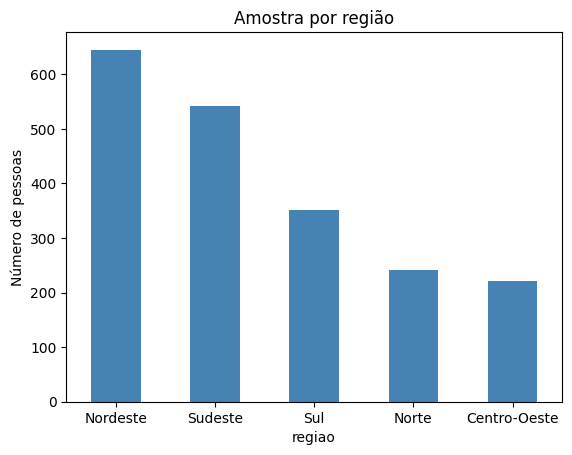

In [4]:
freq_absoluta.plot(kind="bar", color="steelblue")
plt.title("Amostra por região")
plt.ylabel("Número de pessoas")
plt.xticks(rotation=0)
plt.show()

### Gráfico de setores — sexo

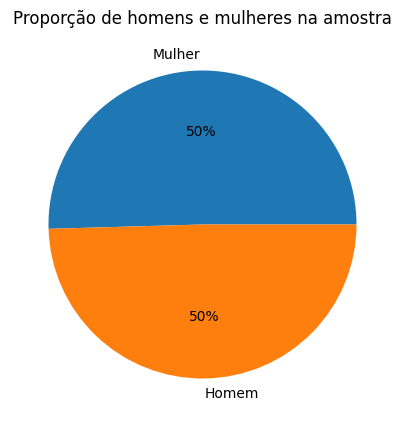

In [5]:
df["sexo"].value_counts().plot(kind="pie", autopct="%1.0f%%", ylabel="", figsize=(5, 5))
plt.title("Proporção de homens e mulheres na amostra")
plt.show()

### Dispersão unidimensional — idade

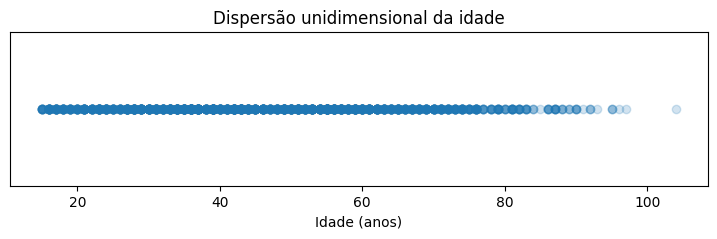

In [6]:
plt.figure(figsize=(9, 2))
plt.scatter(df["idade"], [1] * len(df), alpha=0.2)
plt.yticks([])
plt.xlabel("Idade (anos)")
plt.title("Dispersão unidimensional da idade")
plt.show()

### Histograma — IMC (Índice de Massa Corporal)

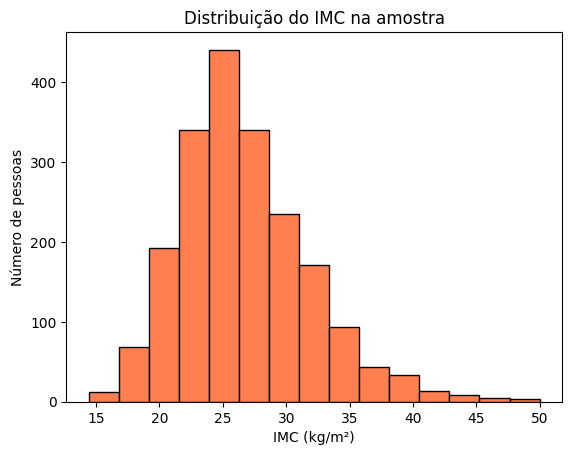

In [7]:
plt.hist(df["imc"], bins=15, color="coral", edgecolor="black")
plt.xlabel("IMC (kg/m²)")
plt.ylabel("Número de pessoas")
plt.title("Distribuição do IMC na amostra")
plt.show()

### Ramo-e-folhas — idade por década

Ramo = década de vida (10, 20, 30, ...); folha = último dígito da idade.

In [8]:
from collections import defaultdict

ramos = defaultdict(list)
for idade in sorted(df["idade"]):
    ramo, folha = divmod(idade, 10)
    ramos[ramo].append(str(folha))

print("Década | Idades")
print("-------+" + "-" * 40)
for ramo in sorted(ramos):
    print(f"{ramo*10:>6} | " + " ".join(ramos[ramo][:40]) + (" ..." if len(ramos[ramo]) > 40 else ""))

Década | Idades
-------+----------------------------------------
    10 | 5 5 5 5 5 5 5 5 5 5 5 5 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 7 7 ...
    20 | 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 ...
    30 | 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 ...
    40 | 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 ...
    50 | 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 ...
    60 | 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 ...
    70 | 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 ...
    80 | 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 4 4 4 5 6 6 ...
    90 | 0 0 0 0 0 1 2 2 2 3 5 5 5 6 7
   100 | 4


### Medidas de posição da idade

In [9]:
media = df["idade"].mean()
mediana = df["idade"].median()
moda = df["idade"].mode()[0]

print(f"Média:   {media:.1f} anos")
print(f"Mediana: {mediana:.1f} anos")
print(f"Moda:    {moda} anos")

Média:   46.8 anos
Mediana: 45.0 anos
Moda:    55 anos


## Aula 2 — Dispersão, quantis e box plot

### Desvio médio e variância do IMC (calculados na mão)

In [10]:
imc = df["imc"]
desvios = imc - imc.mean()
desvio_medio = desvios.abs().mean()
variancia = (desvios ** 2).mean()

print(f"Desvio médio do IMC: {desvio_medio:.3f}")
print(f"Variância do IMC:    {variancia:.3f}")

Desvio médio do IMC: 3.973
Variância do IMC:    26.293


### Quantis do peso

In [11]:
q1 = df["peso_kg"].quantile(0.25)
q2 = df["peso_kg"].quantile(0.50)
q3 = df["peso_kg"].quantile(0.75)

print(f"Q1: {q1:.1f} kg   Q2 (mediana): {q2:.1f} kg   Q3: {q3:.1f} kg   IQR: {q3-q1:.1f} kg")

Q1: 61.4 kg   Q2 (mediana): 70.2 kg   Q3: 80.9 kg   IQR: 19.5 kg


### Box plot do peso

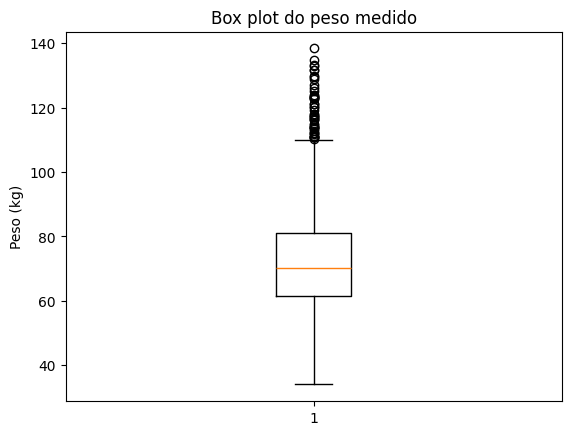

In [12]:
plt.boxplot(df["peso_kg"])
plt.ylabel("Peso (kg)")
plt.title("Box plot do peso medido")
plt.show()

### Simetria: IMC (mais simétrica) vs. renda per capita (bem assimétrica)

Renda é a variável clássica para mostrar assimetria: poucas pessoas com renda muito alta puxam a média bem para cima da mediana — o retrato mais comum de desigualdade em uma distribuição.

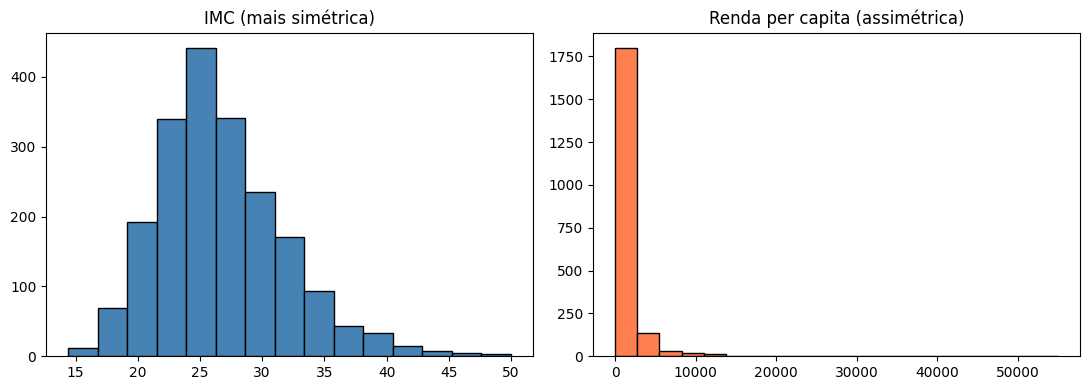

IMC   — média: 26.7   mediana: 25.9
Renda — média: R$ 1,443   mediana: R$ 998


In [13]:
fig, eixos = plt.subplots(1, 2, figsize=(11, 4))

eixos[0].hist(df["imc"], bins=15, color="steelblue", edgecolor="black")
eixos[0].set_title("IMC (mais simétrica)")

eixos[1].hist(df["renda_percapita"], bins=20, color="coral", edgecolor="black")
eixos[1].set_title("Renda per capita (assimétrica)")

plt.tight_layout()
plt.show()

print(f"IMC   — média: {df['imc'].mean():.1f}   mediana: {df['imc'].median():.1f}")
print(f"Renda — média: R$ {df['renda_percapita'].mean():,.0f}   mediana: R$ {df['renda_percapita'].median():,.0f}")

### Box plot do IMC, por região

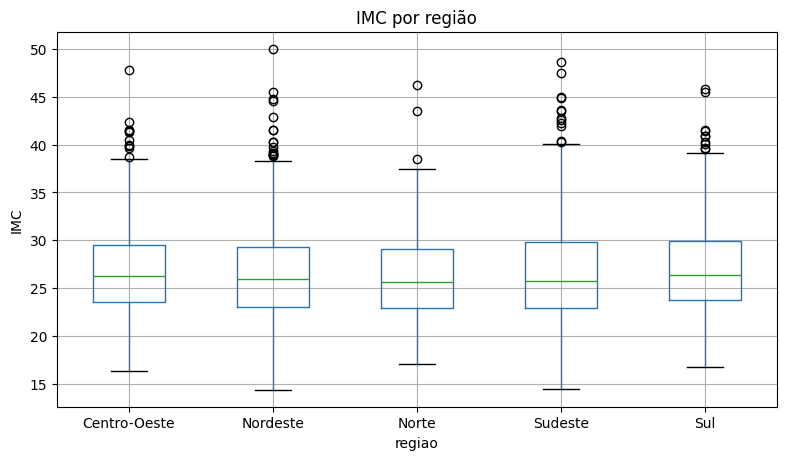

In [14]:
df.boxplot(column="imc", by="regiao", figsize=(9, 5))
plt.title("IMC por região")
plt.suptitle("")
plt.ylabel("IMC")
plt.show()

## Aula 3 — Espaço amostral e eventos

Experimento: sortear uma pessoa aleatoriamente entre as 2.000 da amostra. Evento de interesse: **A = "a pessoa tem diagnóstico de hipertensão"**.

In [15]:
tem_hipertensao = df["hipertensao"] == "Sim"
validos = df["hipertensao"].notna()
p_hipertensao = tem_hipertensao[validos].mean()

print(f"Espaço amostral (respostas válidas): {validos.sum()} pessoas")
print(f"Evento A (tem hipertensão): {tem_hipertensao[validos].sum()} pessoas")
print(f"P(A) = {p_hipertensao:.3f}")

Espaço amostral (respostas válidas): 1954 pessoas
Evento A (tem hipertensão): 535 pessoas
P(A) = 0.274


### Conferindo por simulação (sorteio com reposição, 200.000 vezes)

In [16]:
rng = np.random.default_rng(1)
sorteios = rng.choice(tem_hipertensao[validos].to_numpy(), size=200_000, replace=True)

print(f"Frequência relativa simulada: {sorteios.mean():.3f}")
print(f"Proporção real na amostra:    {p_hipertensao:.3f}")

Frequência relativa simulada: 0.274
Proporção real na amostra:    0.274


## Aula 4 — Técnicas de contagem

### Visitas de acompanhamento, importando a ordem (arranjo)

In [17]:
import math

n = len(df)
formas_arranjo = math.perm(n, 3)
print(f"De quantas formas dá para escolher 3 pessoas, em ordem (1ª, 2ª, 3ª visita), entre as {n}: {formas_arranjo:,}")

De quantas formas dá para escolher 3 pessoas, em ordem (1ª, 2ª, 3ª visita), entre as 2000: 7,988,004,000


### Grupo de 3 pessoas, sem importar a ordem (combinação)

In [18]:
formas_combinacao = math.comb(n, 3)
print(f"De quantas formas dá para escolher um grupo de 3 pessoas (sem ordem): {formas_combinacao:,}")
print(f"Confere: {formas_arranjo:,} / 3! = {formas_arranjo // math.factorial(3):,}")

De quantas formas dá para escolher um grupo de 3 pessoas (sem ordem): 1,331,334,000
Confere: 7,988,004,000 / 3! = 1,331,334,000


### O exemplo da comissão, com dados reais de saúde

De quantas formas dá para montar um grupo de estudo com 2 pessoas hipertensas e 2 pessoas diabéticas, escolhidas entre as pessoas reais da amostra com esses diagnósticos?

In [19]:
n_hipertensos = int(tem_hipertensao[validos].sum())
tem_diabetes = df["diabetes"] == "Sim"
validos_diabetes = df["diabetes"].notna()
n_diabeticos = int(tem_diabetes[validos_diabetes].sum())

formas_hip = math.comb(n_hipertensos, 2)
formas_diab = math.comb(n_diabeticos, 2)
formas_totais = formas_hip * formas_diab

print(f"Pessoas com hipertensão: {n_hipertensos}   Pessoas com diabetes: {n_diabeticos}")
print(f"Formas de escolher 2 hipertensos: {formas_hip:,}")
print(f"Formas de escolher 2 diabéticos: {formas_diab:,}")
print(f"Total (2 hipertensos E 2 diabéticos): {formas_hip:,} x {formas_diab:,} = {formas_totais:,}")

Pessoas com hipertensão: 535   Pessoas com diabetes: 159
Formas de escolher 2 hipertensos: 142,845
Formas de escolher 2 diabéticos: 12,561
Total (2 hipertensos E 2 diabéticos): 142,845 x 12,561 = 1,794,276,045


## Aula 5 — Probabilidade condicional

Pergunta real de saúde pública: ter diabetes muda a chance de também ter hipertensão? Vamos definir **A = "tem hipertensão"** e **B = "tem diabetes"**.

In [20]:
base = df[df["hipertensao"].notna() & df["diabetes"].notna()].copy()
base["hip_bin"] = base["hipertensao"] == "Sim"
base["diab_bin"] = base["diabetes"] == "Sim"

p_diabetes = base["diab_bin"].mean()
p_hip = base["hip_bin"].mean()
print(f"P(diabetes) = {p_diabetes:.3f}")
print(f"P(hipertensão) = {p_hip:.3f}")

P(diabetes) = 0.087
P(hipertensão) = 0.284


In [21]:
p_hip_dado_diab = base.loc[base["diab_bin"], "hip_bin"].mean()
p_hip_dado_naodiab = base.loc[base["diab_bin"] == False, "hip_bin"].mean()

print(f"P(hipertensão | diabetes)     = {p_hip_dado_diab:.3f}")
print(f"P(hipertensão | não diabetes) = {p_hip_dado_naodiab:.3f}")
print(f"P(hipertensão), sem condicionar em nada = {p_hip:.3f}")

P(hipertensão | diabetes)     = 0.667
P(hipertensão | não diabetes) = 0.247
P(hipertensão), sem condicionar em nada = 0.284


**Uma diferença enorme**: ter diabetes quase triplica a chance de também ter hipertensão nesta amostra (66,7% contra 24,7%). Isso é consistente com o que a literatura médica já documenta bastante bem — diabetes e hipertensão costumam andar juntas —, mas repare que os dados aqui são só de uma pesquisa domiciliar, não um estudo clínico controlado: eles mostram **associação**, não necessariamente uma relação de causa direta entre as duas doenças.

## Aula 6 — Probabilidade Total e Teorema de Bayes

### Reconstruindo P(hipertensão) a partir dos condicionais (Probabilidade Total)

In [22]:
p_hip_total = p_hip_dado_diab * p_diabetes + p_hip_dado_naodiab * (1 - p_diabetes)

print(f"P(hipertensão) via Probabilidade Total = {p_hip_dado_diab:.3f} × {p_diabetes:.3f} + {p_hip_dado_naodiab:.3f} × {1-p_diabetes:.3f} = {p_hip_total:.3f}")
print(f"P(hipertensão), contado direto nos dados = {p_hip:.3f}")

P(hipertensão) via Probabilidade Total = 0.667 × 0.087 + 0.247 × 0.913 = 0.284
P(hipertensão), contado direto nos dados = 0.284


### Teorema de Bayes: dado que a pessoa tem hipertensão, qual a chance de também ter diabetes?

In [23]:
p_diab_dado_hip = (p_hip_dado_diab * p_diabetes) / p_hip_total

print(f"P(diabetes | hipertensão) = ({p_hip_dado_diab:.3f} × {p_diabetes:.3f}) / {p_hip_total:.3f} = {p_diab_dado_hip:.3f}")
print(f"Confere, contando direto: {base.loc[base['hip_bin'], 'diab_bin'].mean():.3f}")

P(diabetes | hipertensão) = (0.667 × 0.087) / 0.284 = 0.205
Confere, contando direto: 0.205


Repare o quanto a informação "tem hipertensão" muda a probabilidade de diabetes: sem saber de mais nada, P(diabetes) = 8,7%; sabendo que a pessoa é hipertensa, essa chance mais que dobra, para cerca de 20%. É exatamente esse tipo de atualização de probabilidade — a partir de uma informação nova — que o Teorema de Bayes formaliza, e é a base de como funcionam, por exemplo, protocolos de triagem em saúde: encontrar uma condição aumenta a suspeita de outras condições relacionadas.

## Aula 7 — Variável aleatória discreta

Seja X = número de pessoas com diagnóstico de diabetes numa amostra de 3 pessoas sorteadas **com reposição** da nossa base. Vamos montar a distribuição de X pela árvore de possibilidades.

In [24]:
from itertools import product

p = p_diabetes

distribuicao_X = {}
for combinacao in product([1, 0], repeat=3):
    n_diabeticos_amostra = sum(combinacao)
    probabilidade = 1.0
    for c in combinacao:
        probabilidade *= p if c == 1 else (1 - p)
    distribuicao_X[n_diabeticos_amostra] = distribuicao_X.get(n_diabeticos_amostra, 0) + probabilidade

for x in sorted(distribuicao_X):
    print(f"P(X={x}) = {distribuicao_X[x]:.4f}")
print(f"Soma: {sum(distribuicao_X.values()):.4f}")

P(X=0) = 0.7606
P(X=1) = 0.2179
P(X=2) = 0.0208
P(X=3) = 0.0007
Soma: 1.0000


In [25]:
esperanca = sum(x * prob for x, prob in distribuicao_X.items())
variancia_X = sum((x - esperanca) ** 2 * prob for x, prob in distribuicao_X.items())

print(f"E[X] = {esperanca:.4f}   (confere com n×p = 3 × {p:.4f} = {3*p:.4f})")
print(f"Var[X] = {variancia_X:.4f}")

E[X] = 0.2615   (confere com n×p = 3 × 0.0872 = 0.2615)
Var[X] = 0.2387


### Conferindo por simulação, sorteando de verdade da base

In [26]:
diabeticos_array = base["diab_bin"].to_numpy()
amostras = rng.choice(diabeticos_array, size=(300_000, 3), replace=True)
X_simulado = amostras.sum(axis=1)

distribuicao_simulada = pd.Series(X_simulado).value_counts(normalize=True).sort_index()
pd.DataFrame({"Teórico": pd.Series(distribuicao_X).sort_index(), "Simulado": distribuicao_simulada})

,Teórico,Simulado
0,0.760621,0.760740
1,0.217908,0.217877
2,0.020809,0.020750
3,0.000662,0.000633


## Aula 8 — Variável aleatória contínua

Vamos tratar o IMC como variável contínua e calcular P(IMC ≥ 30) — o critério oficial da OMS para **obesidade** — como uma área sob a densidade empírica dos dados.

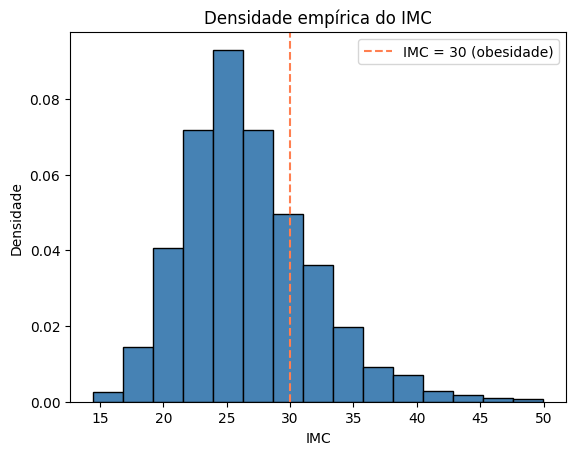

In [27]:
plt.hist(df["imc"], bins=15, density=True, color="steelblue", edgecolor="black")
plt.axvline(30, color="coral", linestyle="--", label="IMC = 30 (obesidade)")
plt.xlabel("IMC")
plt.ylabel("Densidade")
plt.title("Densidade empírica do IMC")
plt.legend()
plt.show()

In [28]:
p_obesidade = (df["imc"] >= 30).mean()
print(f"P(IMC ≥ 30), empírico = {p_obesidade:.3f}")

P(IMC ≥ 30), empírico = 0.231


### Comparando com o modelo uniforme "de mentirinha" da Aula 8

In [29]:
minimo, maximo = df["imc"].min(), df["imc"].max()
p_uniforme_hipotetico = (maximo - 30) / (maximo - minimo)

print(f"Se o IMC fosse uniforme entre {minimo:.1f} e {maximo:.1f}: P(IMC≥30) = {p_uniforme_hipotetico:.3f}")
print(f"Valor real (empírico): {p_obesidade:.3f}")

Se o IMC fosse uniforme entre 14.4 e 50.0: P(IMC≥30) = 0.562
Valor real (empírico): 0.231


De novo, uma diferença grande (modelo uniforme diria ~56%, o real é ~23%): o IMC da população real se concentra numa faixa razoavelmente estreita (a maioria das pessoas fica entre 20 e 30), bem diferente de estar espalhado igualmente entre o mínimo e o máximo observados. O mesmo aviso da Aula 8 vale de novo: sempre prefira estimar a probabilidade **direto dos dados** a assumir, sem checar, que a variável segue um modelo teórico simples.

In [30]:
esperanca_imc = df["imc"].mean()
variancia_imc = df["imc"].var(ddof=0)

print(f"E[IMC] = {esperanca_imc:.2f}")
print(f"Var[IMC] = {variancia_imc:.2f}")

E[IMC] = 26.71
Var[IMC] = 26.29


## Fechando: as 8 aulas, agora com dados de saúde

| Aula | O que usamos aqui |
|---|---|
| 1 | Classificar variáveis, tabela de frequência, 5 tipos de gráfico, moda/mediana/média |
| 2 | Desvio médio, variância, quantis, box plot, simetria (IMC) vs. assimetria (renda) |
| 3 | Espaço amostral, evento (hipertensão), probabilidade empírica vs. simulada |
| 4 | Arranjo e combinação (`math.perm`, `math.comb`) |
| 5 | Probabilidade condicional — diabetes quase triplica a chance de hipertensão |
| 6 | Probabilidade Total e Teorema de Bayes |
| 7 | Variável aleatória discreta: distribuição, E[X], Var[X] |
| 8 | Variável aleatória contínua: densidade empírica do IMC, P(IMC≥30) como área |

Comparando com o outro notebook de aplicações (filmes): o **conceito estatístico é idêntico**, mas o tipo de "bagunça" do dado real muda — lá era formatação e valores faltantes; aqui é dado codificado por um dicionário oficial e nomes de variável nada intuitivos. Aprender a lidar com os dois tipos de bagunça é parte do trabalho de quem analisa dados reais.

## 🎯 Sugestão de projeto: faça o mesmo com um banco de dados escolhido por você

Vale a mesma sugestão do outro notebook de aplicações: escolha **um banco de dados real** sobre algum assunto de seu interesse e refaça este roteiro com ele. Não é obrigatório nem vale nota.

### Onde encontrar um banco de dados real
- [Kaggle Datasets](https://www.kaggle.com/datasets) — bancos de dados prontos para baixar como CSV, sobre praticamente qualquer assunto
- [Dados Abertos do Governo Federal](https://dados.gov.br), [IBGE SIDRA](https://sidra.ibge.gov.br) e o [FTP de microdados do IBGE](https://ftp.ibge.gov.br) (foi daqui que veio a base deste notebook!) — dados públicos brasileiros
- Sites do seu interesse (jogos, esportes, streaming, etc.) costumam ter páginas de estatísticas ou dados exportáveis

### O roteiro (o mesmo que seguimos nos dois notebooks de aplicações)
1. **Carregar e limpar os dados** — inclusive decodificar variáveis, se o banco de dados vier com códigos em vez de texto (como aconteceu aqui)
2. **Classificar cada variável** — nominal, ordinal, discreta ou contínua
3. **Tabela de frequência e pelo menos 2 gráficos diferentes**
4. **Medidas de posição e dispersão**, e um **box plot**
5. **Defina um experimento aleatório e um evento**; calcule a probabilidade dele e confira com uma simulação
6. **Se fizer sentido, defina dois eventos**, calcule uma probabilidade condicional e aplique o Teorema de Bayes
7. **Construa uma variável aleatória** (discreta ou contínua) e calcule E[X] e Var[X]
8. **Apresente tudo com gráficos e um texto curto interpretando os resultados**

Um banco de dados de umas poucas centenas ou milhares de linhas já é suficiente — o que importa é passar pelo processo inteiro, da tabela bruta até uma conclusão que você consegue defender com números.